# Lab Day 2 — Backbone, công thức huấn luyện và suy luận trên DeepWeeds

**Nguyễn Thanh Hòa — MSSV 2A202602559 · Track 4 · Ngày 2 · VinUniversity AICB 2026**

Notebook này làm trọn bài lab: **7 backbone** (ResNet-50, ResNeXt-50, ConvNeXt-T, DeiT-S, Swin-T, EfficientNet-B0, MobileNetV3-L),
**7 trục công thức huấn luyện** (khởi tạo, augmentation/Mixup/CutMix, loss, sampler, LR, EMA/stochastic depth, độ phân giải),
**9 phương pháp suy luận** (TTA, multi-crop, gộp xác suất/logit, độ phân giải test, ensemble, EMA, temperature scaling, FP16/AMP, gộp BN)
kèm đo độ trễ p50/p95/p99, rồi chạy chung kết **3 seed** với cấu hình chốt trên val và so với mốc `T00 + I00`.

**Quy tắc được code ép thực thi:** dùng đúng fold 0 (không sửa CSV); chọn mọi thứ trên **val**; nhiệt độ T khớp trên val;
test chỉ quét **một lần cho mỗi checkpoint** (`inference.test_views_once` có file cờ chặn lần thứ hai); `eval.py` gốc không bị sửa.

**Cách chạy (Colab / Kaggle):**
1. Bật GPU (T4 trở lên). Nếu đã có `images.zip` (MD5 `b7b30f96…`) thì upload lên `/content` hoặc Drive rồi đặt `USER_IMAGES_ZIP` ở ô 1; nếu không notebook tự tải từ Zenodo (~490 MB).
2. *Runtime → Run all*. Mỗi run lưu `runs/<exp_id>/seed<k>/` (log, checkpoint, logit); chạy lại notebook sẽ **nạp lại run đã xong** (an toàn khi Colab ngắt kết nối). Đặt `USE_DRIVE = True` để lưu vào Google Drive.
3. Ước lượng tổng thời gian (chưa đo, tuỳ GPU): khoảng 3–4 giờ trên T4 cho cấu hình đầy đủ; đặt `LITE = True` để rút gọn (ghi rõ trong báo cáo).
4. Cuối notebook: bảng `results.xlsx`, ảnh `curves/`, `predictions/`, bản nháp `report.md` và file `.zip` tải về.

In [1]:
# ===== Môi trường, đường dẫn, cờ cấu hình =====
import os, sys, json, math, time, shutil, subprocess, platform, tempfile, warnings, glob, copy
from pathlib import Path
warnings.filterwarnings("ignore", category=FutureWarning)

QUICK     = os.environ.get("LAB_QUICK", "0") == "1"   # chạy thử code với dữ liệu rất nhỏ (KHÔNG dùng để nộp)
LITE      = False     # True: rút gọn (bỏ bớt thí nghiệm) nếu hết hạn mức GPU; phải ghi rõ trong báo cáo
USE_DRIVE = False     # True (Colab): clone repo vào Google Drive để runs/, checkpoint không mất khi ngắt kết nối
USER_IMAGES_ZIP = None    # đường dẫn tới images.zip nếu bạn đã upload; None = tự tìm hoặc tải từ Zenodo
MSSV, NAME_SLUG = "2A202602559", "nguyen_thanh_hoa"
SUB_NAME = f"{MSSV}_{NAME_SLUG}"
REPO_URL = "https://github.com/VinUni-AI20k/K4-Track4-Day2-Deeplearning-Advance.git"   # repo gốc của giảng viên (eval.py)
IN_COLAB = "google.colab" in sys.modules
IN_KAGGLE = os.path.exists("/kaggle/working")

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "timm", "openpyxl"], check=False)

def find_repo_root(start):
    p = Path(start).resolve()
    for _ in range(8):
        if (p / "eval.py").exists() and (p / "starter").exists():
            return p
        p = p.parent
    return None

REPO_ROOT = find_repo_root(os.getcwd())
if REPO_ROOT is None:
    base = Path("/kaggle/working") if IN_KAGGLE else Path("/content")
    if USE_DRIVE and IN_COLAB:
        from google.colab import drive
        drive.mount("/content/drive"); base = Path("/content/drive/MyDrive")
    REPO_ROOT = base / REPO_URL.rstrip("/").split("/")[-1].removesuffix(".git")
    if not REPO_ROOT.exists():
        subprocess.run(["git", "clone", REPO_URL, str(REPO_ROOT)], check=True)
assert (REPO_ROOT / "eval.py").exists(), "không tìm thấy eval.py của repo gốc"

SUB_DIR  = REPO_ROOT / "submissions" / SUB_NAME
CODE_DIR = SUB_DIR / "code"
CODE_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(CODE_DIR)); sys.path.insert(0, str(REPO_ROOT))      # import module của bài + eval.py gốc
os.chdir(CODE_DIR)                                                          # các ô %%writefile ghi vào đây
OUT = SUB_DIR / "_quick_out" if QUICK else SUB_DIR
for d in ("runs", "predictions", "curves", "figures", "results"):
    (OUT / d).mkdir(parents=True, exist_ok=True)
FIG = OUT / "figures"
DATA_DIR = Path(os.environ.get("LAB_DATA") or ("/content/data" if IN_COLAB else "/kaggle/working/data" if IN_KAGGLE else REPO_ROOT / "data"))
CACHE_DIR = os.environ.get("LAB_CACHE") or ("/content/cache" if IN_COLAB else "/kaggle/working/cache" if IN_KAGGLE
                                            else str(Path(tempfile.gettempdir()) / "deepweeds_cache"))

import numpy as np, pandas as pd, torch, timm
from IPython.display import Image as IPImage, display
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEV = "cuda" if device.type == "cuda" else "cpu"
print("python", platform.python_version(), "| torch", torch.__version__, "| timm", timm.__version__, "| device", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0), f"{torch.cuda.get_device_properties(0).total_memory / 2**30:.1f} GB")
elif not QUICK:
    print("CẢNH BÁO: không có GPU. Bật GPU (Runtime -> Change runtime type) trước khi chạy thật.")
print("REPO_ROOT =", REPO_ROOT, "\nOUT       =", OUT, "\nQUICK =", QUICK, "| LITE =", LITE)

Cloning into '/kaggle/working/K4-Track4-Day2-Deeplearning-Advance'...


python 3.13.15 | torch 2.11.0+cu128 | timm 1.0.29 | device cuda
GPU: Tesla T4 14.6 GB
REPO_ROOT = /kaggle/working/K4-Track4-Day2-Deeplearning-Advance 
OUT       = /kaggle/working/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602559_nguyen_thanh_hoa 
QUICK = False | LITE = False


### Các module của bài (ghi vào `submissions/2A202602559_nguyen_thanh_hoa/code/`)
Các ô `%%writefile` dưới đây là toàn bộ code tự viết: `dataset.py` (đọc dữ liệu, kiểm tra chia, augmentation, bộ nhớ đệm ảnh), `model.py` (backbone timm, đóng băng,
nhóm tham số, GMAC), `losses.py` (label smoothing, focal, trọng số lớp, Mixup/CutMix + kiểm tra tự viết), `train.py` (một hàm `run(Config)` cho mọi thí nghiệm),
`inference.py` (TTA, ensemble, temperature scaling, gộp BN, quét test đúng một lần), `benchmark.py` (đo độ trễ đúng cách), `report_tools.py` (xlsx, biểu đồ).
`eval.py` là file gốc của giảng viên, không sửa.

In [2]:
%%writefile dataset.py
"""dataset.py - đọc DeepWeeds, kiểm tra chia dữ liệu, transform, DataLoader.

Quy tắc chia dữ liệu bắt buộc (S1-S6) nằm ở README.md, mục 2.1: dùng fold 0 nguyên bản của tác giả,
không sửa / lọc / chia lại; val để chọn cấu hình, test chỉ chạy một lần mỗi seed ở Bước 4.

Thiết kế để chạy nhanh trên Colab (2 vCPU):
  * Giải mã JPEG MỘT lần, lưu thành mảng uint8 (N, 256, 256, 3) dạng memmap (`build_image_cache`);
    mọi DataLoader / EvalSet đọc từ mảng này nên không còn nghẽn giải mã ảnh.
  * Transform ở worker chỉ trả về tensor uint8; việc chuẩn hoá (mean/std) làm trên GPU bằng `Normalizer`.
  * Tập val/test (không augmentation) nạp thẳng lên thiết bị dưới dạng `EvalSet`; center-crop, lật, resize
    ... là các "view" áp dụng trên GPU (xem inference.py).

Giao diện chính:
    load_split(labels_dir, fold=0)                     -> (train_df, val_df, test_df)
    check_split(train_df, val_df, test_df, images_dir) -> dict
    build_transforms(train, img_size, aug)             -> torchvision transform (trả về tensor uint8)
    DeepWeedsDataset[i]                                -> (uint8 tensor CxHxW, label:int, filename:str)
    make_loader(df, images_dir, transform, batch_size, train, sampler, num_workers, store, seed)
    EvalSet(df, store, device)                         -> X uint8 (N,3,256,256) trên thiết bị, y, names
"""
from __future__ import annotations

import json
import os
import random
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from PIL import Image
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms as T

NUM_CLASSES = 9
N_TOTAL = 17_509
IMG_SIDE = 256
# Thứ tự lớp theo cột `Label` của labels.csv (0 = Chinee Apple ... 7 = Snake Weed, 8 = Negatives).
CLASS_NAMES = [
    "Chinee Apple", "Lantana", "Parkinsonia", "Parthenium", "Prickly Acacia",
    "Rubber Vine", "Siam Weed", "Snake Weed", "Negatives",
]
IMAGENET_MEAN = (0.485, 0.456, 0.406)  # model.py ghi đè bằng mean/std đúng của trọng số timm đang dùng
IMAGENET_STD = (0.229, 0.224, 0.225)
RRC_SCALE = (0.25, 1.0)                # RandomResizedCrop: ảnh cỏ dại chiếm gần cả khung, không cắt quá nhỏ


# --------------------------------------------------------------------------- chia dữ liệu
def load_split(labels_dir: str | Path, fold: int = 0):
    """Đọc train_subset{fold}.csv, val_subset{fold}.csv, test_subset{fold}.csv (S1).

    Các file của tác giả có cột `Filename, Label` (tên loài nằm ở labels.csv). KHÔNG sửa/lọc/chia lại.
    """
    d = Path(labels_dir)
    out = []
    for split in ("train", "val", "test"):
        df = pd.read_csv(d / f"{split}_subset{fold}.csv")
        if not {"Filename", "Label"} <= set(df.columns):
            raise ValueError(f"{split}_subset{fold}.csv: cần cột Filename và Label, có {list(df.columns)}")
        out.append(df)
    return tuple(out)


def check_split(train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame,
                images_dir: str | Path, verbose: bool = True, expected_total: int = N_TOTAL) -> dict:
    """Kiểm tra bắt buộc trước khi train (README.md, mục 2.1). In ra và trả về dict số liệu.

    1. số ảnh mỗi tập, mỗi lớp (xấp xỉ 60/20/20, lệch quá 1 điểm phần trăm thì dừng);
    2. giao của từng cặp tập theo Filename phải RỖNG;
    3. hợp ba tập đúng 17.509 ảnh, không trùng tên trong một tập;
    4. mọi Filename đều tồn tại trong images_dir.
    """
    sets = {"train": train_df, "val": val_df, "test": test_df}
    n = {k: int(len(v)) for k, v in sets.items()}
    total = sum(n.values())
    frac = {k: n[k] / total for k in n}
    for k, target in (("train", 0.6), ("val", 0.2), ("test", 0.2)):
        assert abs(frac[k] - target) <= 0.01, (
            f"tỉ lệ {k} = {frac[k]:.3%} lệch hơn 1 điểm phần trăm khỏi {target:.0%}: báo giảng viên trước khi chạy tiếp")
    for k, v in sets.items():
        assert v["Filename"].is_unique, f"{k}: có Filename bị trùng"
    names = {k: set(v["Filename"]) for k, v in sets.items()}
    overlap = {f"{a}&{b}": len(names[a] & names[b]) for a, b in (("train", "val"), ("train", "test"), ("val", "test"))}
    assert all(v == 0 for v in overlap.values()), f"giao các tập khác rỗng: {overlap}"
    union = names["train"] | names["val"] | names["test"]
    assert total == expected_total and len(union) == expected_total, (
        f"hợp ba tập = {len(union)} (tổng dòng {total}), kỳ vọng {expected_total}")
    images_dir = Path(images_dir)
    missing = [f for f in sorted(union) if not (images_dir / f).exists()]
    assert not missing, f"{len(missing)} file trong CSV không có trong {images_dir}, ví dụ {missing[:3]}"
    per_class = pd.DataFrame({k: v["Label"].value_counts().reindex(range(NUM_CLASSES), fill_value=0)
                              for k, v in sets.items()})
    per_class.index = CLASS_NAMES
    per_class["total"] = per_class.sum(1)
    info = {"n": n, "fraction": frac, "per_class": per_class.to_dict(), "overlap": overlap,
            "union": len(union), "missing_files": 0}
    if verbose:
        print("số ảnh:", n, "| tổng", total, "| tỉ lệ", {k: f"{v:.2%}" for k, v in frac.items()})
        print("giao các cặp tập:", overlap, "| hợp ba tập =", len(union), "| thiếu file = 0")
        print(per_class.to_string())
        mx, mn = per_class["total"].max(), per_class["total"].min()
        print(f"lớp lớn nhất / nhỏ nhất = {mx} / {mn} = {mx / mn:.2f}×")
    return info


# --------------------------------------------------------------------------- bộ nhớ đệm ảnh
def build_image_cache(images_dir: str | Path, filenames, cache_dir: str | Path, side: int = IMG_SIDE,
                      workers: int | None = None, force: bool = False) -> Path:
    """Giải mã mọi ảnh một lần, ghi mảng uint8 (N, side, side, 3) + danh sách tên vào cache_dir."""
    images_dir, cache_dir = Path(images_dir), Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    npy, names_json = cache_dir / "images_u8.npy", cache_dir / "names.json"
    filenames = list(filenames)
    if not force and npy.exists() and names_json.exists():
        if json.loads(names_json.read_text()) == filenames:
            return npy
    arr = np.lib.format.open_memmap(npy, mode="w+", dtype=np.uint8, shape=(len(filenames), side, side, 3))

    def _load(i: int) -> None:
        with Image.open(images_dir / filenames[i]) as im:
            im = im.convert("RGB")
            if im.size != (side, side):
                im = im.resize((side, side), Image.BILINEAR)
            arr[i] = np.asarray(im)

    with ThreadPoolExecutor(max_workers=workers or max(2, (os.cpu_count() or 2))) as ex:
        list(ex.map(_load, range(len(filenames))))
    arr.flush()
    names_json.write_text(json.dumps(filenames))
    return npy


class ImageStore:
    """Mảng ảnh uint8 dạng memmap + chỉ mục tên file -> dòng."""

    def __init__(self, cache_dir: str | Path):
        cache_dir = Path(cache_dir)
        self.arr = np.load(cache_dir / "images_u8.npy", mmap_mode="r")
        self.names = json.loads((cache_dir / "names.json").read_text())
        self.index = {n: i for i, n in enumerate(self.names)}

    def rows(self, filenames) -> np.ndarray:
        return np.array([self.index[f] for f in filenames], dtype=np.int64)


_STORES: dict = {}


def get_store(images_dir, cache_dir, filenames) -> ImageStore:
    """Tạo (nếu chưa có) và trả về ImageStore, nhớ trong tiến trình để các run dùng chung."""
    key = str(Path(cache_dir).resolve())
    if key not in _STORES:
        build_image_cache(images_dir, sorted(set(filenames)), cache_dir)
        _STORES[key] = ImageStore(cache_dir)
    return _STORES[key]


# --------------------------------------------------------------------------- transform
def build_transforms(train: bool, img_size: int = 224, aug: str = "basic"):
    """Transform trả về tensor uint8 (C, H, W); chuẩn hoá làm trên GPU bằng `Normalizer`.

    Train (mọi mức): RandomResizedCrop(img_size, scale=(0.25, 1)) + lật ngang. `aug` thêm:
        "basic"  : không thêm gì (công thức nền)
        "vflip"  : + lật dọc
        "color"  : + ColorJitter(0.3, 0.3, 0.3, 0.05)
        "trivial": + TrivialAugmentWide
        "randaug": + RandAugment(2, 9)
    Mixup/CutMix trộn theo batch nên nằm ở losses.py.
    Val/test: chỉ PILToTensor (ảnh gốc 256x256); center-crop / resize là "view" trên GPU (inference.py),
    KHÔNG có augmentation ngẫu nhiên khi đánh giá.
    """
    if not train:
        return T.PILToTensor()
    ops = [T.RandomResizedCrop(img_size, scale=RRC_SCALE, interpolation=T.InterpolationMode.BILINEAR),
           T.RandomHorizontalFlip()]
    if aug == "vflip":
        ops.append(T.RandomVerticalFlip())
    elif aug == "color":
        ops.append(T.ColorJitter(0.3, 0.3, 0.3, 0.05))
    elif aug == "trivial":
        ops.append(T.TrivialAugmentWide())
    elif aug == "randaug":
        ops.append(T.RandAugment(2, 9))
    elif aug != "basic":
        raise ValueError(f"aug không hợp lệ: {aug!r}")
    ops.append(T.PILToTensor())
    return T.Compose(ops)


class Normalizer:
    """(x_uint8 - mean*255) / (std*255) trên thiết bị của x. Gọi như hàm; trả float32."""

    def __init__(self, mean=IMAGENET_MEAN, std=IMAGENET_STD):
        self.mean, self.std = tuple(mean), tuple(std)
        self._cache: dict = {}

    def _stats(self, device):
        key = str(device)
        if key not in self._cache:
            m = torch.tensor(self.mean, dtype=torch.float32, device=device).view(1, 3, 1, 1) * 255.0
            s = torch.tensor(self.std, dtype=torch.float32, device=device).view(1, 3, 1, 1) * 255.0
            self._cache[key] = (m, s)
        return self._cache[key]

    def __call__(self, x_u8: torch.Tensor) -> torch.Tensor:
        m, s = self._stats(x_u8.device)
        return (x_u8.float() - m) / s

    def denormalize(self, x: torch.Tensor) -> torch.Tensor:
        """Đảo chuẩn hoá để vẽ ảnh (trả về float trong [0, 1])."""
        m, s = self._stats(x.device)
        return ((x * s + m) / 255.0).clamp(0, 1)


# --------------------------------------------------------------------------- Dataset / DataLoader
class DeepWeedsDataset(Dataset):
    """Dataset đọc ảnh theo DataFrame (Filename, Label); trả về (tensor, nhãn int, tên file str).

    Nếu có `store` (ImageStore) thì lấy ảnh từ mảng uint8 trong RAM/memmap; nếu không thì mở file JPEG.
    """

    def __init__(self, df: pd.DataFrame, images_dir: str | Path | None = None, transform=None, store=None):
        self.names = df["Filename"].tolist()
        self.labels = df["Label"].astype(int).tolist()
        self.transform = transform
        self.store = store
        self.images_dir = Path(images_dir) if images_dir is not None else None
        self.rows = store.rows(self.names) if store is not None else None
        if store is None and self.images_dir is None:
            raise ValueError("cần images_dir hoặc store")

    def __len__(self) -> int:
        return len(self.names)

    def __getitem__(self, i: int):
        if self.store is not None:
            img = Image.fromarray(np.asarray(self.store.arr[self.rows[i]]))
        else:
            with Image.open(self.images_dir / self.names[i]) as im:
                img = im.convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img, self.labels[i], self.names[i]


def _seed_worker(worker_id: int) -> None:
    seed = (torch.initial_seed() + worker_id) % (2 ** 32)
    np.random.seed(seed)
    random.seed(seed)


def make_loader(df: pd.DataFrame, images_dir, transform, batch_size: int, train: bool,
                sampler: str | None = None, num_workers: int = 2, store=None, seed: int = 0) -> DataLoader:
    """DataLoader. train: xáo (hoặc sampler cân bằng), drop_last; eval: giữ nguyên thứ tự của df.

    sampler="balanced": WeightedRandomSampler với trọng số 1/(số ảnh của lớp) tính TRÊN df truyền vào
    (chỉ gọi với train_df).
    """
    dataset = DeepWeedsDataset(df, images_dir, transform, store)
    g = torch.Generator()
    g.manual_seed(seed)
    kw = dict(batch_size=batch_size, num_workers=num_workers, pin_memory=torch.cuda.is_available(),
              drop_last=bool(train), generator=g)
    if num_workers > 0:
        kw.update(worker_init_fn=_seed_worker, persistent_workers=bool(train), prefetch_factor=4)
    if train and sampler == "balanced":
        counts = df["Label"].value_counts()
        w = df["Label"].map(lambda c: 1.0 / counts[c]).to_numpy()
        smp = WeightedRandomSampler(torch.as_tensor(w, dtype=torch.double), num_samples=len(dataset),
                                    replacement=True, generator=g)
        return DataLoader(dataset, sampler=smp, **kw)
    if sampler not in (None, "balanced"):
        raise ValueError(f"sampler không hợp lệ: {sampler!r}")
    return DataLoader(dataset, shuffle=bool(train), **kw)


# --------------------------------------------------------------------------- tập đánh giá trên GPU
class EvalSet:
    """Toàn bộ một tập (val hoặc test) dưới dạng tensor uint8 (N, 3, 256, 256) trên `device`.

    Giữ đúng thứ tự của df để ghép logit với tên file. ~700 MB cho 3.5k ảnh.
    """

    def __init__(self, df: pd.DataFrame, store: ImageStore, device, limit: int | None = None):
        if limit is not None:
            df = df.iloc[:limit]
        self.names = df["Filename"].tolist()
        self.y = df["Label"].to_numpy(dtype=np.int64)
        rows = store.rows(self.names)
        order = np.argsort(rows)                     # đọc memmap theo thứ tự tăng dần cho nhanh
        arr = np.empty((len(rows), IMG_SIDE, IMG_SIDE, 3), dtype=np.uint8)
        arr[order] = store.arr[rows[order]]
        self.X = torch.from_numpy(arr).permute(0, 3, 1, 2).contiguous().to(device)
        self.device = device

    def __len__(self) -> int:
        return len(self.names)


_EVALSETS: dict = {}


def get_evalset(name: str, df: pd.DataFrame, store: ImageStore, device, limit: int | None = None) -> EvalSet:
    """Nạp (và nhớ) một EvalSet; khoá gồm tên tập, số ảnh và thiết bị."""
    key = (name, limit, str(device), len(df))
    if key not in _EVALSETS:
        _EVALSETS[key] = EvalSet(df, store, device, limit)
    return _EVALSETS[key]

Writing dataset.py


In [3]:
%%writefile model.py
"""model.py - tạo backbone (timm), đóng băng, nhóm tham số, đếm params/GMAC.

Giao diện:
    build_model(name, pretrained, num_classes, drop_rate, init, drop_path_rate) -> nn.Module
    freeze_backbone(model) / set_train_mode(model)
    param_groups(model, lr_backbone, lr_head, weight_decay)                    -> list[dict] cho optimizer
    count_params(model) -> float (triệu)        count_gmacs(model, img_size) -> float
Model có thêm thuộc tính: `weight_tag` (tag trọng số thực sự được tải), `norm_mean`, `norm_std`, `frozen`.
"""
from __future__ import annotations

import copy

import torch
import torch.nn as nn

# Gợi ý backbone (GUIDE.md mục 2.1). Tag trọng số của timm có thể đổi theo phiên bản: ghi lại tag thực tế.
SUGGESTED_BACKBONES = {
    "resnet50": "resnet50",
    "resnext50": "resnext50_32x4d",
    "convnext_tiny": "convnext_tiny",
    "deit_small": "deit_small_patch16_224",
    "swin_tiny": "swin_tiny_patch4_window7_224",
    "efficientnet_b0": "efficientnet_b0",        # mạng nhẹ
    "mobilenetv3": "mobilenetv3_large_100",      # mạng nhẹ
}
# Mạng chấp nhận ảnh có kích thước khác lúc train (có global pooling, không có embedding vị trí cố định).
VARIABLE_RES_KEYS = ("resnet", "resnext", "convnext", "efficientnet", "mobilenet", "regnet")
LIGHT_KEYS = ("efficientnet", "mobilenet")


def supports_variable_res(name: str) -> bool:
    return any(k in name for k in VARIABLE_RES_KEYS)


def is_light(name: str) -> bool:
    return any(k in name for k in LIGHT_KEYS)


def _weight_tag(model, name: str, pretrained: bool) -> str:
    if not pretrained:
        return f"{name} (khởi tạo ngẫu nhiên, không tiền huấn luyện)"
    cfg = dict(getattr(model, "pretrained_cfg", None) or {})
    tag = cfg.get("hf_hub_id") or cfg.get("url") or cfg.get("file") or cfg.get("tag") or "không rõ tag"
    return f"{name} ({tag})"


def build_model(name: str, pretrained: bool = True, num_classes: int = 9, drop_rate: float = 0.0,
                init: str = "finetune", drop_path_rate: float = 0.0):
    """Tạo model phân loại 9 lớp bằng timm (head mới khởi tạo ngẫu nhiên).

    `init` (trục A của GUIDE.md mục 3):
      - "scratch"  : không tiền huấn luyện, huấn luyện toàn bộ
      - "frozen"   : tiền huấn luyện ImageNet, đóng băng backbone, chỉ train head
      - "finetune" : tiền huấn luyện ImageNet, train toàn bộ (công thức nền)
    `pretrained=False` buộc không tải trọng số (dùng khi nạp checkpoint đã huấn luyện, hoặc chạy thử).
    """
    import timm
    if init not in ("scratch", "frozen", "finetune"):
        raise ValueError(f"init không hợp lệ: {init!r}")
    use_pre = bool(pretrained) and init != "scratch"
    kw = dict(pretrained=use_pre, num_classes=num_classes, drop_rate=drop_rate)
    if drop_path_rate and drop_path_rate > 0:
        kw["drop_path_rate"] = drop_path_rate
    model = timm.create_model(name, **kw)
    cfg = dict(getattr(model, "pretrained_cfg", None) or {})
    model.norm_mean = tuple(cfg.get("mean", (0.485, 0.456, 0.406)))
    model.norm_std = tuple(cfg.get("std", (0.229, 0.224, 0.225)))
    model.weight_tag = _weight_tag(model, name, use_pre)
    model.backbone_name = name
    model.frozen = False
    if init == "frozen":
        freeze_backbone(model)
    return model


def head_params(model) -> list:
    return list(model.get_classifier().parameters())


def freeze_backbone(model) -> None:
    """Đóng băng mọi tham số trừ head (model.get_classifier()).

    Backbone đóng băng thì BatchNorm cũng phải ở eval (thống kê chạy không được cập nhật): xem
    `set_train_mode`, gọi ở đầu MỖI epoch thay cho model.train().
    """
    head_ids = {id(p) for p in head_params(model)}
    for p in model.parameters():
        p.requires_grad = id(p) in head_ids
    model.frozen = True


def set_train_mode(model) -> None:
    """model.train(), nhưng nếu backbone bị đóng băng thì giữ backbone ở eval và chỉ để head ở train."""
    if getattr(model, "frozen", False):
        model.eval()
        model.get_classifier().train()
    else:
        model.train()


def param_groups(model, lr_backbone: float, lr_head: float, weight_decay: float):
    """Chia tham số thành các nhóm như slide Day 2, trang 52 (bỏ tham số requires_grad == False):

    - backbone ndim > 1          : lr_backbone, weight_decay
    - norm và bias (ndim <= 1)   : lr_backbone, weight_decay = 0   (cả backbone lẫn head)
    - head ndim > 1              : lr_head,     weight_decay
    - bias của head              : lr_head,     weight_decay = 0
    """
    head_ids = {id(p) for p in head_params(model)}
    buckets = {"backbone_decay": [], "backbone_no_decay": [], "head_decay": [], "head_no_decay": []}
    for p in model.parameters():
        if not p.requires_grad:
            continue
        side = "head" if id(p) in head_ids else "backbone"
        buckets[f"{side}_{'decay' if p.ndim > 1 else 'no_decay'}"].append(p)
    spec = [("backbone_decay", lr_backbone, weight_decay), ("backbone_no_decay", lr_backbone, 0.0),
            ("head_decay", lr_head, weight_decay), ("head_no_decay", lr_head, 0.0)]
    return [{"params": buckets[k], "lr": lr, "weight_decay": wd, "name": k} for k, lr, wd in spec if buckets[k]]


def count_params(model) -> float:
    """Số tham số (triệu), đếm cả tham số bị đóng băng."""
    return sum(p.numel() for p in model.parameters()) / 1e6


def count_gmacs(model, img_size: int = 224) -> float:
    """GMAC cho một ảnh 3 x img_size x img_size (MAC, không phải FLOPs = 2 x MAC).

    Công cụ: torch.utils.flop_counter.FlopCounterMode (có sẵn trong PyTorch >= 2.1) trên bản sao CPU của
    model; tắt fused attention để các phép matmul của attention được đếm. Chỉ đếm conv/matmul/linear
    (bỏ qua các phép phần tử và softmax), nên có thể lệch vài phần trăm so với fvcore/ptflops.
    """
    try:
        from torch.utils.flop_counter import FlopCounterMode
        m = copy.deepcopy(model).cpu().eval().float()
        for mod in m.modules():
            if hasattr(mod, "fused_attn"):
                mod.fused_attn = False
        x = torch.randn(1, 3, img_size, img_size)
        with torch.no_grad(), FlopCounterMode(display=False) as fc:
            m(x)
        return float(fc.get_total_flops()) / 2.0 / 1e9
    except Exception as e:  # noqa: BLE001 - không để việc đếm GMAC làm hỏng cả lần chạy
        print(f"[count_gmacs] không đếm được GMAC: {type(e).__name__}: {e}")
        return float("nan")

Writing model.py


In [4]:
%%writefile losses.py
"""losses.py - các hàm loss và trộn mẫu (Mixup, CutMix).

Liên hệ slide Day 2: label smoothing (trang 56), focal loss (trang 57), Mixup/CutMix (trang 48).

Giao diện:
    build_criterion(kind, **kw)            -> callable(logits, target) -> loss scalar
    class_weights(counts, beta)            -> tensor trọng số lớp
    mix_batch(x, y, alpha, mode)           -> (x_mixed, (y_a, y_b, lam))
    mixed_loss(criterion, logits, targets) -> loss scalar
Các kiểm tra tự viết (focal gamma=0 == CE, LS eps=0 == CE, CutMix lam == diện tích thật) nằm ở `self_test()`
và được notebook gọi trước khi chạy thí nghiệm.
"""
from __future__ import annotations

import math

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F


class LabelSmoothingCE(nn.Module):
    """Cross-entropy với label smoothing: q'(k) = (1 - eps) * 1[k == y] + eps / K  (slide trang 56).

    Cài đặt tay: loss = (1 - eps) * NLL + eps * mean_k(-log p_k). eps = 0 cho đúng cross-entropy.
    """

    def __init__(self, smoothing: float = 0.1):
        super().__init__()
        assert 0.0 <= smoothing < 1.0
        self.smoothing = float(smoothing)

    def forward(self, logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        logp = F.log_softmax(logits.float(), dim=-1)
        nll = -logp.gather(1, target.unsqueeze(1)).squeeze(1)
        smooth = -logp.mean(dim=-1)
        return ((1.0 - self.smoothing) * nll + self.smoothing * smooth).mean()


class FocalLoss(nn.Module):
    """Focal loss nhiều lớp: FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)  (slide trang 57).

    alpha: None hoặc vector trọng số theo lớp (độ dài K). gamma = 0 và alpha = None cho đúng cross-entropy.
    Trung bình theo batch (không chia thêm cho tổng alpha).
    """

    def __init__(self, gamma: float = 2.0, alpha=None):
        super().__init__()
        self.gamma = float(gamma)
        self.register_buffer("alpha", None if alpha is None else torch.as_tensor(alpha, dtype=torch.float32))

    def forward(self, logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        logp = F.log_softmax(logits.float(), dim=-1)
        logp_t = logp.gather(1, target.unsqueeze(1)).squeeze(1)
        p_t = logp_t.exp()
        loss = -((1.0 - p_t).clamp(min=0.0) ** self.gamma) * logp_t
        if self.alpha is not None:
            loss = loss * self.alpha.to(loss.device)[target]
        return loss.mean()


def class_weights(counts, beta: float = 0.0) -> torch.Tensor:
    """Trọng số theo lớp từ số ảnh mỗi lớp trong tập TRAIN (không dùng val/test).

    - beta = 0: w_c = 1 / n_c, chuẩn hoá về trung bình 1
    - beta > 0: class-balanced theo số mẫu hiệu dụng (Cui et al., arXiv:1901.05555):
                w_c = (1 - beta) / (1 - beta ** n_c), chuẩn hoá tổng trọng số về số lớp
    """
    n = np.asarray(counts, dtype=np.float64)
    assert (n > 0).all(), "mọi lớp phải có ít nhất một ảnh trong train"
    if beta == 0.0:
        w = 1.0 / n
        w = w / w.mean()
    else:
        w = (1.0 - beta) / (1.0 - np.power(beta, n))
        w = w * len(n) / w.sum()
    return torch.as_tensor(w, dtype=torch.float32)


def build_criterion(kind: str = "ce", **kw):
    """Trả về hàm loss theo `kind`: "ce", "ls" (label smoothing), "focal", "ce_weighted".

    kw: smoothing=0.1, gamma=2.0, alpha=None (cho focal), weight=tensor (cho ce_weighted).
    """
    if kind == "ce":
        return nn.CrossEntropyLoss()
    if kind == "ls":
        return LabelSmoothingCE(kw.get("smoothing", 0.1))
    if kind == "focal":
        return FocalLoss(kw.get("gamma", 2.0), kw.get("alpha"))
    if kind == "ce_weighted":
        if kw.get("weight") is None:
            raise ValueError("ce_weighted cần weight=class_weights(...)")
        return nn.CrossEntropyLoss(weight=torch.as_tensor(kw["weight"], dtype=torch.float32))
    raise ValueError(f"loss không hợp lệ: {kind!r}")


def _rand_box(h: int, w: int, lam: float):
    cut = math.sqrt(1.0 - lam)
    ch, cw = int(h * cut), int(w * cut)
    cy, cx = np.random.randint(h), np.random.randint(w)
    y1, y2 = int(np.clip(cy - ch // 2, 0, h)), int(np.clip(cy + ch // 2, 0, h))
    x1, x2 = int(np.clip(cx - cw // 2, 0, w)), int(np.clip(cx + cw // 2, 0, w))
    return y1, y2, x1, x2


def mix_batch(x: torch.Tensor, y: torch.Tensor, alpha: float = 1.0, mode: str = "cutmix"):
    """Trộn một batch ảnh (N, C, H, W) và nhãn. lam ~ Beta(alpha, alpha).

    - mixup : x_mix = lam * x + (1 - lam) * x[perm]
    - cutmix: dán một hộp chữ nhật của x[perm] vào x; lam được TÍNH LẠI theo diện tích thật của hộp
              sau khi cắt ra ngoài biên (slide trang 48)
    Trả về (x_mix, (y_a, y_b, lam)) với y_a = y, y_b = y[perm]. Dùng RNG của numpy/torch đã được set_seed.
    """
    if alpha <= 0:
        raise ValueError("alpha phải > 0")
    lam = float(np.random.beta(alpha, alpha))
    perm = torch.randperm(x.size(0), device=x.device)
    if mode == "mixup":
        x_mix = lam * x + (1.0 - lam) * x[perm]
    elif mode == "cutmix":
        h, w = x.shape[-2:]
        y1, y2, x1, x2 = _rand_box(h, w, lam)
        x_mix = x.clone()
        x_mix[:, :, y1:y2, x1:x2] = x[perm][:, :, y1:y2, x1:x2]
        lam = 1.0 - ((y2 - y1) * (x2 - x1)) / float(h * w)
    else:
        raise ValueError(f"mode không hợp lệ: {mode!r}")
    return x_mix, (y, y[perm], lam)


def mixed_loss(criterion, logits: torch.Tensor, targets) -> torch.Tensor:
    """lam * criterion(logits, y_a) + (1 - lam) * criterion(logits, y_b) cho batch đã trộn."""
    y_a, y_b, lam = targets
    return lam * criterion(logits, y_a) + (1.0 - lam) * criterion(logits, y_b)


def self_test(verbose: bool = True) -> dict:
    """Các kiểm tra tự viết cho những phần dễ sai (RUBRIC mục H). Ném AssertionError nếu sai."""
    torch.manual_seed(0)
    np.random.seed(0)
    logits = torch.randn(64, 9) * 3
    y = torch.randint(0, 9, (64,))
    ce = F.cross_entropy(logits, y)
    res = {}
    res["focal(gamma=0) - CE"] = abs(FocalLoss(0.0)(logits, y) - ce).item()
    res["LS(eps=0) - CE"] = abs(LabelSmoothingCE(0.0)(logits, y) - ce).item()
    res["LS(eps=0.1) - torch"] = abs(LabelSmoothingCE(0.1)(logits, y)
                                     - F.cross_entropy(logits, y, label_smoothing=0.1)).item()
    cw = class_weights([100, 100, 100, 100, 100, 100, 100, 100, 100])
    res["ce_weighted(đều) - CE"] = abs(build_criterion("ce_weighted", weight=cw)(logits, y) - ce).item()
    res["focal(gamma=2) <= CE"] = float(FocalLoss(2.0)(logits, y) <= ce)
    x = torch.randn(8, 3, 32, 32)
    yy = torch.arange(8)
    _, (_, _, lam) = mix_batch(x, yy, 1.0, "cutmix")
    # diện tích thật: dán x[perm] -> số điểm ảnh khác x phải <= (1 - lam) * H * W
    np.random.seed(1)
    torch.manual_seed(1)
    xm, (ya, yb, lam) = mix_batch(x, yy, 1.0, "cutmix")
    changed = (xm != x).any(1).float().mean((1, 2))            # tỉ lệ điểm ảnh đổi, mỗi ảnh
    res["cutmix: max(đổi) <= 1 - lam"] = float(changed.max().item() <= (1 - lam) + 1e-6)
    xm, (ya, yb, lam) = mix_batch(x, yy, 1.0, "mixup")
    res["mixup: 0 <= lam <= 1"] = float(0.0 <= lam <= 1.0)
    crit = build_criterion("ce")
    res["mixed_loss(lam=1) - CE"] = abs(mixed_loss(crit, logits, (y, y.roll(1), 1.0)) - ce).item()
    ok = (res["focal(gamma=0) - CE"] < 1e-6 and res["LS(eps=0) - CE"] < 1e-6 and res["LS(eps=0.1) - torch"] < 1e-6
          and res["ce_weighted(đều) - CE"] < 1e-6 and res["focal(gamma=2) <= CE"] == 1.0
          and res["cutmix: max(đổi) <= 1 - lam"] == 1.0 and res["mixup: 0 <= lam <= 1"] == 1.0
          and res["mixed_loss(lam=1) - CE"] < 1e-6)
    assert ok, res
    if verbose:
        for k, v in res.items():
            print(f"  {k:<32} {v:.2e}" if v not in (0.0, 1.0) or "<=" not in k else f"  {k:<32} OK")
        print("self_test losses: OK")
    return res

Writing losses.py


In [5]:
%%writefile inference.py
"""inference.py - các phương pháp suy luận (Bước 3 của GUIDE.md) và dự đoán test đúng một lần (Bước 4).

Liên hệ slide Day 2: TTA (trang 62-66, 75), ensemble/EMA/soup (trang 67), độ phân giải kiểm tra (trang 68),
temperature scaling (trang 69), gộp BatchNorm (trang 71).

Mọi hàm chạy ở chế độ eval, không gradient. Chọn phương pháp CHỈ dựa trên val; nhiệt độ T khớp trên VAL rồi
áp dụng sang test (README.md, S2 và S4).

Quy ước "view": hàm biến đổi một batch ảnh ĐÃ CHUẨN HOÁ (N, 3, 256, 256) thành (N, 3, h, w). Center-crop,
lật, 5-crop, resize đều giao hoán với phép chuẩn hoá theo kênh nên làm sau chuẩn hoá vẫn chính xác.

Giao diện chính:
    predict_logits(model, X_u8, device, normalizer, view, ...) -> logits[N, 9] (numpy)
    make_views(kind, base)         -> list[(tên, view)]
    aggregate_views(list_logits, space) -> probs[N, 9]
    fit_temperature(val_logits, val_labels) / apply_temperature(logits, T)
    ensemble_probs(list_of_probs)
    fuse_conv_bn(model)            -> model đã gộp BN vào conv (kiểm tra sai số)
    load_run_model(cfg, device)    -> (model, normalizer) từ checkpoint tốt nhất của một run
    test_views_once(cfg, ...)      -> logits test theo view; mỗi checkpoint chỉ được quét test MỘT lần
"""
from __future__ import annotations

import contextlib
import copy
import json
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F


def amp_ctx(device, enabled: bool):
    """autocast FP16 trên CUDA khi enabled; ngược lại không làm gì (CPU không hỗ trợ autocast FP16)."""
    if enabled and getattr(device, "type", str(device)) == "cuda":
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    return contextlib.nullcontext()


# --------------------------------------------------------------------------- các view (trên GPU)
def view_identity(x: torch.Tensor) -> torch.Tensor:
    return x


def view_center(size: int):
    """Center-crop về size x size (nếu size >= kích thước ảnh thì giữ nguyên)."""
    def f(x):
        h, w = x.shape[-2:]
        if size >= min(h, w):
            return x
        t, l = (h - size) // 2, (w - size) // 2
        return x[..., t:t + size, l:l + size]
    f.__name__ = f"center{size}"
    return f


def view_hflip(size: int | None = None):
    """Center-crop (nếu có size) rồi lật ngang bằng torch.flip trên chiều rộng (slide trang 75)."""
    base = view_center(size) if size else view_identity

    def f(x):
        return torch.flip(base(x), dims=[-1])
    f.__name__ = f"hflip{size or ''}"
    return f


def view_corner(size: int, corner: str, flip: bool = False):
    """Crop size x size ở một góc (tl, tr, bl, br) hoặc giữa (c), tuỳ chọn lật ngang."""
    def f(x):
        h, w = x.shape[-2:]
        s = min(size, h, w)
        top = {"tl": 0, "tr": 0, "bl": h - s, "br": h - s, "c": (h - s) // 2}[corner]
        left = {"tl": 0, "tr": w - s, "bl": 0, "br": w - s, "c": (w - s) // 2}[corner]
        out = x[..., top:top + s, left:left + s]
        return torch.flip(out, dims=[-1]) if flip else out
    f.__name__ = f"crop_{corner}{'_flip' if flip else ''}"
    return f


def view_resize(size: int):
    """Resize toàn bộ ảnh về size x size (nội suy song tuyến tính; antialias khi thu nhỏ)."""
    def f(x):
        h = x.shape[-1]
        return F.interpolate(x, size=(size, size), mode="bilinear", align_corners=False, antialias=size < h)
    f.__name__ = f"resize{size}"
    return f


def views_multicrop(x: torch.Tensor, crop: int, flip: bool = False):
    """5 crop (4 góc + giữa) kích thước `crop`; flip=True thêm bản lật (10 view). Trả về list batch."""
    out = [view_corner(crop, c)(x) for c in ("tl", "tr", "bl", "br", "c")]
    if flip:
        out += [view_corner(crop, c, True)(x) for c in ("tl", "tr", "bl", "br", "c")]
    return out


def views_multiscale(x: torch.Tensor, sizes):
    """Resize batch về từng kích thước trong `sizes`, trả về list batch.

    CNN có global pooling chấp nhận ảnh khác kích thước lúc train; ViT/Swin có embedding vị trí/cửa sổ cố định
    nên KHÔNG áp dụng (xem model.supports_variable_res).
    """
    return [view_resize(s)(x) for s in sizes]


def make_views(kind: str, base: int = 224):
    """Danh sách (tên, view) cho từng kiểu TTA (đều là view 1 ảnh -> 1 ảnh, lấy từ ảnh 256x256 gốc):

      "identity"  : [center{base}]                               K = 1 (mốc I00)
      "hflip"     : [center{base}, hflip{base}]                  K = 2 (I01)
      "fivecrop"  : 4 góc + giữa, mỗi crop base x base           K = 5 (I02)
      "tencrop"   : fivecrop + bản lật                           K = 10
    """
    if kind == "identity":
        return [(f"center{base}", view_center(base))]
    if kind == "hflip":
        return [(f"center{base}", view_center(base)), (f"hflip{base}", view_hflip(base))]
    if kind in ("fivecrop", "tencrop"):
        flips = (False, True) if kind == "tencrop" else (False,)
        return [(f"crop_{c}{'_flip' if fl else ''}", view_corner(base, c, fl))
                for fl in flips for c in ("tl", "tr", "bl", "br", "c")]
    raise ValueError(f"kiểu view không hợp lệ: {kind!r}")


# --------------------------------------------------------------------------- dự đoán logit
@torch.inference_mode()
def predict_logits(model, X: torch.Tensor, device, normalizer, view=None, bs: int = 128, amp: bool = False,
                   half: bool = False, channels_last: bool = False) -> np.ndarray:
    """Chạy model trên X (uint8, N x 3 x 256 x 256, giữ thứ tự file) và gom logit float32 (N, 9).

    view: hàm biến đổi batch đã chuẩn hoá (hoặc None). amp: autocast FP16; half: model đã .half() và đầu vào
    ép half. model.eval() được gọi ở đây.
    """
    model.eval()
    out = []
    for i in range(0, len(X), bs):
        xb = normalizer(X[i:i + bs].to(device, non_blocking=True))
        if view is not None:
            xb = view(xb)
        if half:
            xb = xb.half()
        if channels_last:
            xb = xb.contiguous(memory_format=torch.channels_last)
        with amp_ctx(device, bool(amp)):
            lg = model(xb)
        out.append(lg.float().cpu())
    return torch.cat(out).numpy()


def softmax_np(logits, T: float = 1.0) -> np.ndarray:
    z = np.asarray(logits, dtype=np.float64) / T
    z = z - z.max(1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(1, keepdims=True)


def aggregate_views(logits_per_view, space: str = "prob", T: float = 1.0) -> np.ndarray:
    """Gộp K lượt chạy của TTA thành xác suất (N, 9) đã chuẩn hoá (slide trang 62).

      - space="prob":  trung bình softmax(logit / T) của từng view
      - space="logit": trung bình logit rồi softmax(. / T)
    """
    L = [np.asarray(l, dtype=np.float64) for l in logits_per_view]
    if space == "prob":
        return np.mean([softmax_np(l, T) for l in L], axis=0)
    if space == "logit":
        return softmax_np(np.mean(L, axis=0), T)
    raise ValueError(f"space phải là 'prob' hoặc 'logit', nhận {space!r}")


def ensemble_probs(list_of_probs) -> np.ndarray:
    """Trung bình xác suất của nhiều mô hình trên CÙNG tập ảnh và cùng thứ tự file."""
    return np.mean([np.asarray(p, dtype=np.float64) for p in list_of_probs], axis=0)


# --------------------------------------------------------------------------- temperature scaling
def _nll(probs: np.ndarray, y: np.ndarray) -> float:
    return float(-np.log(np.clip(probs[np.arange(len(y)), y], 1e-12, None)).mean())


def _fit_scalar(nll_of_T, lo: float = 0.05, hi: float = 20.0) -> float:
    """Cực tiểu hoá nll_of_T(T) trên [lo, hi]: lưới thô theo log rồi tìm tam phân tinh (không cần scipy)."""
    grid = np.exp(np.linspace(np.log(lo), np.log(hi), 80))
    vals = [nll_of_T(t) for t in grid]
    k = int(np.argmin(vals))
    a, b = grid[max(k - 1, 0)], grid[min(k + 1, len(grid) - 1)]
    for _ in range(60):
        m1, m2 = a + (b - a) / 3, b - (b - a) / 3
        if nll_of_T(m1) < nll_of_T(m2):
            b = m2
        else:
            a = m1
    return float((a + b) / 2)


def fit_temperature(val_logits, val_labels) -> float:
    """Nhiệt độ T > 0 cực tiểu NLL trên VAL: p = softmax(logit / T)  (slide trang 69).

    Accuracy không đổi vì thứ tự lớp không đổi. KHÔNG khớp T trên test.
    """
    L = np.asarray(val_logits, dtype=np.float64)
    y = np.asarray(val_labels, dtype=np.int64)
    return _fit_scalar(lambda t: _nll(softmax_np(L, t), y))


def fit_temperature_views(val_logits_per_view, val_labels, space: str = "logit") -> float:
    """Như fit_temperature nhưng cho dự đoán đã gộp nhiều view (tối thiểu NLL của xác suất đã gộp)."""
    y = np.asarray(val_labels, dtype=np.int64)
    return _fit_scalar(lambda t: _nll(aggregate_views(val_logits_per_view, space, t), y))


def apply_temperature(logits, T: float) -> np.ndarray:
    """softmax(logits / T)."""
    return softmax_np(logits, T)


# --------------------------------------------------------------------------- gộp BatchNorm vào conv
def _fold(conv: nn.Conv2d, bn: nn.BatchNorm2d) -> nn.Conv2d:
    """w' = gamma * w / sqrt(var + eps);  b' = beta + gamma * (b - mean) / sqrt(var + eps)."""
    w = conv.weight.detach()
    b = conv.bias.detach() if conv.bias is not None else torch.zeros(w.size(0), device=w.device, dtype=w.dtype)
    inv = torch.rsqrt(bn.running_var + bn.eps)
    gamma = bn.weight.detach() if bn.weight is not None else torch.ones_like(inv)
    beta = bn.bias.detach() if bn.bias is not None else torch.zeros_like(inv)
    scale = gamma * inv
    new = nn.Conv2d(conv.in_channels, conv.out_channels, conv.kernel_size, conv.stride, conv.padding,
                    conv.dilation, conv.groups, bias=True, padding_mode=conv.padding_mode).to(w.device, w.dtype)
    new.weight.data.copy_(w * scale.reshape(-1, 1, 1, 1))
    new.bias.data.copy_(beta + (b - bn.running_mean) * scale)
    return new


def _fuse_children(module: nn.Module) -> int:
    """Tìm cặp (Conv2d, BatchNorm2d) liền kề trong cùng module cha và gộp lại; đệ quy xuống module con."""
    count = 0
    keys = list(module._modules.keys())
    i = 0
    while i < len(keys) - 1:
        a, b = module._modules[keys[i]], module._modules[keys[i + 1]]
        if isinstance(a, nn.Conv2d) and isinstance(b, nn.BatchNorm2d) and a.out_channels == b.num_features:
            module._modules[keys[i]] = _fold(a, b)
            act = getattr(b, "act", None)        # timm BatchNormAct2d: giữ lại phần kích hoạt
            module._modules[keys[i + 1]] = act if (act is not None and not isinstance(act, nn.Identity)) else nn.Identity()
            count += 1
            i += 2
            continue
        i += 1
    for child in list(module.children()):
        count += _fuse_children(child)
    return count


def fuse_conv_bn(model, img_size: int = 224, tol: float = 1e-3, verbose: bool = True):
    """Gộp BatchNorm vào tích chập liền trước, chính xác lúc suy luận (slide trang 71, 75).

    Trả về BẢN SAO model đã gộp (`model.n_fused` = số cặp). Kiểm tra: đầu ra trước/sau gộp lệch tối đa
    `err` trên đầu vào ngẫu nhiên; nếu err > tol thì ném lỗi. Kiến trúc không có BN (ViT, Swin, ConvNeXt dùng
    LayerNorm) cho n_fused = 0: mục này không áp dụng.
    """
    m = copy.deepcopy(model).eval()
    dev = next(m.parameters()).device
    x = torch.randn(2, 3, img_size, img_size, device=dev)
    with torch.inference_mode():
        ref = m(x)
    n = _fuse_children(m)
    with torch.inference_mode():
        out = m(x)
    err = float((ref - out).abs().max())
    if verbose:
        print(f"[fuse_conv_bn] gộp {n} cặp Conv+BN, sai số lớn nhất của logit = {err:.2e}")
    if err > tol:
        raise RuntimeError(f"gộp BN lệch quá lớn ({err:.2e} > {tol}); kiến trúc này không gộp an toàn bằng cách này")
    m.n_fused = n
    return m


# --------------------------------------------------------------------------- checkpoint và test một lần
def load_run_model(cfg, device):
    """Dựng lại model của một run (không tải trọng số tiền huấn luyện) và nạp checkpoint tốt nhất."""
    import model as mdl
    import dataset as ds
    from train import run_dir
    m = mdl.build_model(cfg.backbone, pretrained=False, num_classes=ds.NUM_CLASSES, drop_rate=cfg.drop_rate,
                        init="finetune", drop_path_rate=cfg.drop_path_rate)
    state = torch.load(run_dir(cfg) / "best.pt", map_location="cpu")
    m.load_state_dict(state)
    m.to(device).eval()
    return m, ds.Normalizer(m.norm_mean, m.norm_std)


def _prepare(model, prec: str):
    """Trả về (model_dùng_để_chạy, half, amp, channels_last) cho một kiểu số học."""
    if prec == "fp32":
        return model, False, False, False
    if prec == "amp":
        return model, False, True, False
    if prec == "fp16":
        return copy.deepcopy(model).half(), True, False, False
    if prec == "fused32":
        return fuse_conv_bn(model, verbose=False), False, False, False
    if prec == "fused16":
        return fuse_conv_bn(model, verbose=False).half(), True, False, False
    raise ValueError(f"prec không hợp lệ: {prec!r}")


def test_views_once(cfg, model, X_test: torch.Tensor, device, normalizer, view_specs: dict,
                    bs: int = 128) -> dict:
    """Quét tập TEST đúng MỘT lần cho checkpoint của `cfg` và trả về logit theo từng view.

    view_specs: {tên: (view, prec)} với prec thuộc fp32 | amp | fp16 | fused32 | fused16. Toàn bộ view cần dùng
    (ví dụ center, hflip, và biến thể số học của cấu hình thời gian thực) phải được khai báo ngay lúc gọi này.
    Kết quả lưu vào run_dir/test_views.npz; file cờ TEST_USED.json chặn mọi lần quét thứ hai (README S4).
    Gọi lại hàm này khi đã có kết quả thì chỉ ĐỌC file đã lưu, không chạy lại model trên test.
    """
    from train import run_dir
    rd = run_dir(cfg)
    flag, npz = rd / "TEST_USED.json", rd / "test_views.npz"
    if npz.exists():
        data = np.load(npz)
        missing = [k for k in view_specs if k not in data.files]
        if missing:
            raise RuntimeError(f"test đã được quét cho {rd} nhưng thiếu view {missing}; không được quét lại (S4)")
        return {k: data[k] for k in view_specs}
    if flag.exists():
        raise RuntimeError(f"{flag} đã tồn tại mà không có {npz.name}: không quét test lần hai (S4)")
    out = {}
    for name, (view, prec) in view_specs.items():
        m, half, amp, cl = _prepare(model, prec)
        out[name] = predict_logits(m, X_test, device, normalizer, view, bs=bs, amp=amp, half=half, channels_last=cl)
    flag.write_text(json.dumps({"exp_id": cfg.exp_id, "seed": cfg.seed, "views": list(view_specs),
                                "time": time.strftime("%Y-%m-%d %H:%M:%S")}, indent=1))
    np.savez_compressed(npz, **out)
    return out

Writing inference.py


In [6]:
%%writefile benchmark.py
"""benchmark.py - đo độ trễ suy luận đúng cách (slide Day 2, trang 73 và 75; GUIDE.md mục 4.1).

Quy tắc đo (vi phạm bị trừ điểm, RUBRIC mục 3):
  - warmup: bỏ >= 10 lần chạy đầu
  - đồng bộ GPU: torch.cuda.synchronize() TRƯỚC và SAU đoạn cần đo
  - >= 50 lần đo, báo cáo p50, p95, p99 (không chỉ trung bình)
  - ghi rõ GPU, dtype (fp32/amp/fp16), batch, độ phân giải, có/không gộp BN, phiên bản torch
  - KHÔNG tính tiền xử lý: chỉ đo phần model (forward) trên tensor đã nằm trên thiết bị (ghi rõ trong báo cáo)
"""
from __future__ import annotations

import contextlib
import copy
import time

import numpy as np
import torch

STRICT = True   # True: bắt buộc warmup >= 10 và >= 50 lần đo (GUIDE mục 4.1). Chỉ đặt False khi chạy thử code.


def _amp(device: str, enabled: bool):
    if enabled and device.startswith("cuda"):
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    return contextlib.nullcontext()


def bench(fn, warmup: int = 10, iters: int = 100, sync=None) -> dict:
    """Đo thời gian một hàm `fn()` (không tham số), trả về mili-giây: p50, p95, p99, mean, n."""
    if STRICT:
        assert warmup >= 10 and iters >= 50, "cần warmup >= 10 và iters >= 50 (GUIDE mục 4.1)"
    for _ in range(warmup):
        fn()
    if sync:
        sync()
    ts = []
    for _ in range(iters):
        if sync:
            sync()
        t0 = time.perf_counter()
        fn()
        if sync:
            sync()
        ts.append((time.perf_counter() - t0) * 1000.0)
    a = np.asarray(ts)
    return {"p50": float(np.percentile(a, 50)), "p95": float(np.percentile(a, 95)),
            "p99": float(np.percentile(a, 99)), "mean": float(a.mean()), "n": int(iters)}


def _gpu_name(device: str) -> str:
    return torch.cuda.get_device_name(0) if device.startswith("cuda") and torch.cuda.is_available() else "CPU"


def latency_report(model, batch_size: int, img_size: int, dtype: str = "fp32", device: str = "cuda",
                   warmup: int = 20, iters: int = 100, bn_fused: bool = False, label: str = "") -> dict:
    """Đo độ trễ forward của `model` với đầu vào ngẫu nhiên (batch_size, 3, img_size, img_size).

    dtype: "fp32" | "amp" (autocast FP16) | "fp16" (model.half() trên bản sao).
    Trả về dict ghi thẳng được vào sheet `Latency`.
    """
    if device.startswith("cuda") and not torch.cuda.is_available():
        device = "cpu"
    m = copy.deepcopy(model).eval().to(device)
    x = torch.randn(batch_size, 3, img_size, img_size, device=device)
    if dtype == "fp16":
        m, x = m.half(), x.half()
    sync = torch.cuda.synchronize if device.startswith("cuda") else None
    use_amp = dtype == "amp" and device.startswith("cuda")

    def fn():
        with torch.inference_mode(), _amp(device, use_amp):
            m(x)

    r = bench(fn, warmup=warmup, iters=iters, sync=sync)
    del m
    return {"label": label, "gpu": _gpu_name(device), "dtype": dtype, "batch": batch_size, "img_size": img_size,
            "bn_fused": bool(bn_fused), **r, "images_per_s": batch_size / (r["p50"] / 1000.0),
            "torch": torch.__version__}


def tta_latency(model, k_views: int, batch_size: int = 1, img_size: int = 224, dtype: str = "fp32",
                device: str = "cuda", warmup: int = 10, iters: int = 50, label: str = "") -> dict:
    """Độ trễ của TTA K view chạy tuần tự (K lượt forward); trả kèm K * p50 của một lượt để đối chiếu."""
    if device.startswith("cuda") and not torch.cuda.is_available():
        device = "cpu"
    m = copy.deepcopy(model).eval().to(device)
    x = torch.randn(batch_size, 3, img_size, img_size, device=device)
    if dtype == "fp16":
        m, x = m.half(), x.half()
    sync = torch.cuda.synchronize if device.startswith("cuda") else None
    use_amp = dtype == "amp" and device.startswith("cuda")

    def fn():
        with torch.inference_mode(), _amp(device, use_amp):
            for _ in range(k_views):
                m(x)

    r = bench(fn, warmup=warmup, iters=iters, sync=sync)
    one = latency_report(model, batch_size, img_size, dtype, device, warmup=warmup, iters=max(iters, 50))
    del m
    return {"label": label, "gpu": _gpu_name(device), "dtype": dtype, "batch": batch_size, "img_size": img_size,
            "k_views": k_views, **r, "k_times_single_p50": k_views * one["p50"], "single_p50": one["p50"],
            "images_per_s": batch_size / (r["p50"] / 1000.0), "torch": torch.__version__}

Writing benchmark.py


In [7]:
%%writefile train.py
"""train.py - vòng huấn luyện cho mọi thí nghiệm (B, T, F): MỘT hàm `run(cfg)`, đổi thí nghiệm bằng Config.

Chạy một thí nghiệm từ dòng lệnh:
    python train.py --set exp_id=B01 backbone=resnet50 seed=0
Chỉ số dùng để chọn checkpoint (macro-F1 val) tính bằng eval.compute_metrics của repo gốc, để cùng định
nghĩa với lúc chấm (cần thư mục chứa eval.py nằm trong sys.path).

Quy ước lưu trữ (mỗi lần chạy): <out_dir>/<exp_id>/seed<k>/
    config.json, history.csv, lr_steps.npy, curves.png, best.pt (checkpoint tốt nhất theo macro-F1 val),
    val_logits.npy (FP32, tại epoch tốt nhất), summary.json (đánh dấu lần chạy đã xong -> có thể nối tiếp).
Test KHÔNG được dùng ở đây (S4); chỉ inference.test_views_once đụng test, đúng một lần cho mỗi checkpoint.
"""
from __future__ import annotations

import argparse
import copy
import dataclasses
import hashlib
import json
import math
import random
import time
import typing
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

import dataset as ds
import inference as inf
import losses as ls
import model as mdl
from eval import compute_metrics, save_predictions


@dataclass
class Config:
    # --- định danh ---
    exp_id: str = "T00"
    seed: int = 0
    fold: int = 0
    mota: str = ""                    # mô tả ngắn cho tên file ảnh curves/<exp_id>_<mota>.png
    # --- mô hình ---
    backbone: str = "resnet50"
    init: str = "finetune"            # scratch | frozen | finetune
    pretrained: bool = True           # False: không tải trọng số (chỉ dùng khi chạy thử code)
    drop_rate: float = 0.0
    drop_path_rate: float = 0.0       # stochastic depth (trục F)
    # --- dữ liệu / augmentation ---
    img_size: int = 224
    aug: str = "basic"                # basic | vflip | color | trivial | randaug
    sampler: str | None = None        # None | balanced
    mix: str | None = None            # None | mixup | cutmix
    mix_alpha: float = 1.0
    # --- loss ---
    loss: str = "ce"                  # ce | ls | focal | ce_weighted
    label_smoothing: float = 0.1      # chỉ dùng khi loss == "ls"
    focal_gamma: float = 2.0
    class_weight_beta: float | None = None   # loss == "ce_weighted": 0 -> 1/n_c; >0 -> class-balanced
    # --- tối ưu (công thức nền, GUIDE.md mục 1.4) ---
    epochs: int = 12
    batch_size: int = 64
    lr_backbone: float = 1e-4
    lr_head: float = 1e-3
    weight_decay: float = 0.05
    warmup_epochs: float = 1.0
    ema_decay: float | None = None
    amp: bool = True
    channels_last: bool = True
    num_workers: int = 2
    # --- đường dẫn ---
    images_dir: str = "data/images"
    labels_dir: str = "data/labels"
    cache_dir: str = "cache"          # mảng ảnh uint8 giải mã sẵn (ngoài git)
    out_dir: str = "runs"
    pred_dir: str = "predictions"
    curves_dir: str = "curves"
    # --- chỉ để chạy thử nhanh ---
    max_train_images: int | None = None
    max_eval_images: int | None = None
    # --- chỉ bật ở Bước 4 (chung kết). Mặc định TẮT (quy tắc S4): ghi dự đoán test 1 view đúng một lần ---
    save_test_predictions: bool = False
    save_val_predictions: bool = False


def run_dir(cfg: Config) -> Path:
    """Thư mục kết quả của một lần chạy: <out_dir>/<exp_id>/seed<k>/ ."""
    return Path(cfg.out_dir) / cfg.exp_id / f"seed{cfg.seed}"


def pred_path(cfg: Config, split: str) -> Path:
    """Đường dẫn chuẩn của file dự đoán: <pred_dir>/<exp_id>_seed<k>_<split>.csv (split = val | test)."""
    return Path(cfg.pred_dir) / f"{cfg.exp_id}_seed{cfg.seed}_{split}.csv"


def cfg_hash(cfg: Config) -> str:
    """Băm các trường ảnh hưởng tới kết quả huấn luyện (bỏ đường dẫn, tên, cờ ghi file)."""
    skip = {"mota", "images_dir", "labels_dir", "cache_dir", "out_dir", "pred_dir", "curves_dir",
            "save_test_predictions", "save_val_predictions", "num_workers"}
    d = {k: v for k, v in dataclasses.asdict(cfg).items() if k not in skip}
    return hashlib.md5(json.dumps(d, sort_keys=True, default=str).encode()).hexdigest()[:12]


def set_seed(seed: int) -> None:
    """Cố định random, numpy, torch (CPU và CUDA).

    cudnn.benchmark = True để nhanh hơn nên KHÔNG tái lập từng bit trên GPU (các thuật toán conv có thể khác
    giữa các lần chạy); seed cố định khởi tạo head, thứ tự batch và augmentation. Ghi rõ trong báo cáo.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = True


def build_optimizer(model, cfg: Config):
    """AdamW với các nhóm tham số của model.param_groups (norm/bias không weight decay)."""
    groups = mdl.param_groups(model, cfg.lr_backbone, cfg.lr_head, cfg.weight_decay)
    return torch.optim.AdamW(groups, lr=cfg.lr_backbone, betas=(0.9, 0.999))


def build_scheduler(optimizer, cfg: Config, steps_per_epoch: int):
    """Warmup tuyến tính rồi cosine về 0 (slide trang 55), cập nhật theo TỪNG BƯỚC (iteration)."""
    total = cfg.epochs * steps_per_epoch
    warm = int(round(cfg.warmup_epochs * steps_per_epoch))

    def factor(step: int) -> float:
        if warm > 0 and step < warm:
            return (step + 1) / warm
        prog = (step - warm) / max(1, total - warm)
        return 0.5 * (1.0 + math.cos(math.pi * min(1.0, prog)))

    return torch.optim.lr_scheduler.LambdaLR(optimizer, factor)


class EMA:
    """Trung bình động trọng số: W_ema <- d * W_ema + (1 - d) * W  (slide trang 56).

    d tăng dần theo số lần cập nhật: d_t = min(decay, (1 + t) / (10 + t)) để EMA không bị kéo về trọng số khởi tạo.
    Cả tham số lẫn buffer BatchNorm (running_mean/var) đều được lấy trung bình; buffer số nguyên được chép.
    Đánh giá bằng `ema.module` (bản sao ở chế độ eval).
    """

    def __init__(self, model, decay: float):
        self.decay = float(decay)
        self.n = 0
        self.module = copy.deepcopy(model).eval()
        for p in self.module.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model) -> None:
        self.n += 1
        d = min(self.decay, (1.0 + self.n) / (10.0 + self.n))
        for e, m in zip(self.module.state_dict().values(), model.state_dict().values()):
            if e.dtype.is_floating_point:
                e.mul_(d).add_(m.detach(), alpha=1.0 - d)
            else:
                e.copy_(m)


def make_scaler(enabled: bool):
    try:
        return torch.amp.GradScaler("cuda", enabled=enabled)       # PyTorch >= 2.3
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=enabled)


def build_train_criterion(cfg: Config, train_df: pd.DataFrame, device):
    """Hàm loss theo cfg; trọng số lớp chỉ tính từ số ảnh TRAIN."""
    kw: dict = {}
    if cfg.loss == "ls":
        kw["smoothing"] = cfg.label_smoothing
    elif cfg.loss == "focal":
        kw["gamma"] = cfg.focal_gamma
    elif cfg.loss == "ce_weighted":
        counts = np.bincount(train_df["Label"].to_numpy(), minlength=ds.NUM_CLASSES)
        kw["weight"] = ls.class_weights(counts, cfg.class_weight_beta or 0.0)
    return ls.build_criterion(cfg.loss, **kw).to(device)


def train_one_epoch(model, loader, criterion, optimizer, scheduler, scaler, cfg: Config, device,
                    ema: EMA | None = None, normalizer=None) -> dict:
    """Một epoch huấn luyện. Trả về {"train_loss", "lr_steps": [(lr_nhóm_đầu, lr_nhóm_cuối), ...]}."""
    mdl.set_train_mode(model)                       # backbone đóng băng -> giữ BN ở eval
    on_cuda = device.type == "cuda"
    loss_sum = torch.zeros((), device=device)
    n = 0
    lr_steps = []
    for xb, yb, _ in loader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        x = normalizer(xb)
        if cfg.channels_last and on_cuda:
            x = x.contiguous(memory_format=torch.channels_last)
        targets = yb
        if cfg.mix:
            x, targets = ls.mix_batch(x, yb, cfg.mix_alpha, cfg.mix)
        optimizer.zero_grad(set_to_none=True)
        with inf.amp_ctx(device, bool(cfg.amp)):
            logits = model(x)
        logits = logits.float()                      # loss luôn tính ở FP32
        loss = ls.mixed_loss(criterion, logits, targets) if cfg.mix else criterion(logits, yb)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        if ema is not None:
            ema.update(model)
        loss_sum += loss.detach() * xb.size(0)
        n += xb.size(0)
        g = optimizer.param_groups
        lr_steps.append((g[0]["lr"], g[-1]["lr"]))
    return {"train_loss": float(loss_sum.item() / max(n, 1)), "lr_steps": lr_steps}


def evaluate(model, evalset: ds.EvalSet, device, normalizer, img_size: int = 224, amp: bool = False,
             view=None, bs: int = 128):
    """Chạy model trên một EvalSet ở chế độ eval, KHÔNG gradient.

    Mặc định center-crop img_size từ ảnh 256 (img_size >= 256: dùng ảnh nguyên). Trả về
    (filenames, y_true, logits[N, 9] float32, loss CE trung bình) theo đúng thứ tự file.
    """
    view = view if view is not None else inf.view_center(img_size)
    logits = inf.predict_logits(model, evalset.X, device, normalizer, view, bs=bs, amp=amp)
    loss = float(F.cross_entropy(torch.from_numpy(logits), torch.from_numpy(evalset.y)).item())
    return evalset.names, evalset.y, logits, loss


def metrics_from_logits(y_true: np.ndarray, logits: np.ndarray) -> dict:
    probs = inf.softmax_np(logits)
    return compute_metrics(y_true, probs.argmax(1), probs)


def plot_curves(history: list[dict], path: str | Path, title: str, lr_steps=None) -> None:
    """Vẽ đường cong training -> curves/<exp_id>_<mota>.png: loss train/val, macro-F1 val (và top-1), LR theo bước."""
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    h = pd.DataFrame(history)
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
    ax[0].plot(h["epoch"], h["train_loss"], "o-", ms=3, label="train loss (huấn luyện)")
    ax[0].plot(h["epoch"], h["val_loss"], "s-", ms=3, label="val loss (CE)")
    ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss"); ax[0].set_title("Loss train / val")
    ax[1].plot(h["epoch"], h["val_f1"], "o-", ms=3, label="val macro-F1")
    ax[1].plot(h["epoch"], h["val_top1"], "s--", ms=3, label="val top-1")
    if "val_f1_raw" in h and h["val_f1_raw"].notna().any():
        ax[1].plot(h["epoch"], h["val_f1_raw"], "^:", ms=3, label="val macro-F1 (trọng số thô, không EMA)")
    best = int(h["val_f1"].values.argmax())
    ax[1].axvline(h["epoch"].iloc[best], color="gray", ls="--", lw=1, label=f"best epoch = {int(h['epoch'].iloc[best])}")
    ax[1].set_xlabel("epoch"); ax[1].set_ylabel("điểm"); ax[1].set_title("Val macro-F1 / top-1")
    ax[1].set_ylim(max(0.0, float(h[["val_f1", "val_top1"]].min().min()) - 0.05), 1.0)
    if lr_steps is not None and len(lr_steps):
        a = np.asarray(lr_steps)
        ax[2].plot(a[:, 0], label="nhóm backbone")
        if not np.allclose(a[:, 0], a[:, 1]):
            ax[2].plot(a[:, 1], label="nhóm head")
        ax[2].legend(fontsize=8)
    ax[2].set_xlabel("bước"); ax[2].set_ylabel("learning rate"); ax[2].set_title("LR theo bước (warmup + cosine)")
    for a_ in ax[:2]:
        a_.grid(alpha=0.3); a_.legend(fontsize=8)
    ax[2].grid(alpha=0.3)
    fig.suptitle(title, fontsize=10)
    fig.tight_layout(rect=(0, 0, 1, 0.94))
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=130, bbox_inches="tight")
    plt.close(fig)


_GMAC_CACHE: dict = {}


def run(cfg: Config, force: bool = False, verbose: bool = True) -> dict:
    """Huấn luyện một cấu hình, lưu mọi thứ cần thiết, trả về dict tóm tắt (đọc lại từ summary.json nếu đã xong).

    Thứ tự: set_seed -> split -> loader -> model/optimizer/scheduler/EMA -> mỗi epoch (train, eval val,
    ghi history, lưu checkpoint khi macro-F1 val tăng, hòa thì giữ epoch sớm hơn) -> nạp checkpoint tốt nhất,
    tính lại logit val bằng FP32 -> ghi file. Không đụng test (trừ khi bật save_test_predictions ở Bước 4).
    """
    rd = run_dir(cfg)
    summ_path = rd / "summary.json"
    h = cfg_hash(cfg)
    if summ_path.exists() and not force:
        s = json.loads(summ_path.read_text())
        if s.get("config_hash") == h and (rd / "best.pt").exists():
            if verbose:
                print(f"[{cfg.exp_id} seed{cfg.seed}] đã có kết quả, nạp lại: val F1 {s['val_f1']:.4f}")
            return s
    rd.mkdir(parents=True, exist_ok=True)
    set_seed(cfg.seed)
    (rd / "config.json").write_text(json.dumps(dataclasses.asdict(cfg), indent=1, default=str))
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    train_df, val_df, test_df = ds.load_split(cfg.labels_dir, cfg.fold)
    all_names = pd.concat([train_df, val_df, test_df])["Filename"]
    store = ds.get_store(cfg.images_dir, cfg.cache_dir, all_names)
    if cfg.max_train_images:
        train_df = train_df.sample(n=min(cfg.max_train_images, len(train_df)), random_state=0).reset_index(drop=True)
    val_set = ds.get_evalset("val", val_df, store, device, cfg.max_eval_images)

    train_loader = ds.make_loader(train_df, cfg.images_dir, ds.build_transforms(True, cfg.img_size, cfg.aug),
                                  cfg.batch_size, True, cfg.sampler, cfg.num_workers, store, cfg.seed)
    model = mdl.build_model(cfg.backbone, cfg.pretrained, ds.NUM_CLASSES, cfg.drop_rate, cfg.init, cfg.drop_path_rate)
    normalizer = ds.Normalizer(model.norm_mean, model.norm_std)
    model.to(device)
    if cfg.channels_last and device.type == "cuda":
        model = model.to(memory_format=torch.channels_last)
    criterion = build_train_criterion(cfg, train_df, device)
    optimizer = build_optimizer(model, cfg)
    steps_per_epoch = len(train_loader)
    scheduler = build_scheduler(optimizer, cfg, steps_per_epoch)
    scaler = make_scaler(bool(cfg.amp) and device.type == "cuda")
    ema = EMA(model, cfg.ema_decay) if cfg.ema_decay else None
    eval_model = ema.module if ema is not None else model

    params_m = mdl.count_params(model)
    key = (cfg.backbone, cfg.img_size)
    if key not in _GMAC_CACHE:
        _GMAC_CACHE[key] = mdl.count_gmacs(model, cfg.img_size)
    gmac = _GMAC_CACHE[key]

    history, lr_all = [], []
    best_f1, best_epoch, best_state = -1.0, 0, None
    t_train = []
    for epoch in range(1, cfg.epochs + 1):
        if device.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        tr = train_one_epoch(model, train_loader, criterion, optimizer, scheduler, scaler, cfg, device, ema, normalizer)
        if device.type == "cuda":
            torch.cuda.synchronize()
        t_ep = time.perf_counter() - t0
        t_train.append(t_ep)
        lr_all += tr["lr_steps"]
        _, y, logits, vloss = evaluate(eval_model, val_set, device, normalizer, cfg.img_size, amp=bool(cfg.amp))
        m = metrics_from_logits(y, logits)
        row = {"epoch": epoch, "train_loss": tr["train_loss"], "val_loss": vloss, "val_f1": m["macro_f1"],
               "val_top1": m["top1"], "val_f1_raw": np.nan, "lr": tr["lr_steps"][-1][0], "time_s": t_ep}
        if ema is not None:                          # so sánh EMA với trọng số thô (I06)
            _, y2, lg2, _ = evaluate(model, val_set, device, normalizer, cfg.img_size, amp=bool(cfg.amp))
            row["val_f1_raw"] = metrics_from_logits(y2, lg2)["macro_f1"]
        history.append(row)
        if m["macro_f1"] > best_f1 + 1e-12:          # hòa -> giữ epoch sớm hơn
            best_f1, best_epoch = m["macro_f1"], epoch
            best_state = {k: v.detach().cpu().clone() for k, v in eval_model.state_dict().items()}
        if verbose:
            print(f"[{cfg.exp_id} s{cfg.seed}] ep {epoch:>2}/{cfg.epochs} train {tr['train_loss']:.4f} "
                  f"val {vloss:.4f} F1 {m['macro_f1']:.4f} top1 {m['top1']:.4f} ({t_ep:.0f}s)")

    # --- nạp checkpoint tốt nhất, tính lại logit val bằng FP32 (đây là logit dùng cho mọi bước sau)
    torch.save(best_state, rd / "best.pt")
    eval_model.load_state_dict(best_state)
    names, y, logits, vloss = evaluate(eval_model, val_set, device, normalizer, cfg.img_size, amp=False)
    m = metrics_from_logits(y, logits)
    np.save(rd / "val_logits.npy", logits)
    pd.DataFrame(history).to_csv(rd / "history.csv", index=False)
    np.save(rd / "lr_steps.npy", np.asarray(lr_all))
    title = f"{cfg.exp_id} | {cfg.backbone} | seed {cfg.seed} | init={cfg.init} aug={cfg.aug} mix={cfg.mix} loss={cfg.loss} " \
            f"sampler={cfg.sampler} ema={cfg.ema_decay} res={cfg.img_size}"
    plot_curves(history, rd / "curves.png", title, lr_all)
    if cfg.seed == 0 and cfg.curves_dir:
        plot_curves(history, Path(cfg.curves_dir) / f"{cfg.exp_id}_{cfg.mota or cfg.backbone}.png", title, lr_all)
    if cfg.save_val_predictions:
        save_predictions(pred_path(cfg, "val"), names, y, inf.softmax_np(logits))
    if cfg.save_test_predictions:                    # chỉ Bước 4: test đúng MỘT lần, 1 view center
        test_set = ds.get_evalset("test", test_df, store, device, cfg.max_eval_images)
        views = inf.test_views_once(cfg, eval_model, test_set.X, device, normalizer,
                                    {"center": (inf.view_center(cfg.img_size), "fp32")})
        save_predictions(pred_path(cfg, "test"), test_set.names, test_set.y, inf.softmax_np(views["center"]))

    summary = {
        "exp_id": cfg.exp_id, "seed": cfg.seed, "backbone": cfg.backbone, "weight_tag": model.weight_tag,
        "params_m": params_m, "gmac": gmac, "img_size": cfg.img_size, "epochs": cfg.epochs,
        "best_epoch": best_epoch, "val_f1": m["macro_f1"], "val_top1": m["top1"], "val_loss": vloss,
        "val_ece": m["ece"], "val_f1_amp_selection": best_f1,
        "time_per_epoch_s": float(np.mean(t_train)), "train_time_s": float(np.sum(t_train)),
        "val_recall": [float(v) for v in m["recall"]], "val_f1_per_class": [float(v) for v in m["f1"]],
        "config_hash": h, "torch": torch.__version__,
        "val_f1_raw_best": (float(history[best_epoch - 1]["val_f1_raw"]) if ema is not None else None),
    }
    summ_path.write_text(json.dumps(summary, indent=1))
    if verbose:
        print(f"[{cfg.exp_id} s{cfg.seed}] xong: best epoch {best_epoch}, val macro-F1 {m['macro_f1']:.4f}, "
              f"top-1 {m['top1']:.4f}, {np.mean(t_train):.0f}s/epoch")
    del model, optimizer, ema, eval_model, train_loader
    if device.type == "cuda":
        torch.cuda.empty_cache()
    return summary


def parse_overrides(pairs: list[str]) -> dict:
    """Biến ['seed=1', 'loss=focal', 'ema_decay=none'] thành dict, ép kiểu theo field của Config."""
    hints = typing.get_type_hints(Config)
    default = Config()
    out = {}
    for p in pairs:
        if "=" not in p:
            raise ValueError(f"cần dạng KEY=VALUE, nhận {p!r}")
        k, v = p.split("=", 1)
        if k not in hints:
            raise ValueError(f"key không có trong Config: {k!r}")
        if v.lower() in ("none", "null"):
            out[k] = None
            continue
        ref = getattr(default, k)
        if isinstance(ref, bool):
            out[k] = v.lower() in ("1", "true", "yes", "y")
        elif isinstance(ref, int):
            out[k] = int(v)
        elif isinstance(ref, float):
            out[k] = float(v)
        elif ref is None:                       # field Optional mặc định None: đoán kiểu
            for conv in (int, float, str):
                try:
                    out[k] = conv(v)
                    break
                except ValueError:
                    continue
        else:
            out[k] = v
    return out


def main(argv=None) -> None:
    """Điểm vào dòng lệnh: python train.py --set exp_id=B01 backbone=resnet50 seed=0"""
    ap = argparse.ArgumentParser()
    ap.add_argument("--set", nargs="*", default=[], metavar="KEY=VALUE")
    ap.add_argument("--force", action="store_true")
    a = ap.parse_args(argv)
    cfg = Config(**parse_overrides(a.set))
    print(json.dumps(run(cfg, force=a.force), indent=1))


if __name__ == "__main__":
    main()

Writing train.py


In [8]:
%%writefile report_tools.py
"""report_tools.py - bảng results.xlsx, biểu đồ tổng hợp và tiện ích viết báo cáo (Bước 5).

Không chứa logic thí nghiệm; chỉ định dạng đầu ra từ các số đã đo. Mọi con số trong bảng đến từ summary.json của
từng run, logit lưu trên đĩa và file dự đoán (tính lại bằng eval.py).
"""
from __future__ import annotations

import math
from pathlib import Path

import numpy as np
import pandas as pd

SHEETS = ["Backbones", "Training", "Inference", "Final", "PerClass", "Latency", "Summary"]


# --------------------------------------------------------------------------- định dạng
def fmt_pm(mean: float, std: float, digits: int = 4) -> str:
    """'0.9412 ± 0.0031' (std NaN khi chỉ có 1 seed -> ghi rõ)."""
    if std is None or (isinstance(std, float) and math.isnan(std)):
        return f"{mean:.{digits}f} (1 seed)"
    return f"{mean:.{digits}f} ± {std:.{digits}f}"


def md_table(df: pd.DataFrame, digits: int = 4) -> str:
    """DataFrame -> bảng markdown (float làm tròn, NaN/None -> '—')."""
    def f(v):
        if v is None or (isinstance(v, float) and math.isnan(v)):
            return "—"
        if isinstance(v, (float, np.floating)):
            return f"{v:.{digits}f}"
        return str(v)
    esc = lambda s: str(s).replace("|", "\\|").replace("\n", " ")        # '|' trong ô sẽ làm vỡ bảng markdown
    cols = list(df.columns)
    lines = ["| " + " | ".join(esc(c) for c in cols) + " |", "|" + "---|" * len(cols)]
    lines += ["| " + " | ".join(esc(f(v)) for v in row) + " |" for row in df.itertuples(index=False)]
    return "\n".join(lines)


# --------------------------------------------------------------------------- results.xlsx
def write_results_xlsx(path: str | Path, sheets: dict[str, pd.DataFrame], best: dict[str, tuple[str, str]] | None = None) -> None:
    """Ghi các sheet, đóng băng hàng tiêu đề, số 4 chữ số, độ rộng cột vừa, tô nổi bật dòng tốt nhất.

    best: {tên sheet: (tên cột, "max" | "min")} -> dòng có giá trị tốt nhất của cột đó được tô xanh.
    """
    from openpyxl import load_workbook
    from openpyxl.styles import Alignment, Font, PatternFill
    from openpyxl.utils import get_column_letter
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with pd.ExcelWriter(path, engine="openpyxl") as w:
        for name in SHEETS:
            df = sheets.get(name)
            if df is None:
                df = pd.DataFrame({"ghi chú": ["(không có dữ liệu)"]})
            df.to_excel(w, sheet_name=name, index=False)
    wb = load_workbook(path)
    head_fill = PatternFill("solid", fgColor="DDEBF7")
    best_fill = PatternFill("solid", fgColor="C6EFCE")
    for name in SHEETS:
        ws = wb[name]
        ws.freeze_panes = "A2"
        for c in ws[1]:
            c.font = Font(bold=True)
            c.fill = head_fill
            c.alignment = Alignment(wrap_text=True, vertical="center")
        for col in ws.columns:
            width = max(len(str(c.value)) if c.value is not None else 0 for c in col)
            ws.column_dimensions[get_column_letter(col[0].column)].width = min(max(10, width + 2), 60)
            for c in col[1:]:
                if isinstance(c.value, float):
                    c.number_format = "0.0000"
        if best and name in best and name in sheets and len(sheets[name]):
            col_name, mode = best[name]
            df = sheets[name]
            if col_name in df.columns and df[col_name].notna().any():
                idx = df[col_name].astype(float).idxmax() if mode == "max" else df[col_name].astype(float).idxmin()
                for c in ws[idx + 2]:
                    c.fill = best_fill
    wb.save(path)


# --------------------------------------------------------------------------- biểu đồ
def _save(fig, path):
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=130, bbox_inches="tight")


def plot_class_distribution(per_class: pd.DataFrame, path: str | Path) -> None:
    """Cột nhóm số ảnh mỗi lớp trong train / val / test. per_class: index = tên lớp, cột train/val/test."""
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))
    x = np.arange(len(per_class))
    for k, col in enumerate(["train", "val", "test"]):
        ax[0].bar(x + (k - 1) * 0.27, per_class[col].values, width=0.27, label=col)
    ax[0].set_xticks(x); ax[0].set_xticklabels(per_class.index, rotation=35, ha="right")
    ax[0].set_ylabel("số ảnh"); ax[0].set_title("Số ảnh mỗi lớp theo tập (fold 0)"); ax[0].legend(); ax[0].grid(alpha=0.3, axis="y")
    frac = per_class[["train", "val", "test"]].div(per_class[["train", "val", "test"]].sum(0), axis=1) * 100
    for k, col in enumerate(["train", "val", "test"]):
        ax[1].bar(x + (k - 1) * 0.27, frac[col].values, width=0.27, label=col)
    ax[1].set_xticks(x); ax[1].set_xticklabels(per_class.index, rotation=35, ha="right")
    ax[1].set_ylabel("% ảnh của tập"); ax[1].set_title("Tỉ lệ lớp trong từng tập"); ax[1].grid(alpha=0.3, axis="y")
    fig.tight_layout()
    _save(fig, path)


def plot_tradeoff(df: pd.DataFrame, x: str, y: str, label: str, path: str | Path, xlabel: str, ylabel: str,
                  title: str, logx: bool = False, highlight: list[str] | None = None) -> None:
    """Scatter đánh đổi (ví dụ macro-F1 val theo độ trễ p50). Mỗi điểm ghi nhãn."""
    import matplotlib.pyplot as plt
    d = df.dropna(subset=[x, y])
    fig, ax = plt.subplots(figsize=(8.5, 5.2))
    ax.scatter(d[x], d[y], s=45, c="C0")
    for _, r in d.iterrows():
        ax.annotate(str(r[label]), (r[x], r[y]), textcoords="offset points", xytext=(5, 4), fontsize=8,
                    color="C3" if highlight and r[label] in highlight else "black")
    if logx:
        ax.set_xscale("log")
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title); ax.grid(alpha=0.3)
    fig.tight_layout()
    _save(fig, path)


def plot_ablation_bars(rows: pd.DataFrame, ref: float, thr: float, path: str | Path, title: str) -> None:
    """Thanh ngang Δ macro-F1 val so với T00 cho từng thí nghiệm; đường đứt = ±ngưỡng nhiễu (2σ)."""
    import matplotlib.pyplot as plt
    d = rows.sort_values("delta")
    fig, ax = plt.subplots(figsize=(8.5, 0.38 * len(d) + 1.8))
    colors = ["C2" if v > thr else ("C3" if v < -thr else "C7") for v in d["delta"]]
    ax.barh(d["label"], d["delta"], color=colors)
    ax.axvline(0, color="k", lw=0.8)
    ax.axvline(thr, color="gray", ls="--", lw=1, label=f"±2σ = {thr:.4f}")
    ax.axvline(-thr, color="gray", ls="--", lw=1)
    ax.set_xlabel(f"Δ macro-F1 val so với T00 (= {ref:.4f})"); ax.set_title(title); ax.legend(loc="lower right")
    ax.grid(alpha=0.3, axis="x")
    fig.tight_layout()
    _save(fig, path)


def plot_confusion(cm: np.ndarray, names: list[str], path: str | Path, title: str) -> None:
    """Ma trận nhầm lẫn: số ảnh (chữ) và recall theo hàng (màu)."""
    import matplotlib.pyplot as plt
    cm = np.asarray(cm)
    norm = cm / cm.sum(1, keepdims=True).clip(min=1)
    fig, ax = plt.subplots(figsize=(8.2, 7))
    im = ax.imshow(norm, cmap="Blues", vmin=0, vmax=1)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f"{int(cm[i, j])}", ha="center", va="center", fontsize=8,
                    color="white" if norm[i, j] > 0.5 else "black")
    ax.set_xticks(range(len(names))); ax.set_yticks(range(len(names)))
    ax.set_xticklabels(names, rotation=40, ha="right"); ax.set_yticklabels(names)
    ax.set_xlabel("dự đoán"); ax.set_ylabel("nhãn thật"); ax.set_title(title)
    fig.colorbar(im, ax=ax, label="tỉ lệ theo hàng (recall)")
    fig.tight_layout()
    _save(fig, path)

Writing report_tools.py


In [9]:
import importlib; importlib.invalidate_caches()
import dataset as ds, model as mdl, losses as ls, inference as inf, benchmark as bm, train as tr, report_tools as rt
import eval as ev
from eval import compute_metrics, save_predictions

NUM_WORKERS = 0 if QUICK else min(4, os.cpu_count() or 2)
EPOCHS = 1 if QUICK else 12            # CÙNG số epoch cho mọi backbone và mọi thí nghiệm (trừ khi thử chính số epoch)
MAXTR, MAXEV = (96, 64) if QUICK else (None, None)
if QUICK:
    bm.STRICT = False                  # chỉ để chạy thử code; chạy thật luôn warmup >= 10 và >= 50 lần đo
WARM, ITERS = (2, 5) if QUICK else (20, 100)
print("seed mốc =", 0, "| epoch =", EPOCHS, "| workers =", NUM_WORKERS)

seed mốc = 0 | epoch = 12 | workers = 4


## Bước 0 — Dữ liệu, EDA và kiểm tra pipeline
Ảnh DeepWeeds (17.509 ảnh 256×256, 9 lớp) từ Zenodo (kiểm tra MD5); nhãn và các fold chia sẵn từ GitHub của tác giả. **Fold 0**, không sửa/lọc/chia lại (S1).
Lưu ý: `images.zip` chứa các file `.jpg` ở gốc (không có thư mục `images/`), nên được giải nén vào thư mục `.../images`.

In [10]:
import urllib.request, zipfile, hashlib
ZENODO_URL = "https://zenodo.org/records/7939060/files/images.zip?download=1"
ZIP_MD5 = "b7b30f96d466fba86016aa5a26606e0f"
GH_LABELS = "https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels"

def n_jpg(d):
    d = Path(d)
    return len(list(d.glob("*.jpg"))) if d.exists() else 0

def md5sum(p):
    h = hashlib.md5()
    with open(p, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

IMAGES_DIR = os.environ.get("LAB_IMAGES_DIR") or str(DATA_DIR / "images")
if n_jpg(IMAGES_DIR) != ds.N_TOTAL:
    cands = [USER_IMAGES_ZIP, "/content/images.zip", "/content/drive/MyDrive/images.zip", "/content/drive/MyDrive/DeepWeeds/images.zip",
             "/kaggle/input/deepweeds/images.zip", str(DATA_DIR / "images.zip")]
    zip_path = next((c for c in cands if c and os.path.exists(c)), None)
    if zip_path is None:
        zip_path = str(DATA_DIR / "images.zip")
        Path(zip_path).parent.mkdir(parents=True, exist_ok=True)
        print("Tải images.zip từ Zenodo (~490 MB) ...")
        urllib.request.urlretrieve(ZENODO_URL, zip_path)
    got = md5sum(zip_path)
    assert got == ZIP_MD5, f"MD5 sai: {got} (kỳ vọng {ZIP_MD5})"
    print("MD5 images.zip khớp:", got)
    Path(IMAGES_DIR).mkdir(parents=True, exist_ok=True)
    zipfile.ZipFile(zip_path).extractall(IMAGES_DIR)
    if n_jpg(IMAGES_DIR) == 0:                       # zip có thư mục con
        IMAGES_DIR = str(next(Path(IMAGES_DIR).rglob("*.jpg")).parent)
assert n_jpg(IMAGES_DIR) == ds.N_TOTAL, f"cần {ds.N_TOTAL} ảnh .jpg trong {IMAGES_DIR}, có {n_jpg(IMAGES_DIR)}"
print("ảnh:", IMAGES_DIR, "|", n_jpg(IMAGES_DIR), "file .jpg")

LABELS_DIR = os.environ.get("LAB_LABELS_DIR") or str(DATA_DIR / "labels")
Path(LABELS_DIR).mkdir(parents=True, exist_ok=True)
for name in ["labels", "train_subset0", "val_subset0", "test_subset0"]:
    dst = Path(LABELS_DIR) / f"{name}.csv"
    if not dst.exists():
        urllib.request.urlretrieve(f"{GH_LABELS}/{name}.csv", dst)
print("nhãn:", LABELS_DIR, sorted(p.name for p in Path(LABELS_DIR).glob("*.csv")))

COMMON = dict(images_dir=IMAGES_DIR, labels_dir=LABELS_DIR, cache_dir=CACHE_DIR, out_dir=str(OUT / "runs"),
              pred_dir=str(OUT / "predictions"), curves_dir=str(OUT / "curves"), num_workers=NUM_WORKERS, epochs=EPOCHS,
              pretrained=not QUICK, max_train_images=MAXTR, max_eval_images=MAXEV, batch_size=32 if QUICK else 64)

def mk(exp_id, seed=0, **kw):
    # Một Config = công thức nền (GUIDE 1.4) + các thay đổi `kw`
    return tr.Config(exp_id=exp_id, seed=seed, **{**COMMON, **kw})

ENV = {"python": platform.python_version(), "torch": torch.__version__, "timm": timm.__version__,
       "gpu": torch.cuda.get_device_name(0) if device.type == "cuda" else "CPU", "platform": platform.platform(), "quick": QUICK, "lite": LITE}
(OUT / "results" / "env.json").write_text(json.dumps(ENV, indent=1))

Tải images.zip từ Zenodo (~490 MB) ...
MD5 images.zip khớp: b7b30f96d466fba86016aa5a26606e0f
ảnh: /kaggle/working/data/images | 17509 file .jpg
nhãn: /kaggle/working/data/labels ['labels.csv', 'test_subset0.csv', 'train_subset0.csv', 'val_subset0.csv']


175

số ảnh: {'train': 10501, 'val': 3501, 'test': 3507} | tổng 17509 | tỉ lệ {'train': '59.97%', 'val': '20.00%', 'test': '20.03%'}
giao các cặp tập: {'train&val': 0, 'train&test': 0, 'val&test': 0} | hợp ba tập = 17509 | thiếu file = 0
                train   val  test  total
Chinee Apple      675   225   226   1126
Lantana           637   213   213   1063
Parkinsonia       618   206   207   1031
Parthenium        613   204   205   1022
Prickly Acacia    637   212   213   1062
Rubber Vine       605   202   202   1009
Siam Weed         644   215   215   1074
Snake Weed        609   203   204   1016
Negatives        5463  1821  1822   9106
lớp lớn nhất / nhỏ nhất = 9106 / 1009 = 9.02×


,lớp,đếm được (tôi),Table 1 bài báo,lệch
0,Chinee Apple,1126,1125,1
1,Lantana,1063,1064,-1
2,Parkinsonia,1031,1031,0
3,Parthenium,1022,1022,0
4,Prickly Acacia,1062,1062,0
5,Rubber Vine,1009,1009,0
6,Siam Weed,1074,1074,0
7,Snake Weed,1016,1016,0
8,Negatives,9106,9106,0


tổng đếm được = 17509 | tổng Table 1 = 17509
tên lớp theo labels.csv: ['Chinee apple', 'Lantana', 'Parkinsonia', 'Parthenium', 'Prickly acacia', 'Rubber vine', 'Siam weed', 'Snake weed', 'Negative']


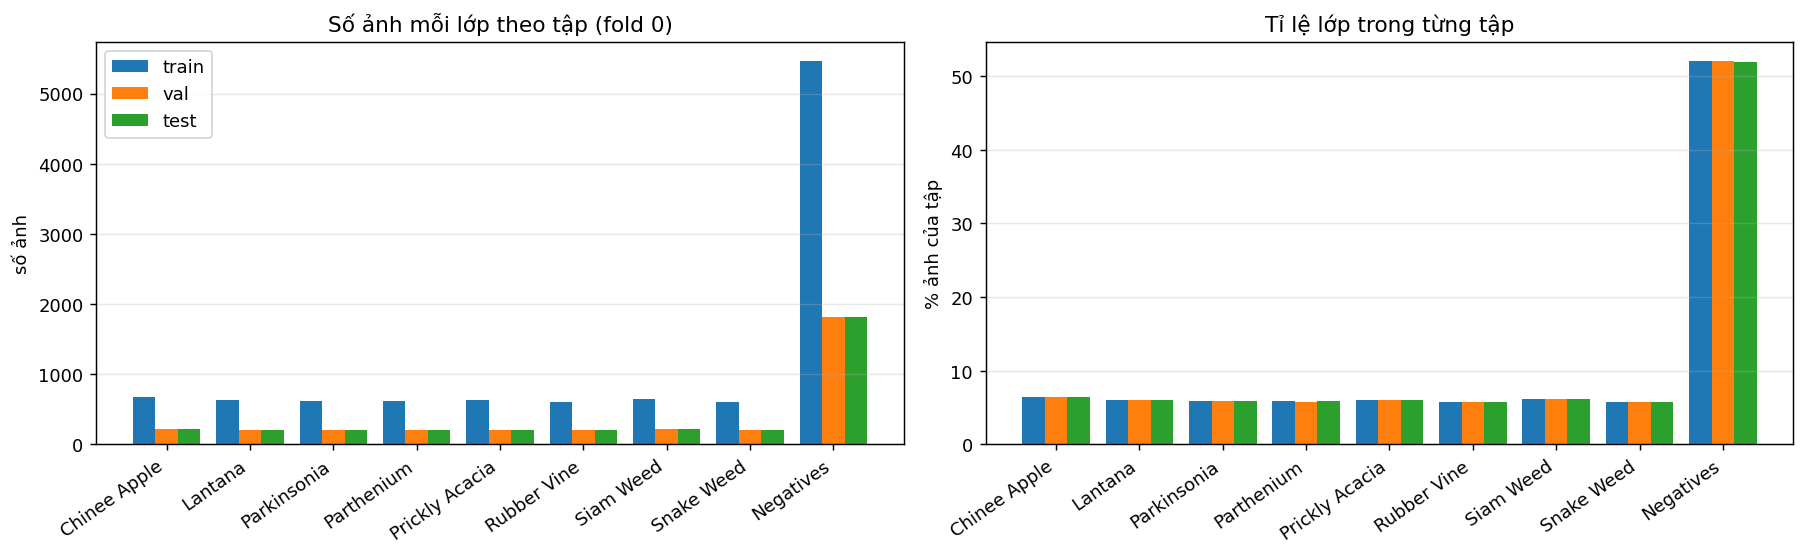

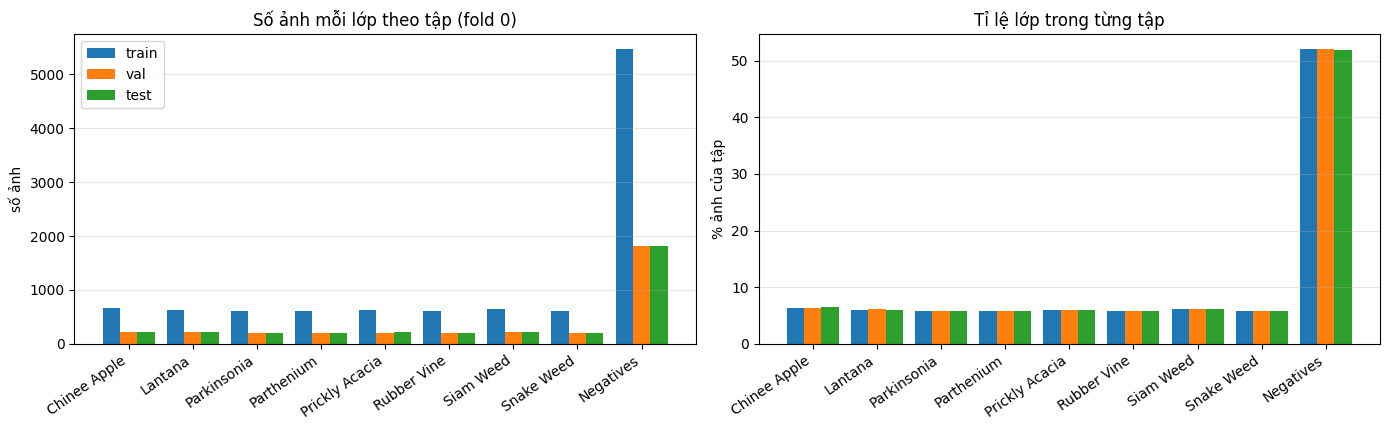

In [11]:
# ---- chia dữ liệu fold 0 và các kiểm tra bắt buộc (README mục 2.1)
train_df, val_df, test_df = ds.load_split(LABELS_DIR)
info = ds.check_split(train_df, val_df, test_df, IMAGES_DIR)
per_class = pd.DataFrame(info["per_class"])
PAPER = [1125, 1064, 1031, 1022, 1062, 1009, 1074, 1016, 9106]     # Table 1 của bài báo gốc (trích dẫn)
cmp = pd.DataFrame({"lớp": ds.CLASS_NAMES, "đếm được (tôi)": per_class["total"].values, "Table 1 bài báo": PAPER})
cmp["lệch"] = cmp["đếm được (tôi)"] - cmp["Table 1 bài báo"]
display(cmp)
print("tổng đếm được =", int(cmp["đếm được (tôi)"].sum()), "| tổng Table 1 =", sum(PAPER))
names_csv = ev.load_names(str(Path(LABELS_DIR) / "labels.csv"))
print("tên lớp theo labels.csv:", names_csv)
rt.plot_class_distribution(per_class[["train", "val", "test"]], FIG / "eda_class_distribution.png")
display(IPImage(str(FIG / "eda_class_distribution.png")))

**Nhận xét EDA:** `Negative` chiếm 52% (9.106 ảnh), mỗi loài 1.009–1.126 ảnh, tỉ lệ lớp lớn/nhỏ = 9,02×. Vì vậy đoán luôn `Negative` đã được top-1 ≈ 52% nhưng macro-F1 chỉ ≈ 0,076, nên chỉ số chính phải là macro-F1. Chia fold 0 đúng 59,97/20,00/20,03%, không giao nhau, hợp đủ 17.509 ảnh, mọi file tồn tại. Số đếm lệch Table 1 của bài báo ở Chinee apple (1.126 so với 1.125) và Lantana (1.063 so với 1.064), tổng vẫn 17.509 (chưa tìm nguyên nhân). Ảnh gốc đều 256×256 RGB; mean RGB ≈ (0,376; 0,388; 0,378) và std ≈ 0,235 (đo trên 1.500 ảnh), tối hơn ImageNet, nhưng vì dùng trọng số `timm` nên chuẩn hoá theo mean/std của chính trọng số. Qua ảnh mẫu (`figures/eda_samples.png`): ảnh chụp ngoài đồng, nền lẫn đất, lá khô, cỏ và bóng đổ mạnh, đôi khi lệch màu (ngả xanh/hồng); cây mục tiêu nhiều ảnh nhỏ hoặc thưa trong khung hình. Chinee apple, Lantana, Snake weed và Rubber vine đều là cây lá rộng nên bằng mắt dễ nhầm với nhau; Parkinsonia, Prickly acacia và nhiều ảnh `Negative` là đất/thảm mục có ít chi tiết cây.

cache: (17509, 256, 256, 3) uint8 (25s)
kích thước ảnh gốc (mẫu 300): {(256, 256): 300} | kênh: {'RGB': 300}
mean RGB = [0.376 0.388 0.378] | std RGB = [0.237 0.236 0.233] (mẫu 1500 ảnh) | ImageNet mean/std = (0.485, 0.456, 0.406) (0.229, 0.224, 0.225)


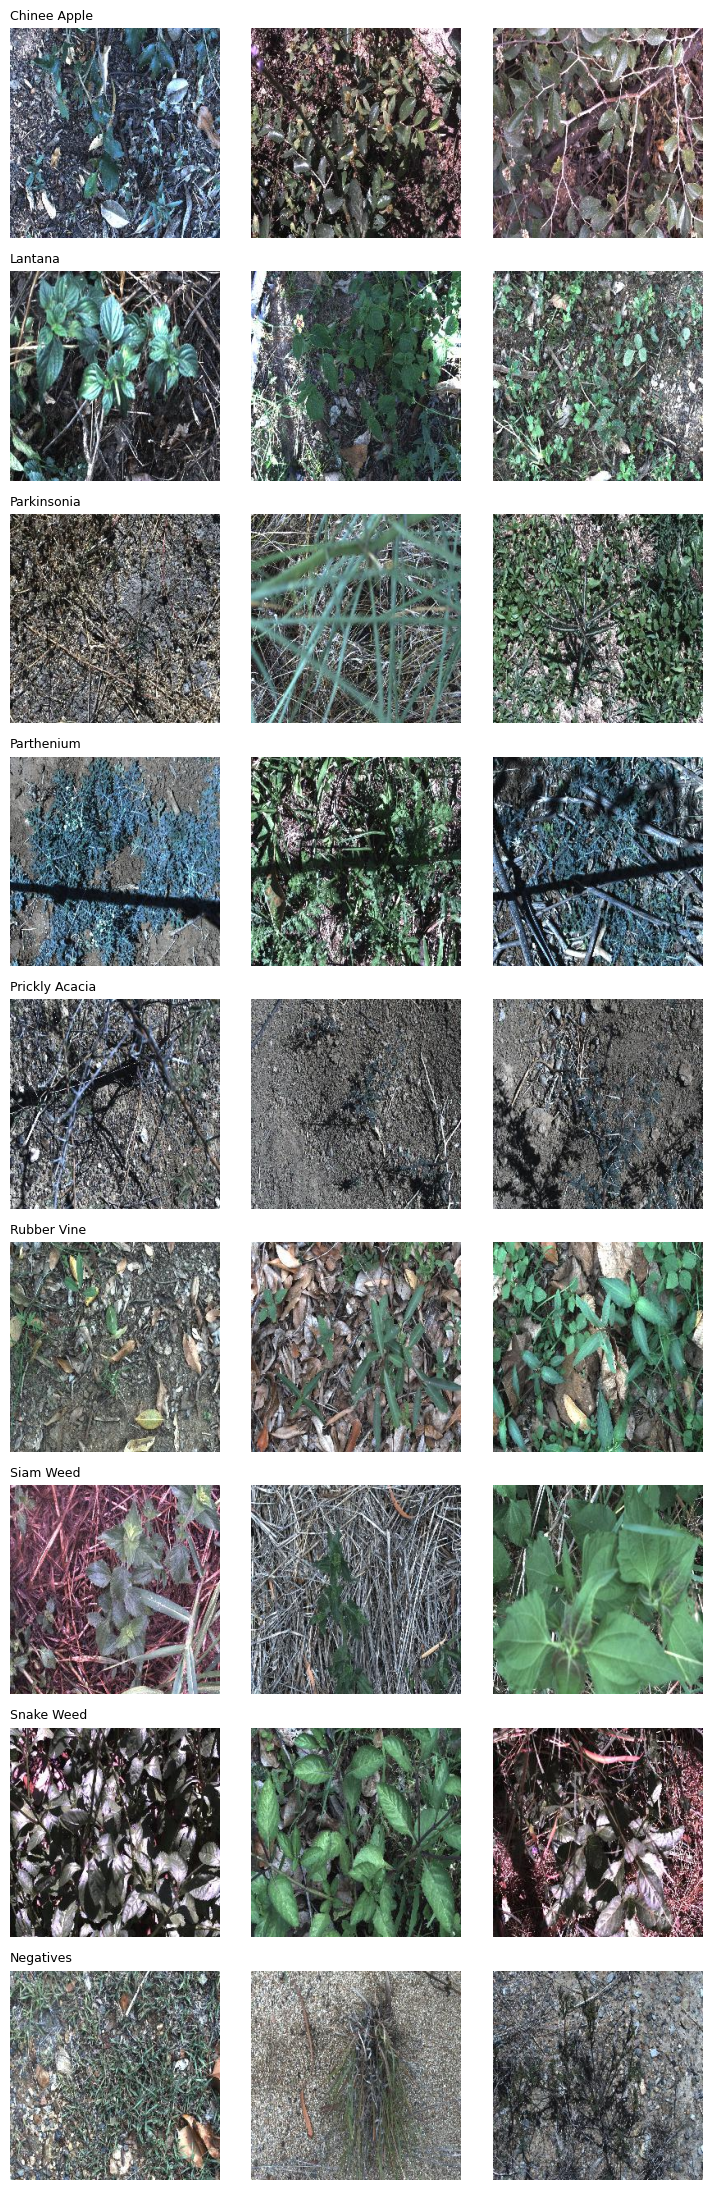

In [12]:
# ---- bộ nhớ đệm ảnh uint8 (giải mã JPEG một lần) và thống kê ảnh
from PIL import Image
from collections import Counter
all_names = pd.concat([train_df, val_df, test_df])["Filename"]
t0 = time.time()
store = ds.get_store(IMAGES_DIR, CACHE_DIR, all_names)
print("cache:", store.arr.shape, store.arr.dtype, f"({time.time() - t0:.0f}s)")
rng = np.random.default_rng(0)
sample = rng.choice(all_names.values, size=min(300, len(all_names)), replace=False)
sizes, modes = Counter(), Counter()
for f in sample:
    with Image.open(Path(IMAGES_DIR) / f) as im:
        sizes[im.size] += 1; modes[im.mode] += 1
print("kích thước ảnh gốc (mẫu 300):", dict(sizes), "| kênh:", dict(modes))
idx = np.sort(rng.choice(len(store.arr), size=min(1500, len(store.arr)), replace=False))
s1, s2, npx = np.zeros(3), np.zeros(3), 0                 # cộng dồn float64 theo lô (float32 sẽ bão hoà khi cộng ~1e8 số)
for k in range(0, len(idx), 100):
    b = np.asarray(store.arr[idx[k:k + 100]], dtype=np.float64) / 255.0
    s1 += b.sum((0, 1, 2)); s2 += (b ** 2).sum((0, 1, 2)); npx += b.shape[0] * b.shape[1] * b.shape[2]
mu_px = s1 / npx; sd_px = np.sqrt(s2 / npx - mu_px ** 2)
print("mean RGB =", np.round(mu_px, 3), "| std RGB =", np.round(sd_px, 3), f"(mẫu {len(idx)} ảnh)",
      "| ImageNet mean/std =", ds.IMAGENET_MEAN, ds.IMAGENET_STD)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(9, 3, figsize=(7.5, 22))
for c, name in enumerate(ds.CLASS_NAMES):
    rows = store.rows(train_df[train_df["Label"] == c]["Filename"].head(3))
    for j in range(3):
        axes[c, j].imshow(store.arr[rows[j]]); axes[c, j].axis("off")
        if j == 0:
            axes[c, j].set_title(name, fontsize=9, loc="left")
fig.tight_layout(); fig.savefig(FIG / "eda_samples.png", dpi=90); plt.show()

**Nhận xét ảnh mẫu:** ảnh chụp ngoài đồng với nền lẫn đất, lá khô, cỏ, bóng đổ mạnh và đôi khi lệch màu; cây mục tiêu nhiều ảnh nhỏ hoặc thưa. Chinee apple, Lantana, Snake weed, Rubber vine đều là cây lá rộng nên dễ nhầm với nhau bằng mắt; Parkinsonia, Prickly acacia và nhiều ảnh `Negatives` chủ yếu là đất/thảm mục/cỏ ít chi tiết. Mean/std RGB đo được ≈ (0,376; 0,388; 0,378)/(0,237; 0,236; 0,233), tối hơn ImageNet (0,485; 0,456; 0,406); vì dùng trọng số `timm` nên chuẩn hoá theo mean/std của chính trọng số.

  focal(gamma=0) - CE              4.77e-07
  LS(eps=0) - CE                   4.77e-07
  LS(eps=0.1) - torch              0.00e+00
  ce_weighted(đều) - CE            0.00e+00
  focal(gamma=2) <= CE             OK
  cutmix: max(đổi) <= 1 - lam      OK
  mixup: 0 <= lam <= 1             OK
  mixed_loss(lam=1) - CE           0.00e+00
self_test losses: OK


model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

loss ban đầu (CE, val, head mới) = 2.180  | -ln(1/9) = 2.197


/tmp/ipykernel_23/2745536995.py:21: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  loss = torch.nn.functional.cross_entropy(m0(xb), yb); loss.backward(); opt.step(); curve.append(float(loss))


overfit 16 ảnh: loss 2.201 -> 0.0011


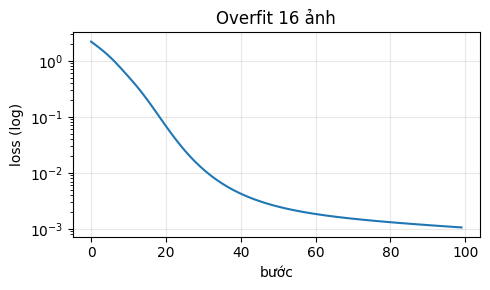

kiểm tra train/eval và BN khi đóng băng: OK


In [13]:
# ---- kiểm tra pipeline TRƯỚC khi chạy thật (slide trang 59; GUIDE mục 1.3)
ls.self_test()                                           # focal(gamma=0) == CE, label smoothing, CutMix, ...
SANITY = "resnet18" if QUICK else "resnet50"
tr.set_seed(0)
m0 = mdl.build_model(SANITY, pretrained=not QUICK, init="finetune").to(device)
nz0 = ds.Normalizer(m0.norm_mean, m0.norm_std)
VAL = ds.get_evalset("val", val_df, store, device, MAXEV)

# 1) loss ban đầu của head mới ~ -ln(1/9) = 2.197
lg = inf.predict_logits(m0, VAL.X[:512], device, nz0, inf.view_center(224))
loss0 = float(torch.nn.functional.cross_entropy(torch.from_numpy(lg), torch.from_numpy(VAL.y[:512])))
print(f"loss ban đầu (CE, val, head mới) = {loss0:.3f}  | -ln(1/9) = {math.log(9):.3f}")

# 2) overfit một batch nhỏ (16 ảnh) tới loss gần 0 (chế độ train, không augmentation)
m0.train()
xb = nz0(VAL.X[:16].to(device)); xb = inf.view_center(224)(xb); yb = torch.as_tensor(VAL.y[:16]).to(device)
opt = torch.optim.AdamW(m0.parameters(), lr=1e-3 if QUICK else 5e-4, weight_decay=0.0)
curve = []
for step in range(60 if QUICK else 100):
    opt.zero_grad(set_to_none=True)
    loss = torch.nn.functional.cross_entropy(m0(xb), yb); loss.backward(); opt.step(); curve.append(float(loss))
print(f"overfit 16 ảnh: loss {curve[0]:.3f} -> {curve[-1]:.4f}")
assert curve[-1] < 0.2, "không overfit được 1 batch nhỏ: kiểm tra code/model trước khi chạy tiếp"
plt.figure(figsize=(5, 3)); plt.semilogy(curve); plt.xlabel("bước"); plt.ylabel("loss (log)"); plt.title("Overfit 16 ảnh"); plt.grid(alpha=.3); plt.tight_layout()
plt.savefig(FIG / "sanity_overfit_batch.png", dpi=110); plt.show()

# 3) train()/eval() đúng lúc; backbone đóng băng -> BN ở eval
m0.eval(); assert not any(m.training for m in m0.modules())
mf = mdl.build_model(SANITY, pretrained=False, init="frozen"); mdl.set_train_mode(mf)
bn_train = [m for m in mf.modules() if isinstance(m, torch.nn.BatchNorm2d) and m.training]
assert not bn_train and mf.get_classifier().training and not any(p.requires_grad for n, p in mf.named_parameters() if not n.startswith(("fc", "classifier", "head")))
print("kiểm tra train/eval và BN khi đóng băng: OK")
del m0, mf, opt

**Nhận xét kiểm tra pipeline:** loss ban đầu = 2,180 so với ln 9 = 2,197 (head mới khởi tạo ngẫu nhiên trên đặc trưng tiền huấn luyện nên rất sát); overfit 16 ảnh: loss 2,201 → 0,0011 (≈ 0) ⇒ model, nhãn, loss, optimizer nối đúng; focal γ=0 ≡ CE và label smoothing ε=0 ≡ CE (sai số ~1e-7), CutMix điều chỉnh `lam` theo diện tích thật; BN ở eval khi backbone đóng băng; ảnh sau augmentation khớp nhãn.

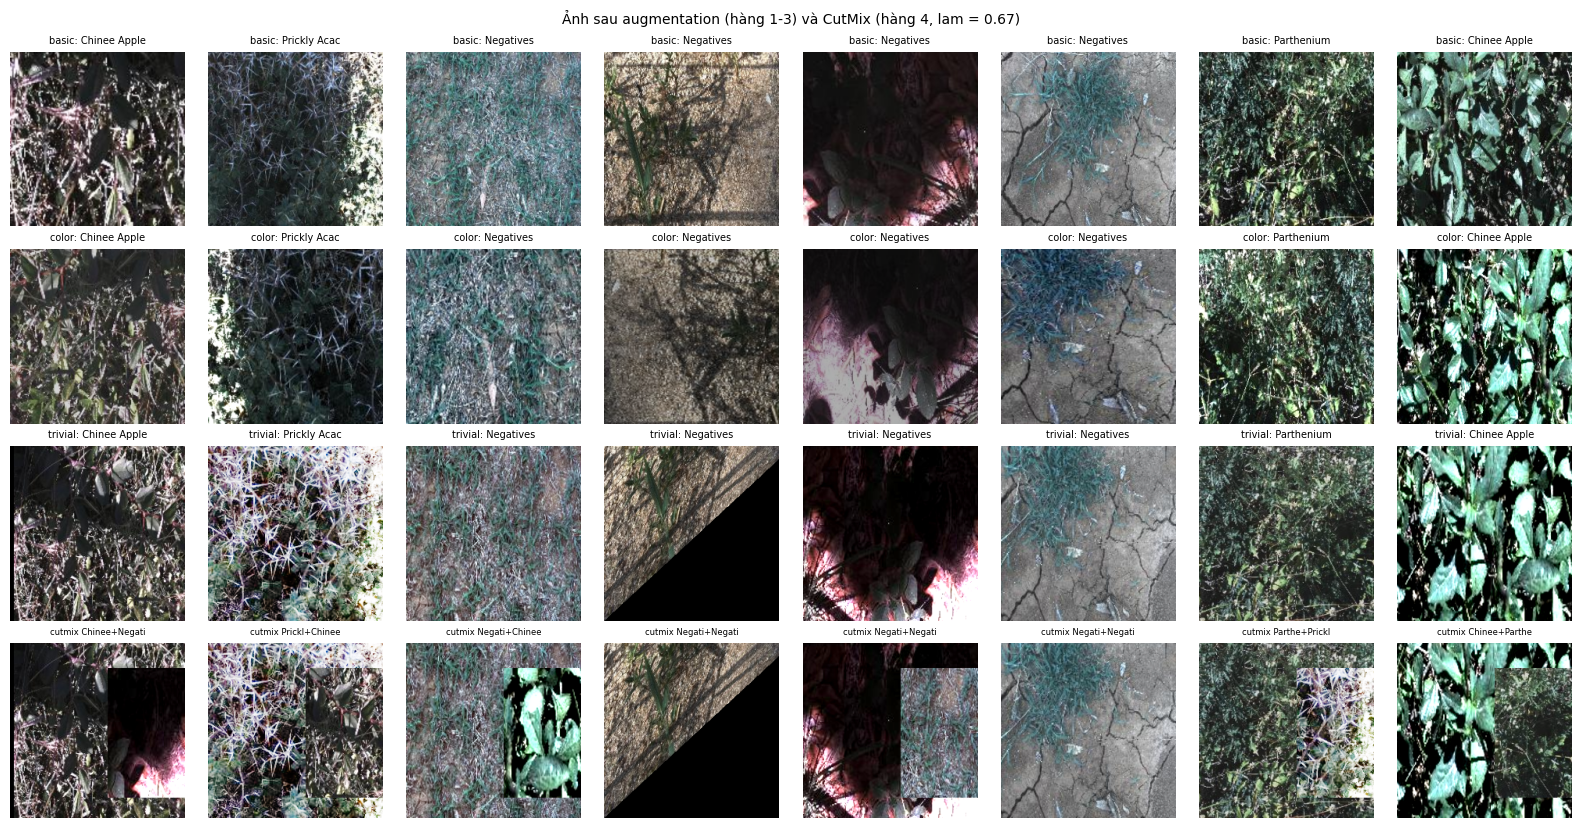

In [14]:
# ---- nhìn ảnh SAU augmentation (đã giải chuẩn hoá) cùng nhãn: ảnh và nhãn phải khớp nhau
nz_v = ds.Normalizer()
sub = train_df.sample(8, random_state=1).reset_index(drop=True)
fig, axes = plt.subplots(4, 8, figsize=(16, 8.4))
for r, aug in enumerate(["basic", "color", "trivial"]):
    tf = ds.build_transforms(True, 224, aug)
    ld = ds.make_loader(sub, IMAGES_DIR, tf, 8, False, None, 0, store, 0)
    xb, yb, _ = next(iter(ld))
    for j in range(8):
        axes[r, j].imshow(nz_v.denormalize(nz_v(xb[j:j + 1]))[0].permute(1, 2, 0).numpy()); axes[r, j].axis("off")
        axes[r, j].set_title(f"{aug}: {ds.CLASS_NAMES[int(yb[j])][:12]}", fontsize=7)
tr.set_seed(0)
xm, (ya, yb2, lam) = ls.mix_batch(nz_v(xb), yb, 1.0, "cutmix")
for j in range(8):
    axes[3, j].imshow(nz_v.denormalize(xm[j:j + 1])[0].permute(1, 2, 0).numpy()); axes[3, j].axis("off")
    axes[3, j].set_title(f"cutmix {ds.CLASS_NAMES[int(ya[j])][:6]}+{ds.CLASS_NAMES[int(yb2[j])][:6]}", fontsize=6)
fig.suptitle(f"Ảnh sau augmentation (hàng 1-3) và CutMix (hàng 4, lam = {lam:.2f})", fontsize=10)
fig.tight_layout(); fig.savefig(FIG / "sanity_augmentation.png", dpi=90); plt.show()

## Bước 1 — So sánh backbone (≥ 5), cùng công thức nền `T00`
**Công thức nền (GUIDE 1.4), giống nhau cho mọi backbone:** trọng số ImageNet của `timm`, head mới 9 lớp, tinh chỉnh toàn bộ; train `RandomResizedCrop(224, scale 0.25–1)` + lật ngang, val/test center-crop 224 từ ảnh 256;
chuẩn hoá theo mean/std của trọng số; AdamW, LR backbone 1e-4 / head 1e-3, weight decay 0,05 (không áp dụng cho norm và bias), warmup 1 epoch + cosine về 0, CE, batch 64, **12 epoch**, AMP FP16; chọn checkpoint theo macro-F1 val
(hòa lấy epoch sớm hơn). Mỗi backbone 1 lần chạy, **cùng seed 0**; thời gian/epoch tính trên GPU của phiên này.

**Dự đoán trước:** các CNN tiền huấn luyện (ResNet-50, ResNeXt-50, ConvNeXt-T) cho macro-F1 val cao và gần nhau (chênh dưới ~0,01); DeiT-S/Swin-T tinh chỉnh với LR này kém hoặc xấp xỉ CNN vì thiên kiến quy nạp yếu hơn và 10,5k ảnh là ít;
mạng nhẹ (EfficientNet-B0, MobileNetV3) thấp hơn vài điểm nhưng nhanh hơn nhiều; thứ hạng trên DeepWeeds không trùng hoàn toàn thứ hạng ImageNet; FLOPs (GMAC) không dự đoán chính xác độ trễ.

In [15]:
BACKBONES = [("B01", "resnet50"), ("B02", "resnext50_32x4d"), ("B03", "convnext_tiny"), ("B04", "deit_small_patch16_224"),
             ("B05", "swin_tiny_patch4_window7_224"), ("B06", "efficientnet_b0"), ("B07", "mobilenetv3_large_100")]
if LITE:
    BACKBONES = [b for b in BACKBONES if b[0] in ("B01", "B03", "B04", "B06", "B07")]   # vẫn thoả: ResNet, ConvNeXt, transformer, mạng nhẹ
if QUICK:                             # chỉ để chạy thử code trên CPU: các mạng nhỏ cùng họ
    BACKBONES = [("B01", "resnet18"), ("B02", "convnext_atto"), ("B03", "deit_tiny_patch16_224"), ("B04", "mobilenetv3_small_100")]
B, LAT = {}, []                       # B: kết quả từng backbone; LAT: mọi lần đo độ trễ (sheet Latency)

def lat(model, label, batch=1, res=224, dtype="fp32", fused=False):
    # Đo độ trễ forward đúng cách (warmup, synchronize, p50/p95/p99) và ghi vào bảng Latency
    r = bm.latency_report(model, batch, res, dtype, device=DEV, warmup=WARM, iters=ITERS, bn_fused=fused, label=label)
    LAT.append(r)
    return r

for eid, name in BACKBONES:
    B[eid] = tr.run(mk(eid, backbone=name, mota=name))
rows = []
for eid, name in BACKBONES:
    s = B[eid]
    arch = mdl.build_model(name, pretrained=False, init="scratch").to(device)
    l1 = lat(arch, f"{eid} {name} (batch 1)")
    del arch
    rows.append({"exp_id": eid, "backbone": name, "tag trọng số": s["weight_tag"], "tham số (M)": s["params_m"], "GMAC": s["gmac"],
                 "độ phân giải": s["img_size"], "epoch": s["epochs"], "seed": s["seed"], "macro-F1 val": s["val_f1"], "top-1 val": s["val_top1"],
                 "thời gian train/epoch (s)": s["time_per_epoch_s"], "độ trễ batch-1 p50 (ms)": l1["p50"], "độ trễ batch-1 p95 (ms)": l1["p95"],
                 "ghi chú": "mạng nhẹ" if mdl.is_light(name) else ""})
BB = pd.DataFrame(rows)
display(BB.round(4))

[B01 s0] ep  1/12 train 1.6397 val 1.2414 F1 0.2394 top1 0.5718 (37s)
[B01 s0] ep  2/12 train 0.9233 val 0.7479 F1 0.6188 top1 0.7352 (35s)
[B01 s0] ep  3/12 train 0.6358 val 0.5962 F1 0.7091 top1 0.7952 (36s)
[B01 s0] ep  4/12 train 0.5023 val 0.5404 F1 0.7509 top1 0.8195 (35s)
[B01 s0] ep  5/12 train 0.4278 val 0.4876 F1 0.7771 top1 0.8380 (36s)
[B01 s0] ep  6/12 train 0.3852 val 0.4578 F1 0.7941 top1 0.8483 (35s)
[B01 s0] ep  7/12 train 0.3633 val 0.4653 F1 0.7855 top1 0.8443 (36s)
[B01 s0] ep  8/12 train 0.3290 val 0.4509 F1 0.8018 top1 0.8543 (35s)
[B01 s0] ep  9/12 train 0.3177 val 0.4432 F1 0.7988 top1 0.8538 (35s)
[B01 s0] ep 10/12 train 0.3123 val 0.4469 F1 0.8000 top1 0.8535 (35s)
[B01 s0] ep 11/12 train 0.2921 val 0.4368 F1 0.7990 top1 0.8526 (35s)
[B01 s0] ep 12/12 train 0.3003 val 0.4342 F1 0.8027 top1 0.8552 (35s)
[B01 s0] xong: best epoch 12, val macro-F1 0.8030, top-1 0.8555, 36s/epoch


model.safetensors: reconstructing file:   0%|          |  0.00B /  100MB            

model.safetensors: downloading bytes:           |  0.00B            

/kaggle/working/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602559_nguyen_thanh_hoa/code/train.py:211: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[B02 s0] ep  1/12 train 1.6016 val 1.4845 F1 0.2097 top1 0.4807 (56s)
[B02 s0] ep  2/12 train 0.7021 val 1.0684 F1 0.4681 top1 0.6130 (44s)
[B02 s0] ep  3/12 train 0.4338 val 0.7201 F1 0.6595 top1 0.7512 (45s)
[B02 s0] ep  4/12 train 0.3284 val 0.7126 F1 0.6957 top1 0.7578 (45s)
[B02 s0] ep  5/12 train 0.2672 val 0.7318 F1 0.6721 top1 0.7458 (45s)
[B02 s0] ep  6/12 train 0.2294 val 0.6886 F1 0.6994 top1 0.7655 (44s)
[B02 s0] ep  7/12 train 0.2108 val 0.6936 F1 0.7088 top1 0.7652 (44s)
[B02 s0] ep  8/12 train 0.1799 val 0.6442 F1 0.7317 top1 0.7858 (45s)
[B02 s0] ep  9/12 train 0.1635 val 0.5996 F1 0.7530 top1 0.8006 (45s)
[B02 s0] ep 10/12 train 0.1534 val 0.6251 F1 0.7370 top1 0.7898 (45s)
[B02 s0] ep 11/12 train 0.1457 val 0.5759 F1 0.7490 top1 0.8021 (45s)
[B02 s0] ep 12/12 train 0.1466 val 0.5924 F1 0.7496 top1 0.7998 (44s)
[B02 s0] xong: best epoch 9, val macro-F1 0.7539, top-1 0.8018, 46s/epoch


...

[B06 s0] ep  1/12 train 2.1002 val 1.4251 F1 0.4105 top1 0.5390 (75s)
[B06 s0] ep  2/12 train 0.7297 val 1.0363 F1 0.5518 top1 0.6555 (25s)
[B06 s0] ep  3/12 train 0.4745 val 0.8580 F1 0.6330 top1 0.7329 (25s)
[B06 s0] ep  4/12 train 0.3607 val 0.7406 F1 0.6697 top1 0.7549 (25s)
[B06 s0] ep  5/12 train 0.2893 val 0.7495 F1 0.6832 top1 0.7684 (25s)
[B06 s0] ep  6/12 train 0.2412 val 0.6579 F1 0.7268 top1 0.7952 (25s)
[B06 s0] ep  7/12 train 0.2108 val 0.5922 F1 0.7412 top1 0.8078 (25s)
[B06 s0] ep  8/12 train 0.1804 val 0.6068 F1 0.7371 top1 0.8043 (25s)
[B06 s0] ep  9/12 train 0.1567 val 0.5707 F1 0.7595 top1 0.8223 (25s)
[B06 s0] ep 10/12 train 0.1578 val 0.5871 F1 0.7522 top1 0.8172 (25s)
[B06 s0] ep 11/12 train 0.1445 val 0.5474 F1 0.7700 top1 0.8306 (25s)
[B06 s0] ep 12/12 train 0.1388 val 0.5376 F1 0.7709 top1 0.8289 (25s)
[B06 s0] xong: best epoch 12, val macro-F1 0.7717, top-1 0.8292, 29s/epoch


model.safetensors: reconstructing file:   0%|          |  0.00B / 22.1MB            

model.safetensors: downloading bytes:           |  0.00B            

[B07 s0] ep  1/12 train 1.8197 val 1.4606 F1 0.3786 top1 0.5287 (50s)
[B07 s0] ep  2/12 train 0.7026 val 1.3471 F1 0.4510 top1 0.6027 (14s)
[B07 s0] ep  3/12 train 0.4777 val 1.0548 F1 0.5259 top1 0.6564 (14s)
[B07 s0] ep  4/12 train 0.3616 val 0.8624 F1 0.6152 top1 0.7261 (14s)
[B07 s0] ep  5/12 train 0.2881 val 0.9347 F1 0.6026 top1 0.7027 (14s)
[B07 s0] ep  6/12 train 0.2509 val 0.7693 F1 0.6531 top1 0.7506 (14s)
[B07 s0] ep  7/12 train 0.2203 val 0.7269 F1 0.6683 top1 0.7609 (14s)
[B07 s0] ep  8/12 train 0.1827 val 0.7209 F1 0.6741 top1 0.7632 (14s)
[B07 s0] ep  9/12 train 0.1708 val 0.7175 F1 0.6801 top1 0.7669 (14s)
[B07 s0] ep 10/12 train 0.1654 val 0.7116 F1 0.6787 top1 0.7675 (14s)
[B07 s0] ep 11/12 train 0.1562 val 0.6796 F1 0.6911 top1 0.7778 (14s)
[B07 s0] ep 12/12 train 0.1554 val 0.6929 F1 0.6879 top1 0.7718 (14s)
[B07 s0] xong: best epoch 11, val macro-F1 0.6888, top-1 0.7758, 17s/epoch


,exp_id,backbone,tag trọng số,tham số (M),GMAC,độ phân giải,epoch,seed,macro-F1 val,top-1 val,thời gian train/epoch (s),độ trễ batch-1 p50 (ms),độ trễ batch-1 p95 (ms),ghi chú
0,B01,resnet50,resnet50 (timm/resnet50.a1_in1k),23.5265,4.0872,224,12,0,0.8030,0.8555,35.5476,6.2410,6.6769,
1,B02,resnext50_32x4d,resnext50_32x4d (timm/resnext50_32x4d.a1h_in1k),22.9983,4.2285,224,12,0,0.7539,0.8018,45.6034,6.1820,6.6049,
2,B03,convnext_tiny,convnext_tiny (timm/convnext_tiny.in12k_ft_in1k),27.8270,4.4548,224,12,0,0.9658,0.9726,52.8192,5.8610,6.3497,
3,B04,deit_small_patch16_224,deit_small_patch16_224 (timm/deit_small_patch1...,21.6691,4.5985,224,12,0,0.9556,0.9677,34.8018,5.3785,6.8511,
4,B05,swin_tiny_patch4_window7_224,swin_tiny_patch4_window7_224 (timm/swin_tiny_p...,27.5263,4.4898,224,12,0,0.9519,0.9640,66.8473,10.1563,10.6131,
5,B06,efficientnet_b0,efficientnet_b0 (timm/efficientnet_b0.ra_in1k),4.0191,0.3845,224,12,0,0.7717,0.8292,28.9233,7.9305,8.8348,mạng nhẹ
6,B07,mobilenetv3_large_100,mobilenetv3_large_100 (timm/mobilenetv3_large_...,4.2136,0.2153,224,12,0,0.6888,0.7758,16.7932,6.4571,6.7576,mạng nhẹ


ĐI TIẾP (Bước 2, 3, 4): convnext_tiny (B03) có macro-F1 val cao nhất (0.9658), độ trễ batch-1 p50 5.9 ms, 27.8M tham số; mạng nhẹ tốt nhất là efficientnet_b0 (B06): macro-F1 0.7717, p50 7.9 ms
tương quan hạng (Spearman) giữa GMAC / độ trễ / thời gian train / số tham số:


,GMAC,độ trễ batch-1 p50 (ms),thời gian train/epoch (s),tham số (M)
GMAC,1.00,-0.43,0.64,0.54
độ trễ batch-1 p50 (ms),-0.43,1.00,0.00,-0.18
thời gian train/epoch (s),0.64,0.00,1.00,0.89
tham số (M),0.54,-0.18,0.89,1.00


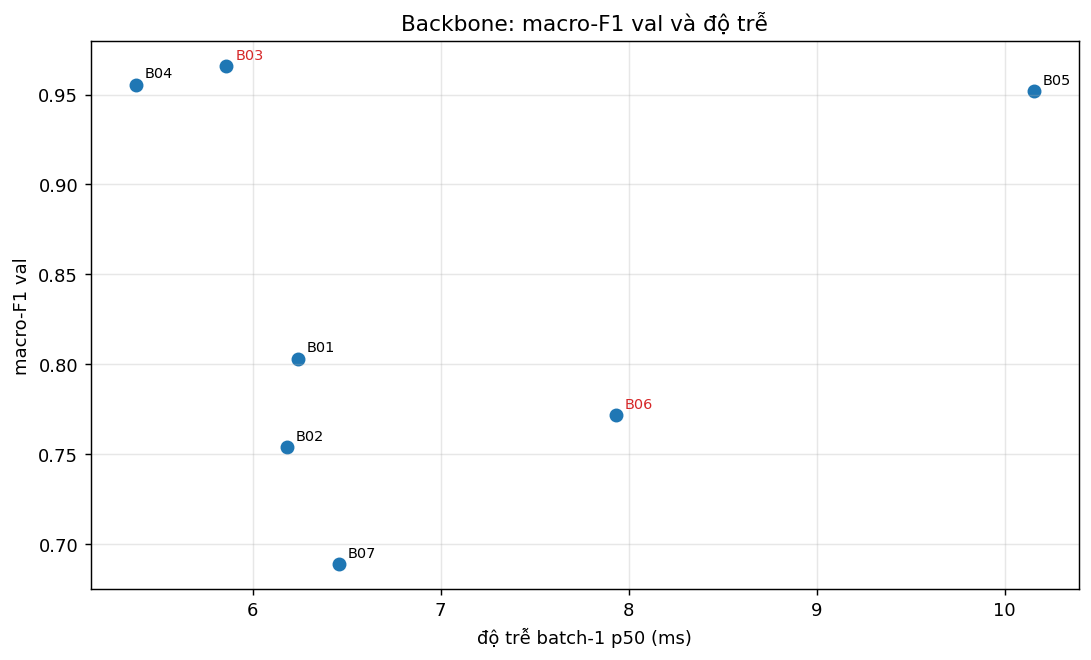

In [16]:
# ---- chọn backbone đi tiếp (lý do dựa trên số liệu) và biểu đồ đánh đổi
BBs = BB.sort_values("macro-F1 val", ascending=False).reset_index(drop=True)
MAIN_ID, MAIN = BBs.loc[0, "exp_id"], BBs.loc[0, "backbone"]
light = BB[BB["backbone"].map(mdl.is_light)].sort_values("macro-F1 val", ascending=False).reset_index(drop=True)
LIGHT_ID, LIGHT = light.loc[0, "exp_id"], light.loc[0, "backbone"]
MAIN_ROW, LIGHT_ROW = BBs.loc[0], light.loc[0]
MAIN_REASON = (f"{MAIN} ({MAIN_ID}) có macro-F1 val cao nhất ({MAIN_ROW['macro-F1 val']:.4f}), độ trễ batch-1 p50 {MAIN_ROW['độ trễ batch-1 p50 (ms)']:.1f} ms, "
               f"{MAIN_ROW['tham số (M)']:.1f}M tham số; mạng nhẹ tốt nhất là {LIGHT} ({LIGHT_ID}): macro-F1 {LIGHT_ROW['macro-F1 val']:.4f}, "
               f"p50 {LIGHT_ROW['độ trễ batch-1 p50 (ms)']:.1f} ms")
print("ĐI TIẾP (Bước 2, 3, 4):", MAIN_REASON)
try:
    cor = BB[["GMAC", "độ trễ batch-1 p50 (ms)", "thời gian train/epoch (s)", "tham số (M)"]].corr(method="spearman")
    print("tương quan hạng (Spearman) giữa GMAC / độ trễ / thời gian train / số tham số:"); display(cor.round(2))
except Exception as e:
    print("không tính được tương quan:", e)
rt.plot_tradeoff(BB, "độ trễ batch-1 p50 (ms)", "macro-F1 val", "exp_id", FIG / "backbone_f1_vs_latency.png", "độ trễ batch-1 p50 (ms)",
                 "macro-F1 val", "Backbone: macro-F1 val và độ trễ", highlight=[MAIN_ID, LIGHT_ID])
rt.plot_tradeoff(BB, "tham số (M)", "macro-F1 val", "exp_id", FIG / "backbone_f1_vs_params.png", "tham số (triệu)", "macro-F1 val",
                 "Backbone: macro-F1 val và kích thước", highlight=[MAIN_ID, LIGHT_ID])
display(IPImage(str(FIG / "backbone_f1_vs_latency.png")))

**Đối chiếu Bước 1:** thứ hạng macro-F1 val: ConvNeXt-T 0,9658 > DeiT-S 0,9556 > Swin-T 0,9519 ≫ ResNet-50 0,8030 > EfficientNet-B0 0,7717 > ResNeXt-50 0,7539 > MobileNetV3-L 0,6888. *Khác dự đoán:* transformer (DeiT-S, Swin-T) không kém mà xấp xỉ ConvNeXt-T, còn ResNet-50/ResNeXt-50 thấp hơn rất xa, và ResNeXt-50 thấp hơn ResNet-50 (ngược thứ hạng ImageNet). Mạng nhẹ thấp hơn như dự đoán nhưng chênh tới 0,19–0,28. *Hội tụ/quá khớp (từ `curves/` và `runs/*/history.csv`):* ConvNeXt-T, DeiT-S, Swin-T hội tụ nhanh (ConvNeXt-T đã đạt F1 val 0,839 sau epoch 1) và train loss cuối chỉ 0,011–0,025 nên khoảng cách val−train loss ≈ 0,09–0,11 (hơi quá khớp); ngược lại bốn CNN dùng BatchNorm học chậm và khái quát kém: train loss cuối 0,30 (ResNet-50), 0,15 (ResNeXt-50), 0,14 (EfficientNet-B0), 0,16 (MobileNetV3-L), cao hơn ConvNeXt-T 13–28 lần, cùng val loss 0,43–0,69; F1 val còn tăng ở epoch 12 (ResNet-50: 0,794 ở epoch 6 → 0,803 ở epoch 12). Giải thích khả dĩ (chưa kiểm chứng): LR backbone 1e-4 với AdamW và 12 epoch quá thấp/không hợp cho các trọng số CNN này (tag `a1_in1k`, `a1h_in1k`, `ra_in1k` huấn luyện bằng công thức riêng); công thức nền không được chỉnh riêng cho từng backbone. *Biến nhiễu quan trọng:* trọng số ConvNeXt-T là `in12k_ft_in1k` (tiền huấn luyện trên ImageNet-12k lớn hơn), trong khi các mạng khác là ImageNet-1k, nên không thể quy khoảng cách cho riêng kiến trúc (câu hỏi GUIDE mục 9, câu 1). *FLOPs không dự đoán độ trễ:* GMAC từ 0,22 đến 4,60 nhưng độ trễ batch-1 chỉ 5,4–10,2 ms; Swin-T (4,49 GMAC) chậm gấp ~1,7× ConvNeXt-T (4,45 GMAC), và EfficientNet-B0 (0,38 GMAC, ít hơn ResNet-50 ~11×) lại chậm hơn ResNet-50 (7,9 so với 6,2 ms); hạng độ trễ so với hạng GMAC có Spearman −0,43, trong khi thời gian train/epoch bám theo số tham số/GMAC hơn (Spearman 0,64–0,89). Ở batch 1 trên T4, độ trễ bị chi phối bởi số lượng và loại kernel chứ không phải số phép nhân. *Lý do chọn đi tiếp:* ConvNeXt-T có macro-F1 val cao nhất với độ trễ ngang các mạng khác (5,9 ms) nên không có đánh đổi nào buộc phải chọn mạng khác; mạng nhẹ tốt nhất (EfficientNet-B0) vừa kém F1 vừa không nhanh hơn trên T4.

## Bước 2 — Công thức huấn luyện (trên backbone đã chọn, mỗi lần chỉ đổi MỘT yếu tố so với `T00`)
`T00` = công thức nền trên backbone được chọn ở Bước 1, **3 seed (0, 1, 2)** để đo nhiễu: σ = std mẫu (ddof = 1) của macro-F1 val; ngưỡng "có ý nghĩa" = max(2σ, 0,003) (slide trang 59: dưới ~0,3 điểm là nhiễu).
Các thí nghiệm khác chạy **1 seed (seed 0)** nên chỉ kết luận "tốt hơn/kém hơn" khi |Δ| vượt ngưỡng; còn lại ghi "không phân biệt được". Ablation chỉ chạy trên **1 backbone** (giảm ngân sách theo GUIDE mục 7; ghi trong báo cáo).

| Trục | Giá trị thử (cạnh `T00`) | Dự đoán trước |
|---|---|---|
| A. Khởi tạo | từ đầu · đóng băng backbone | từ đầu kém hơn rõ (10,5k ảnh, 12 epoch, LR 1e-4); đóng băng kém tinh chỉnh toàn bộ nhưng không tệ (đặc trưng ImageNet tổng quát) |
| B. Augmentation | + ColorJitter · TrivialAugment · Mixup · CutMix | ColorJitter/TrivialAugment giúp ít (ảnh cùng robot/camera, ánh sáng đổi theo giờ); Mixup/CutMix có thể hại ở 12 epoch (nhãn là loài, vật thể chiếm phần lớn khung hình, cắt dán dễ mất vật thể) |
| C. Loss | label smoothing 0,1 · focal γ=2 · CE trọng số 1/n_c · class-balanced β=0,999 | loss có trọng số tăng recall lớp loài (hiếm hơn `Negatives` 5–9 lần) nhưng có thể giảm precision/recall của `Negatives`; macro-F1 tăng nhẹ hoặc không đổi; focal ≈ CE |
| D. Sampler | cân bằng lớp (oversample) | tương tự loss có trọng số, có thể quá khớp ảnh lớp nhỏ |
| E. LR | LR head = LR backbone · LR ×3 · không warmup | mạng tiền huấn luyện nhạy LR vừa phải: LR head = backbone chậm hơn; ×3 có thể tốt hơn hoặc hơi dao động; bỏ warmup ít ảnh hưởng với AdamW |
| F. Chính quy hoá | EMA 0,995 · stochastic depth 0,1 | EMA tăng nhẹ và ổn định (đường cong val ít nhiễu); stochastic depth ít tác dụng ở 12 epoch |
| G. Độ phân giải | 256 (train và test) | 256 hơi tốt hơn 224 (nhiều chi tiết hơn) nhưng chậm hơn ~1,3×; chỉ khảo sát, không đưa vào công thức cuối để giữ cố định giao thức suy luận 224 (độ phân giải test được khảo sát riêng ở I04) |

In [17]:
T00_RUNS = [tr.run(mk("T00", seed=s, backbone=MAIN, mota=f"baseline_{MAIN}")) for s in (0, 1, 2)]
f1s = np.array([r["val_f1"] for r in T00_RUNS])
SIGMA = float(f1s.std(ddof=1)); THR = max(2 * SIGMA, 0.003)
print(f"T00 ({MAIN}) macro-F1 val qua 3 seed: {f1s.round(4).tolist()} -> {f1s.mean():.4f} ± {SIGMA:.4f}; ngưỡng nhiễu = max(2σ, 0.003) = {THR:.4f}")
print("top-1 val:", [round(r["val_top1"], 4) for r in T00_RUNS], "| B-run cùng cấu hình, seed 0 (đối chiếu tái lập):", round(B[MAIN_ID]["val_f1"], 4))
T00_REF = T00_RUNS[0]["val_f1"]         # mốc cho các thí nghiệm seed 0

/kaggle/working/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602559_nguyen_thanh_hoa/code/train.py:211: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[T00 s0] ep  1/12 train 0.6865 val 0.3651 F1 0.8386 top1 0.8775 (53s)
[T00 s0] ep  2/12 train 0.2630 val 0.2275 F1 0.9114 top1 0.9240 (51s)
[T00 s0] ep  3/12 train 0.1737 val 0.1603 F1 0.9325 top1 0.9486 (51s)
[T00 s0] ep  4/12 train 0.1366 val 0.1452 F1 0.9444 top1 0.9563 (50s)
[T00 s0] ep  5/12 train 0.1062 val 0.1521 F1 0.9399 top1 0.9532 (50s)
[T00 s0] ep  6/12 train 0.0666 val 0.1543 F1 0.9469 top1 0.9594 (50s)
[T00 s0] ep  7/12 train 0.0518 val 0.1548 F1 0.9507 top1 0.9594 (50s)
[T00 s0] ep  8/12 train 0.0385 val 0.1094 F1 0.9645 top1 0.9709 (50s)
[T00 s0] ep  9/12 train 0.0210 val 0.1153 F1 0.9585 top1 0.9663 (50s)
[T00 s0] ep 10/12 train 0.0169 val 0.1194 F1 0.9616 top1 0.9683 (50s)
[T00 s0] ep 11/12 train 0.0126 val 0.1053 F1 0.9658 top1 0.9726 (50s)
[T00 s0] ep 12/12 train 0.0109 val 0.1068 F1 0.9639 top1 0.9706 (50s)
[T00 s0] xong: best epoch 11, val macro-F1 0.9658, top-1 0.9726, 50s/epoch


/kaggle/working/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602559_nguyen_thanh_hoa/code/train.py:211: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[T00 s1] ep  1/12 train 0.7647 val 0.2959 F1 0.8696 top1 0.9026 (52s)
[T00 s1] ep  2/12 train 0.2613 val 0.1652 F1 0.9265 top1 0.9426 (50s)
[T00 s1] ep  3/12 train 0.1584 val 0.1830 F1 0.9310 top1 0.9446 (51s)
[T00 s1] ep  4/12 train 0.1285 val 0.1806 F1 0.9275 top1 0.9423 (50s)
[T00 s1] ep  5/12 train 0.0978 val 0.1629 F1 0.9360 top1 0.9526 (50s)
[T00 s1] ep  6/12 train 0.0744 val 0.1300 F1 0.9464 top1 0.9594 (50s)
[T00 s1] ep  7/12 train 0.0467 val 0.1095 F1 0.9613 top1 0.9703 (50s)
[T00 s1] ep  8/12 train 0.0316 val 0.1504 F1 0.9475 top1 0.9583 (50s)
[T00 s1] ep  9/12 train 0.0209 val 0.1110 F1 0.9592 top1 0.9694 (49s)
[T00 s1] ep 10/12 train 0.0145 val 0.1093 F1 0.9618 top1 0.9714 (50s)
[T00 s1] ep 11/12 train 0.0137 val 0.0995 F1 0.9678 top1 0.9751 (50s)
[T00 s1] ep 12/12 train 0.0130 val 0.1025 F1 0.9674 top1 0.9751 (50s)
[T00 s1] xong: best epoch 11, val macro-F1 0.9681, top-1 0.9754, 50s/epoch


/kaggle/working/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602559_nguyen_thanh_hoa/code/train.py:211: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[T00 s2] ep  1/12 train 0.7482 val 0.3618 F1 0.8498 top1 0.8820 (52s)
[T00 s2] ep  2/12 train 0.2645 val 0.3031 F1 0.8840 top1 0.9032 (51s)
[T00 s2] ep  3/12 train 0.1667 val 0.2329 F1 0.9069 top1 0.9249 (50s)
[T00 s2] ep  4/12 train 0.1411 val 0.1938 F1 0.9245 top1 0.9403 (50s)
[T00 s2] ep  5/12 train 0.0829 val 0.1564 F1 0.9392 top1 0.9554 (50s)
[T00 s2] ep  6/12 train 0.0631 val 0.1278 F1 0.9497 top1 0.9609 (50s)
[T00 s2] ep  7/12 train 0.0546 val 0.1083 F1 0.9580 top1 0.9677 (50s)
[T00 s2] ep  8/12 train 0.0281 val 0.0976 F1 0.9680 top1 0.9763 (50s)
[T00 s2] ep  9/12 train 0.0242 val 0.1016 F1 0.9672 top1 0.9751 (50s)
[T00 s2] ep 10/12 train 0.0129 val 0.0939 F1 0.9710 top1 0.9780 (50s)
[T00 s2] ep 11/12 train 0.0134 val 0.0908 F1 0.9721 top1 0.9794 (49s)
[T00 s2] ep 12/12 train 0.0096 val 0.0901 F1 0.9726 top1 0.9794 (49s)
[T00 s2] xong: best epoch 12, val macro-F1 0.9726, top-1 0.9794, 50s/epoch
T00 (convnext_tiny) macro-F1 val qua 3 seed: [0.9658, 0.9681, 0.9726] -> 0.9688 ± 0.0

/kaggle/working/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602559_nguyen_thanh_hoa/code/train.py:211: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[T01 s0] ep  1/12 train 1.6893 val 1.5843 F1 0.1161 top1 0.5261 (51s)
[T01 s0] ep  2/12 train 1.5921 val 1.5855 F1 0.1219 top1 0.5227 (51s)
[T01 s0] ep  3/12 train 1.5186 val 1.4380 F1 0.1545 top1 0.5301 (51s)
[T01 s0] ep  4/12 train 1.4709 val 1.4023 F1 0.1956 top1 0.5487 (51s)
[T01 s0] ep  5/12 train 1.3933 val 1.3269 F1 0.1980 top1 0.5498 (51s)
[T01 s0] ep  6/12 train 1.3475 val 1.4565 F1 0.2396 top1 0.5079 (51s)
[T01 s0] ep  7/12 train 1.2994 val 1.6741 F1 0.2068 top1 0.4404 (51s)
[T01 s0] ep  8/12 train 1.2579 val 1.3324 F1 0.3070 top1 0.5433 (52s)
[T01 s0] ep  9/12 train 1.2322 val 1.4362 F1 0.2629 top1 0.5144 (51s)
[T01 s0] ep 10/12 train 1.2068 val 1.4047 F1 0.2845 top1 0.5241 (51s)
[T01 s0] ep 11/12 train 1.1966 val 1.3754 F1 0.3035 top1 0.5273 (51s)
[T01 s0] ep 12/12 train 1.1838 val 1.3559 F1 0.3074 top1 0.5373 (52s)
[T01 s0] xong: best epoch 12, val macro-F1 0.3070, top-1 0.5373, 51s/epoch


/kaggle/working/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602559_nguyen_thanh_hoa/code/train.py:211: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[T02 s0] ep  1/12 train 1.2007 val 0.6579 F1 0.7338 top1 0.7946 (18s)
[T02 s0] ep  2/12 train 0.5503 val 0.4979 F1 0.7958 top1 0.8412 (18s)
[T02 s0] ep  3/12 train 0.4598 val 0.4560 F1 0.8095 top1 0.8518 (18s)
[T02 s0] ep  4/12 train 0.4074 val 0.4258 F1 0.8231 top1 0.8589 (18s)
[T02 s0] ep  5/12 train 0.3658 val 0.4256 F1 0.8294 top1 0.8643 (18s)
[T02 s0] ep  6/12 train 0.3512 val 0.3906 F1 0.8484 top1 0.8803 (18s)
[T02 s0] ep  7/12 train 0.3381 val 0.3799 F1 0.8469 top1 0.8777 (18s)
[T02 s0] ep  8/12 train 0.3221 val 0.3690 F1 0.8469 top1 0.8783 (18s)
[T02 s0] ep  9/12 train 0.3201 val 0.3736 F1 0.8469 top1 0.8797 (18s)
[T02 s0] ep 10/12 train 0.3104 val 0.3663 F1 0.8518 top1 0.8835 (18s)
[T02 s0] ep 11/12 train 0.3048 val 0.3654 F1 0.8531 top1 0.8837 (18s)
[T02 s0] ep 12/12 train 0.3026 val 0.3643 F1 0.8547 top1 0.8846 (18s)
[T02 s0] xong: best epoch 12, val macro-F1 0.8549, top-1 0.8846, 18s/epoch


/kaggle/working/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602559_nguyen_thanh_hoa/code/train.py:211: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


...

/kaggle/working/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602559_nguyen_thanh_hoa/code/train.py:211: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[T16 s0] ep  1/12 train 0.7686 val 0.3166 F1 0.8641 top1 0.8940 (53s)
[T16 s0] ep  2/12 train 0.2771 val 0.2735 F1 0.8837 top1 0.9092 (53s)
[T16 s0] ep  3/12 train 0.1859 val 0.1763 F1 0.9298 top1 0.9446 (52s)
[T16 s0] ep  4/12 train 0.1505 val 0.1907 F1 0.9201 top1 0.9380 (52s)
[T16 s0] ep  5/12 train 0.1237 val 0.1543 F1 0.9447 top1 0.9543 (51s)
[T16 s0] ep  6/12 train 0.0851 val 0.1738 F1 0.9357 top1 0.9517 (51s)
[T16 s0] ep  7/12 train 0.0609 val 0.1076 F1 0.9618 top1 0.9703 (51s)
[T16 s0] ep  8/12 train 0.0475 val 0.0917 F1 0.9700 top1 0.9771 (51s)
[T16 s0] ep  9/12 train 0.0324 val 0.1022 F1 0.9664 top1 0.9732 (51s)
[T16 s0] ep 10/12 train 0.0264 val 0.0938 F1 0.9672 top1 0.9743 (51s)
[T16 s0] ep 11/12 train 0.0181 val 0.0924 F1 0.9695 top1 0.9763 (51s)
[T16 s0] ep 12/12 train 0.0174 val 0.0927 F1 0.9706 top1 0.9771 (51s)
[T16 s0] xong: best epoch 12, val macro-F1 0.9706, top-1 0.9771, 52s/epoch


/kaggle/working/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602559_nguyen_thanh_hoa/code/train.py:211: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[T17 s0] ep  1/12 train 0.6917 val 0.2996 F1 0.8705 top1 0.8983 (101s)
[T17 s0] ep  2/12 train 0.2306 val 0.1896 F1 0.9263 top1 0.9409 (67s)
[T17 s0] ep  3/12 train 0.1701 val 0.2043 F1 0.9210 top1 0.9386 (66s)
[T17 s0] ep  4/12 train 0.1330 val 0.1672 F1 0.9323 top1 0.9494 (66s)
[T17 s0] ep  5/12 train 0.0959 val 0.1648 F1 0.9336 top1 0.9509 (66s)
[T17 s0] ep  6/12 train 0.0695 val 0.1318 F1 0.9510 top1 0.9649 (65s)
[T17 s0] ep  7/12 train 0.0509 val 0.1592 F1 0.9456 top1 0.9583 (65s)
[T17 s0] ep  8/12 train 0.0319 val 0.0990 F1 0.9687 top1 0.9760 (64s)
[T17 s0] ep  9/12 train 0.0207 val 0.0985 F1 0.9684 top1 0.9757 (64s)
[T17 s0] ep 10/12 train 0.0170 val 0.0970 F1 0.9661 top1 0.9737 (64s)
[T17 s0] ep 11/12 train 0.0104 val 0.0918 F1 0.9695 top1 0.9763 (63s)
[T17 s0] ep 12/12 train 0.0117 val 0.0917 F1 0.9694 top1 0.9766 (63s)
[T17 s0] xong: best epoch 11, val macro-F1 0.9695, top-1 0.9763, 68s/epoch


,exp_id,backbone,trục,khác T00 ở điểm nào,seed,macro-F1 val,top-1 val,Δ so với T00,vượt nhiễu (|Δ| > ngưỡng)?,recall Chinee Apple,recall Snake Weed,F1 thấp nhất theo lớp,ghi chú
0,T00,convnext_tiny,-,công thức nền (seed 0),0,0.9658,0.9726,0.0000,Không (không phân biệt được),0.9156,0.9310,0.9333,
1,T00,convnext_tiny,-,công thức nền (seed 1),1,0.9681,0.9754,0.0024,Không (không phân biệt được),0.9156,0.9458,0.9320,
2,T00,convnext_tiny,-,công thức nền (seed 2),2,0.9726,0.9794,0.0068,Không (không phân biệt được),0.9333,0.9606,0.9420,
3,T01,convnext_tiny,A,khởi tạo từ đầu (không ImageNet),0,0.3070,0.5373,-0.6588,Có,0.1956,0.2020,0.0690,
4,T02,convnext_tiny,A,"đóng băng backbone, chỉ train head",0,0.8549,0.8846,-0.1109,Có,0.7911,0.7783,0.7521,
5,T03,convnext_tiny,B,thêm ColorJitter,0,0.9665,0.9729,0.0008,Không (không phân biệt được),0.9111,0.8916,0.9211,
6,T04,convnext_tiny,B,TrivialAugmentWide,0,0.9732,0.9791,0.0074,Có,0.9333,0.9557,0.9395,
7,T05,convnext_tiny,B,Mixup (alpha=1),0,0.9672,0.9743,0.0014,Không (không phân biệt được),0.8978,0.9310,0.9130,
8,T06,convnext_tiny,B,CutMix (alpha=1),0,0.9683,0.9763,0.0026,Không (không phân biệt được),0.9067,0.9458,0.9209,
9,T07,convnext_tiny,C,"label smoothing 0,1",0,0.9644,0.9717,-0.0014,Không (không phân biệt được),0.9289,0.9212,0.9212,


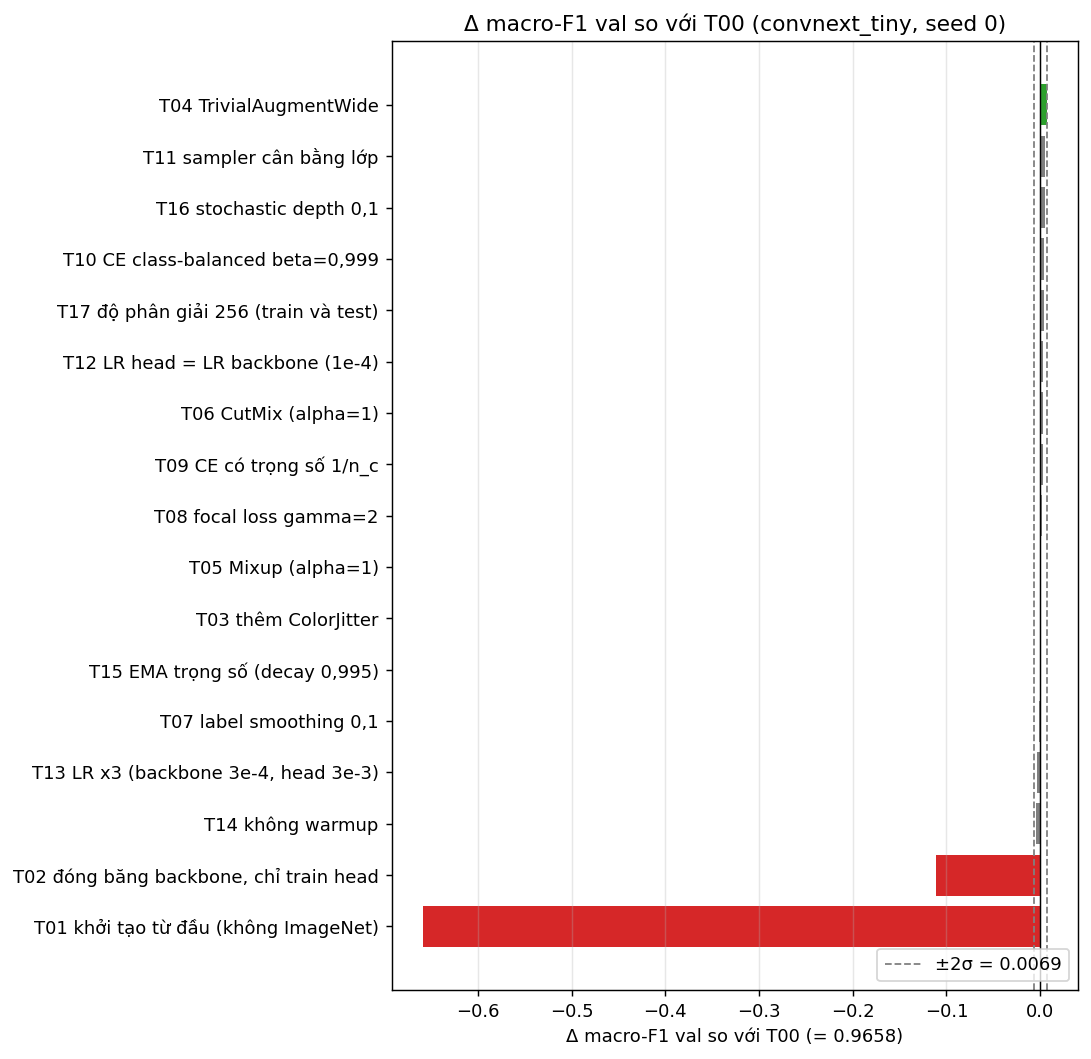

In [18]:
ABL = [  # (exp_id, trục, khác T00 ở điểm nào, mota, thay đổi Config)
    ("T01", "A", "khởi tạo từ đầu (không ImageNet)", "scratch", dict(init="scratch")),
    ("T02", "A", "đóng băng backbone, chỉ train head", "frozen", dict(init="frozen")),
    ("T03", "B", "thêm ColorJitter", "color", dict(aug="color")),
    ("T04", "B", "TrivialAugmentWide", "trivial", dict(aug="trivial")),
    ("T05", "B", "Mixup (alpha=1)", "mixup", dict(mix="mixup")),
    ("T06", "B", "CutMix (alpha=1)", "cutmix", dict(mix="cutmix")),
    ("T07", "C", "label smoothing 0,1", "ls0.1", dict(loss="ls", label_smoothing=0.1)),
    ("T08", "C", "focal loss gamma=2", "focal", dict(loss="focal", focal_gamma=2.0)),
    ("T09", "C", "CE có trọng số 1/n_c", "ce_weighted", dict(loss="ce_weighted", class_weight_beta=0.0)),
    ("T10", "C", "CE class-balanced beta=0,999", "cb0.999", dict(loss="ce_weighted", class_weight_beta=0.999)),
    ("T11", "D", "sampler cân bằng lớp", "balanced", dict(sampler="balanced")),
    ("T12", "E", "LR head = LR backbone (1e-4)", "lr_same", dict(lr_head=1e-4)),
    ("T13", "E", "LR x3 (backbone 3e-4, head 3e-3)", "lr_x3", dict(lr_backbone=3e-4, lr_head=3e-3)),
    ("T14", "E", "không warmup", "no_warmup", dict(warmup_epochs=0.0)),
    ("T15", "F", "EMA trọng số (decay 0,995)", "ema", dict(ema_decay=0.995)),
    ("T16", "F", "stochastic depth 0,1", "droppath", dict(drop_path_rate=0.1)),
    ("T17", "G", "độ phân giải 256 (train và test)", "res256", dict(img_size=256)),
]
LITE_SET = {"T02", "T03", "T06", "T07", "T08", "T11", "T15"}       # LITE: vẫn >= 3 trục, mỗi trục >= 2 giá trị (cùng T00)
ABL_RUN = [a for a in ABL if (not LITE or a[0] in LITE_SET)]
T, SKIPPED = {}, {}
for eid, axis, desc, mota, kw in ABL_RUN:
    if kw.get("img_size") == 256 and not mdl.supports_variable_res(MAIN):
        SKIPPED[eid] = f"bỏ qua: {MAIN} có embedding vị trí/cửa sổ cố định theo 224"
        print(eid, SKIPPED[eid]); continue
    T[eid] = tr.run(mk(eid, backbone=MAIN, mota=mota, **kw))

def train_row(eid, axis, desc, s):
    d = s["val_f1"] - T00_REF
    return {"exp_id": eid, "backbone": s["backbone"], "trục": axis, "khác T00 ở điểm nào": desc, "seed": s["seed"],
            "macro-F1 val": s["val_f1"], "top-1 val": s["val_top1"], "Δ so với T00": d,
            "vượt nhiễu (|Δ| > ngưỡng)?": "Có" if abs(d) > THR else "Không (không phân biệt được)",
            "recall Chinee Apple": s["val_recall"][0], "recall Snake Weed": s["val_recall"][7], "F1 thấp nhất theo lớp": min(s["val_f1_per_class"]),
            "ghi chú": ""}
TR_ROWS = [train_row("T00", "-", f"công thức nền (seed {r['seed']})", r) for r in T00_RUNS]
TR_ROWS += [train_row(eid, axis, desc, T[eid]) for eid, axis, desc, mota, kw in ABL_RUN if eid in T]
TRN = pd.DataFrame(TR_ROWS)
display(TRN.round(4))
abl = pd.DataFrame([{"label": f"{r['exp_id']} {r['khác T00 ở điểm nào']}", "delta": r["Δ so với T00"]} for r in TR_ROWS if r["exp_id"] != "T00"])
rt.plot_ablation_bars(abl, T00_REF, THR, FIG / "ablation_delta_f1.png", f"Δ macro-F1 val so với T00 ({MAIN}, seed 0)")
display(IPImage(str(FIG / "ablation_delta_f1.png")))

In [19]:
# ---- kết hợp các yếu tố thắng rõ rệt (tham lam theo từng trục) -> T20; kiểm tra cộng dồn hay triệt tiêu
winners = {}                          # trục -> (exp_id, Δ, thay đổi)
for eid, axis, desc, mota, kw in ABL_RUN:
    if eid not in T or axis in ("A", "G"):      # A: không kết hợp được; G: đổi độ phân giải sẽ đổi giao thức suy luận/độ trễ -> chỉ khảo sát
        continue
    d = T[eid]["val_f1"] - T00_REF
    if d > THR and (axis not in winners or d > winners[axis][1]):
        winners[axis] = (eid, d, kw)
print("yếu tố thắng rõ (Δ > ngưỡng) theo trục:", {a: (w[0], round(w[1], 4)) for a, w in winners.items()} or "không có")
COMBO_KW = {}
for a, (eid, d, kw) in winners.items():
    COMBO_KW.update(kw)
if winners:
    T["T20"] = tr.run(mk("T20", backbone=MAIN, mota="combo", **COMBO_KW))
    d20 = T["T20"]["val_f1"] - T00_REF; add = sum(w[1] for w in winners.values())
    print(f"T20 (kết hợp {[w[0] for w in winners.values()]}): Δ = {d20:+.4f}; tổng Δ riêng lẻ = {add:+.4f} -> "
          + ("CỘNG DỒN gần đủ" if d20 >= 0.8 * add else "TRIỆT TIÊU một phần" if d20 > 0 else "TRIỆT TIÊU hoàn toàn / có hại"))
    TR_ROWS.append(train_row("T20", "kết hợp", "kết hợp " + ", ".join(w[0] for w in winners.values()), T["T20"]))
    TRN = pd.DataFrame(TR_ROWS)
else:
    print("không có yếu tố nào vượt ngưỡng nhiễu -> không chạy T20; công thức tốt nhất = T00")

# ---- chốt công thức huấn luyện tốt nhất CHỈ bằng val (seed 0)
cands = {"T00": ({}, T00_REF)}
for eid, axis, desc, mota, kw in ABL_RUN:
    if eid in T and axis not in ("A", "G"):     # công thức cuối giữ độ phân giải 224 (I04 khảo sát độ phân giải test riêng)
        cands[eid] = (kw, T[eid]["val_f1"])
if "T20" in T:
    cands["T20"] = (COMBO_KW, T["T20"]["val_f1"])
BEST_ID = max(cands, key=lambda k: cands[k][1])
if cands[BEST_ID][1] - T00_REF <= 0:
    BEST_ID = "T00"
BEST_KW = dict(cands[BEST_ID][0])
BEST_DESC = "công thức nền" if BEST_ID == "T00" else (BEST_ID + ": " + ", ".join(f"{k}={v}" for k, v in BEST_KW.items()))
print(f"CÔNG THỨC TỐT NHẤT (val, seed 0): {BEST_ID} -> macro-F1 val {cands[BEST_ID][1]:.4f} (T00 {T00_REF:.4f}); {BEST_DESC}")

yếu tố thắng rõ (Δ > ngưỡng) theo trục: {'B': ('T04', 0.0074)}


/kaggle/working/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602559_nguyen_thanh_hoa/code/train.py:211: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[T20 s0] ep  1/12 train 0.7986 val 0.4371 F1 0.7975 top1 0.8492 (52s)
[T20 s0] ep  2/12 train 0.3521 val 0.1919 F1 0.9188 top1 0.9394 (50s)
[T20 s0] ep  3/12 train 0.2613 val 0.1484 F1 0.9400 top1 0.9543 (51s)
[T20 s0] ep  4/12 train 0.1959 val 0.1491 F1 0.9371 top1 0.9506 (51s)
[T20 s0] ep  5/12 train 0.1651 val 0.1331 F1 0.9562 top1 0.9649 (50s)
[T20 s0] ep  6/12 train 0.1353 val 0.1305 F1 0.9485 top1 0.9614 (50s)
[T20 s0] ep  7/12 train 0.1031 val 0.1030 F1 0.9646 top1 0.9717 (50s)
[T20 s0] ep  8/12 train 0.0731 val 0.0977 F1 0.9647 top1 0.9723 (50s)
[T20 s0] ep  9/12 train 0.0600 val 0.1158 F1 0.9587 top1 0.9663 (50s)
[T20 s0] ep 10/12 train 0.0491 val 0.0872 F1 0.9679 top1 0.9751 (50s)
[T20 s0] ep 11/12 train 0.0390 val 0.0827 F1 0.9718 top1 0.9783 (50s)
[T20 s0] ep 12/12 train 0.0350 val 0.0814 F1 0.9732 top1 0.9791 (50s)
[T20 s0] xong: best epoch 12, val macro-F1 0.9732, top-1 0.9791, 50s/epoch
T20 (kết hợp ['T04']): Δ = +0.0074; tổng Δ riêng lẻ = +0.0074 -> CỘNG DỒN gần đủ
CÔNG

**Đối chiếu Bước 2 — nhận xét theo trục** (nhiễu: σ = 0,0035 từ 3 seed `T00`, ngưỡng 0,0069; các Δ dưới đây tính so với `T00` seed 0 = 0,9658; mỗi thí nghiệm chỉ 1 seed). **A. Khởi tạo (khớp dự đoán):** huấn luyện từ đầu (`T01`) macro-F1 0,307 (−0,659) và đóng băng backbone (`T02`) 0,855 (−0,111): với 10,5k ảnh và 12 epoch, từ đầu hầu như không học được (train loss cuối 1,18 ⇒ underfit nặng, LR không được chỉnh lại cho trường hợp này) còn đặc trưng ImageNet đóng băng đã khá nhưng tinh chỉnh toàn bộ còn thêm ~0,11. **B. Augmentation:** chỉ TrivialAugment (`T04`) vượt ngưỡng (+0,0074); ColorJitter (+0,0008), Mixup (+0,0014) và CutMix (+0,0026) không phân biệt được với nhiễu. Dự đoán 'Mixup/CutMix có thể hại' không xảy ra nhưng cũng không giúp. Cơ chế gợi ý bởi số liệu: baseline hơi quá khớp (train loss 0,011 so với val loss 0,107), TrivialAugment làm train loss tăng lên 0,035 và val loss giảm xuống 0,081, tức chính quy hoá thật sự; tuy vậy Δ = 0,0074 chỉ nhỉnh hơn ngưỡng 0,0069 một chút, và `T00` seed 2 đã đạt 0,9726 (gần bằng 0,9732 của `T04`); nếu coi hiệu của hai run đơn lẻ có std √2·σ thì ngưỡng là 0,0099 và `T04` không vượt; `T04` còn là giá trị lớn nhất trong 17 so sánh nên có thể là 'may mắn' (winner's curse). Kết luận về `T04` vì thế chỉ mang tính gợi ý. **C. Loss:** label smoothing (−0,0014), focal (+0,0025), CE trọng số 1/n_c (+0,0026), class-balanced (+0,0044) đều trong nhiễu. Đúng hướng dự đoán, loss/sampler có trọng số tăng recall trung bình 8 loài (0,9605 → 0,9694 với `T09`, 0,9735 với sampler cân bằng `T11`) và giảm nhẹ recall `Negative` (0,9841 → 0,9813 và 0,9808); nhưng mỗi lớp loài chỉ có 225 ảnh val (1 ảnh = 0,44 điểm recall) nên các thay đổi này nằm trong nhiễu lấy mẫu. **D. Sampler cân bằng:** +0,0053 (không phân biệt được). **E. LR:** LR head = LR backbone (+0,0035), LR ×3 (−0,0034), bỏ warmup (−0,0048) đều trong nhiễu: ConvNeXt-T tinh chỉnh khá bền với LR trong khoảng ×3 (ít nhạy hơn dự đoán). **F. Chính quy hoá:** EMA (+0,0005) và stochastic depth 0,1 (+0,0049) không phân biệt được. Đường cong cho thấy EMA vượt xa trọng số thô giữa chừng (epoch 5: F1 0,966 so với 0,940) nhưng đến epoch 12 hai bên bằng nhau (0,964), vì lịch cosine về 0 đã tự làm mượt cuối quá trình. **G. Độ phân giải 256:** +0,0038 (không phân biệt được) với chi phí huấn luyện 68 so với 50 s/epoch (+35%). **Kết hợp:** chỉ có một yếu tố vượt ngưỡng nên `T20` trùng cấu hình `T04` (kết quả y hệt 0,9732): *chưa thử được kết hợp thật*, nên chưa kết luận được cộng dồn hay triệt tiêu. Năm yếu tố có Δ dương nhưng dưới ngưỡng (`T10`, `T11`, `T12`, `T16`, `T17`: +0,0035…+0,0053) chưa được kết hợp; đây là hạn chế của cách chọn tham lam theo ngưỡng. **Tóm lại:** với ConvNeXt-T, huấn luyện từ đầu/đóng băng làm hại rất rõ; còn lại công thức huấn luyện đóng góp ≲ 0,007 macro-F1, nhỏ hơn nhiều so với lựa chọn backbone (chênh tới 0,28).

## Bước 3 — Phương pháp suy luận (trên VAL, không huấn luyện lại) và độ trễ
Mô hình: checkpoint tốt nhất của công thức chốt ở Bước 2 (seed 0). Mọi chỉ số ở đây là **val**; nhiệt độ T khớp trên val. Độ trễ **không tính tiền xử lý** (chỉ forward trên tensor đã ở thiết bị), batch 1 và batch 32 (thông lượng),
có warmup ≥ 10, `cuda.synchronize` trước/sau, ≥ 50 lần đo, báo cáo p50/p95/p99; TTA K view chạy tuần tự K lượt.

| Mã | Phương pháp |
|---|---|
| I00 | 1 view (center-crop 224) — mốc |
| I01 / I03a | TTA lật ngang K=2: gộp **xác suất** / gộp **logit** |
| I02a / I03b | 5-crop (4 góc + giữa) K=5: xác suất / logit |
| I02b / I03c | 10-crop (5-crop + lật) K=10: xác suất / logit |
| I04 | dò độ phân giải test: crop 224, resize 224, ảnh nguyên 256, resize 288, resize 320 (chỉ CNN) |
| I05 | ensemble: 3 seed `T00` · 2 backbone tốt nhất |
| I06 | trọng số EMA so với trọng số thô (cùng run `T15`) |
| I07 | temperature scaling (T khớp trên val) + ECE trước/sau |
| I08 | AMP, FP16, gộp BN (FP32 / FP16) |

**Dự đoán trước:** TTA lật tăng macro-F1 rất ít (< 0,005) với K=2× độ trễ; 5-/10-crop tăng thêm chút nhưng tốn 5–10× và có thể đổi đúng thành sai; gộp logit ≈ gộp xác suất (chênh dưới nhiễu);
độ phân giải test cao hơn lúc train (288) có thể tăng nhẹ theo FixRes vì RandomResizedCrop làm vật thể to hơn lúc train; ensemble 3 seed tăng ~0,5–1 điểm với 3× độ trễ; temperature scaling giảm ECE (mạng quá tự tin) mà accuracy/F1 không đổi;
FP16 và gộp BN không đổi F1 (sai số ~1e-3 logit) và giảm độ trễ; ở batch 1 AMP có thể không nhanh hơn FP32.

In [20]:
BEST_CFG = mk(BEST_ID, backbone=MAIN, seed=0, **BEST_KW)
model_b, nz_b = inf.load_run_model(BEST_CFG, device)
VAL = ds.get_evalset("val", val_df, store, device, MAXEV)
INF = []                                                      # sheet Inference
Lv = lambda view, m=None, **kw: inf.predict_logits(m or model_b, VAL.X, device, nz_b, view, **kw)
def mrow(probs):
    return compute_metrics(VAL.y, probs.argmax(1), probs)

def meas(model, label, res=224, dtype="fp32", K=1, fused=False):
    # độ trễ batch 1 (p50/p95/p99) và thông lượng batch 32 của một cấu hình suy luận
    if K == 1:
        r1 = lat(model, label + " (batch 1)", 1, res, dtype, fused)
    else:
        r1 = bm.tta_latency(model, K, 1, res, dtype, DEV, warmup=WARM, iters=ITERS, label=label + f" TTA K={K} (batch 1)"); r1["bn_fused"] = fused; LAT.append(r1)
    r32 = lat(model, label + " (batch 32)", 32, res, dtype, fused)
    return {"p50": r1["p50"], "p95": r1["p95"], "p99": r1["p99"], "thr": 32 / (K * r32["p50"] / 1000.0)}

def add_inf(eid, name, ckpt, K, probs, L, note="", ref=None):
    m = mrow(probs)
    row = {"exp_id": eid, "phương pháp": name, "mô hình/checkpoint": ckpt, "K": K, "macro-F1 val": m["macro_f1"], "top-1 val": m["top1"],
           "ECE val": m["ece"], "NLL val": m["nll"], "độ trễ p50 (ms)": L["p50"], "độ trễ p95 (ms)": L["p95"], "độ trễ p99 (ms)": L["p99"],
           "thông lượng (ảnh/s)": L["thr"], "chi phí tương đối so với I00": L["p50"] / (ref or L["p50"]), "ghi chú": note}
    INF.append(row)
    return row

CK = f"{BEST_ID}/seed0 ({MAIN})"
# I00: 1 view
L_c = Lv(inf.view_center(224)); P0 = inf.softmax_np(L_c)
lat00 = meas(model_b, "I00"); P50_00 = lat00["p50"]
add_inf("I00", "1 view (center-crop 224), mốc", CK, 1, P0, lat00, ref=P50_00)
# I01, I02, I03: TTA, gộp xác suất / logit
TTA = {}
for kind, K, idp, idl in (("hflip", 2, "I01", "I03a"), ("fivecrop", 5, "I02a", "I03b"), ("tencrop", 10, "I02b", "I03c")):
    views = inf.make_views(kind, 224)
    Ls = [Lv(v) for _, v in views]
    TTA[kind] = Ls
    lt = meas(model_b, idp, K=K)
    add_inf(idp, f"TTA {kind} K={K}, gộp xác suất", CK, K, inf.aggregate_views(Ls, "prob"), lt, ref=P50_00)
    add_inf(idl, f"TTA {kind} K={K}, gộp logit", CK, K, inf.aggregate_views(Ls, "logit"), lt, ref=P50_00)
display(pd.DataFrame(INF).round(4))

,exp_id,phương pháp,mô hình/checkpoint,K,macro-F1 val,top-1 val,ECE val,NLL val,độ trễ p50 (ms),độ trễ p95 (ms),độ trễ p99 (ms),thông lượng (ảnh/s),chi phí tương đối so với I00,ghi chú
0,I00,"1 view (center-crop 224), mốc",T04/seed0 (convnext_tiny),1,0.9732,0.9791,0.0090,0.0813,5.8135,5.9201,6.0791,209.9102,1.0000,
1,I01,"TTA hflip K=2, gộp xác suất",T04/seed0 (convnext_tiny),2,0.9761,0.9820,0.0077,0.0750,11.5102,11.7206,11.7707,106.9327,1.9799,
2,I03a,"TTA hflip K=2, gộp logit",T04/seed0 (convnext_tiny),2,0.9761,0.9820,0.0065,0.0747,11.5102,11.7206,11.7707,106.9327,1.9799,
3,I02a,"TTA fivecrop K=5, gộp xác suất",T04/seed0 (convnext_tiny),5,0.9756,0.9809,0.0072,0.0735,28.8926,30.2343,30.6152,42.5177,4.9699,
4,I03b,"TTA fivecrop K=5, gộp logit",T04/seed0 (convnext_tiny),5,0.9764,0.9814,0.0080,0.0742,28.8926,30.2343,30.6152,42.5177,4.9699,
5,I02b,"TTA tencrop K=10, gộp xác suất",T04/seed0 (convnext_tiny),10,0.9788,0.9837,0.0060,0.0697,57.5587,58.6065,74.5582,21.1831,9.9008,
6,I03c,"TTA tencrop K=10, gộp logit",T04/seed0 (convnext_tiny),10,0.9788,0.9837,0.0068,0.0696,57.5587,58.6065,74.5582,21.1831,9.9008,


In [21]:
# ---- I04: dò độ phân giải kiểm tra (chỉ CNN; ViT/Swin có kích thước cố định)
if mdl.supports_variable_res(MAIN):
    res_model, res_nz, res_name, res_ck = model_b, nz_b, MAIN, CK
else:
    cnn = BB[BB["backbone"].map(mdl.supports_variable_res)].sort_values("macro-F1 val", ascending=False).iloc[0]
    res_name, res_ck = cnn["backbone"], f"{cnn['exp_id']}/seed0 ({cnn['backbone']}, công thức T00)"
    res_model, res_nz = inf.load_run_model(mk(cnn["exp_id"], backbone=res_name, seed=0), device)
    print(f"{MAIN} không đổi độ phân giải được; I04 chạy trên {res_name} (CNN tốt nhất ở Bước 1)")
res_views = [("crop224", inf.view_center(224), 224), ("resize224", inf.view_resize(224), 224), ("full256", inf.view_identity, 256),
             ("resize288", inf.view_resize(288), 288), ("resize320", inf.view_resize(320), 320)]
RES_ROWS = []
ref_res = None
for k, (nm, v, r) in enumerate(res_views):
    Lr_ = inf.predict_logits(res_model, VAL.X, device, res_nz, v)
    lr_ = meas(res_model, f"I04{'abcde'[k]} {nm}", res=r)
    ref_res = ref_res or lr_["p50"]
    add_inf(f"I04{'abcde'[k]}", f"độ phân giải test: {nm}", res_ck, 1, inf.softmax_np(Lr_), lr_, note=f"đầu vào {r}x{r}", ref=ref_res)
# ---- I05: ensemble (3 seed T00; 2 backbone tốt nhất). Độ trễ = tổng độ trễ các thành viên (chạy tuần tự)
def val_logits_of(eid, seed):
    return np.load(tr.run_dir(mk(eid, seed=seed)) / "val_logits.npy")
Lseed = [val_logits_of("T00", s) for s in (0, 1, 2)]
add_inf("I05a", "ensemble 3 seed T00 (trung bình xác suất)", f"T00/seed0-2 ({MAIN})", 3,
        inf.ensemble_probs([inf.softmax_np(l) for l in Lseed]),
        {k: 3 * lat00[k] for k in ("p50", "p95", "p99")} | {"thr": lat00["thr"] / 3},
        note=f"thành viên: macro-F1 {[round(mrow(inf.softmax_np(l))['macro_f1'], 4) for l in Lseed]}", ref=P50_00)
top2 = BBs.head(2)
Lm = [val_logits_of(r["exp_id"], 0) for _, r in top2.iterrows()]
p50s = [float(r["độ trễ batch-1 p50 (ms)"]) for _, r in top2.iterrows()]
p95s = [float(r["độ trễ batch-1 p95 (ms)"]) for _, r in top2.iterrows()]
add_inf("I05b", "ensemble 2 backbone tốt nhất (B-run, T00)", "+".join(top2["exp_id"]), 2,
        inf.ensemble_probs([inf.softmax_np(l) for l in Lm]),
        {"p50": sum(p50s), "p95": sum(p95s), "p99": sum(p95s), "thr": 1000.0 / sum(p50s)},
        note="p99 xấp xỉ bằng tổng p95; thành viên: " + str([round(mrow(inf.softmax_np(l))['macro_f1'], 4) for l in Lm]), ref=P50_00)
# ---- I06: EMA vs trọng số thô (cùng một run T15)
if "T15" in T:
    s15 = T["T15"]
    add_inf("I06", "trọng số EMA (decay 0,995) so với trọng số thô", f"T15/seed0 ({MAIN})", 1, inf.softmax_np(np.load(tr.run_dir(mk("T15", seed=0)) / "val_logits.npy")),
            lat00, note=f"EMA (AMP) {s15['val_f1_amp_selection']:.4f} vs thô (AMP) {s15['val_f1_raw_best']:.4f} tại epoch tốt nhất; không tốn thêm khi suy luận", ref=P50_00)
# ---- I07: temperature scaling + ECE
T_TS = inf.fit_temperature(L_c, VAL.y)
P_ts = inf.apply_temperature(L_c, T_TS)
add_inf("I07", f"temperature scaling (T = {T_TS:.3f}, khớp trên val)", CK, 1, P_ts, lat00,
        note=f"ECE val {mrow(P0)['ece']:.4f} -> {mrow(P_ts)['ece']:.4f}; NLL {mrow(P0)['nll']:.4f} -> {mrow(P_ts)['nll']:.4f} (khớp và đo cùng trên val nên là trong mẫu)", ref=P50_00)

{'exp_id': 'I07',
 'phương pháp': 'temperature scaling (T = 1.377, khớp trên val)',
 'mô hình/checkpoint': 'T04/seed0 (convnext_tiny)',
 'K': 1,
 'macro-F1 val': 0.9731794100604445,
 'top-1 val': 0.9791488146243931,
 'ECE val': 0.004887571116504889,
 'NLL val': 0.07372004517765539,
 'độ trễ p50 (ms)': 5.8135429990215925,
 'độ trễ p95 (ms)': 5.920074747882609,
 'độ trễ p99 (ms)': 6.079088087753921,
 'thông lượng (ảnh/s)': 209.91016110917533,
 'chi phí tương đối so với I00': 1.0,
 'ghi chú': 'ECE val 0.0090 -> 0.0049; NLL 0.0813 -> 0.0737 (khớp và đo cùng trên val nên là trong mẫu)'}

,exp_id,phương pháp,mô hình/checkpoint,K,macro-F1 val,top-1 val,ECE val,NLL val,độ trễ p50 (ms),độ trễ p95 (ms),độ trễ p99 (ms),thông lượng (ảnh/s),chi phí tương đối so với I00,ghi chú
0,I00,"1 view (center-crop 224), mốc",T04/seed0 (convnext_tiny),1,0.9732,0.9791,0.0090,0.0813,5.8135,5.9201,6.0791,209.9102,1.0000,
1,I01,"TTA hflip K=2, gộp xác suất",T04/seed0 (convnext_tiny),2,0.9761,0.9820,0.0077,0.0750,11.5102,11.7206,11.7707,106.9327,1.9799,
2,I03a,"TTA hflip K=2, gộp logit",T04/seed0 (convnext_tiny),2,0.9761,0.9820,0.0065,0.0747,11.5102,11.7206,11.7707,106.9327,1.9799,
3,I02a,"TTA fivecrop K=5, gộp xác suất",T04/seed0 (convnext_tiny),5,0.9756,0.9809,0.0072,0.0735,28.8926,30.2343,30.6152,42.5177,4.9699,
4,I03b,"TTA fivecrop K=5, gộp logit",T04/seed0 (convnext_tiny),5,0.9764,0.9814,0.0080,0.0742,28.8926,30.2343,30.6152,42.5177,4.9699,
5,I02b,"TTA tencrop K=10, gộp xác suất",T04/seed0 (convnext_tiny),10,0.9788,0.9837,0.0060,0.0697,57.5587,58.6065,74.5582,21.1831,9.9008,
6,I03c,"TTA tencrop K=10, gộp logit",T04/seed0 (convnext_tiny),10,0.9788,0.9837,0.0068,0.0696,57.5587,58.6065,74.5582,21.1831,9.9008,
7,I04a,độ phân giải test: crop224,T04/seed0 (convnext_tiny),1,0.9732,0.9791,0.0090,0.0813,5.8127,6.2622,7.0401,212.5061,1.0000,đầu vào 224x224
8,I04b,độ phân giải test: resize224,T04/seed0 (convnext_tiny),1,0.9743,0.9797,0.0092,0.0773,5.8160,6.2043,6.3499,212.4367,1.0006,đầu vào 224x224
9,I04c,độ phân giải test: full256,T04/seed0 (convnext_tiny),1,0.9751,0.9806,0.0072,0.0735,6.5963,6.7360,6.8992,164.8470,1.1348,đầu vào 256x256


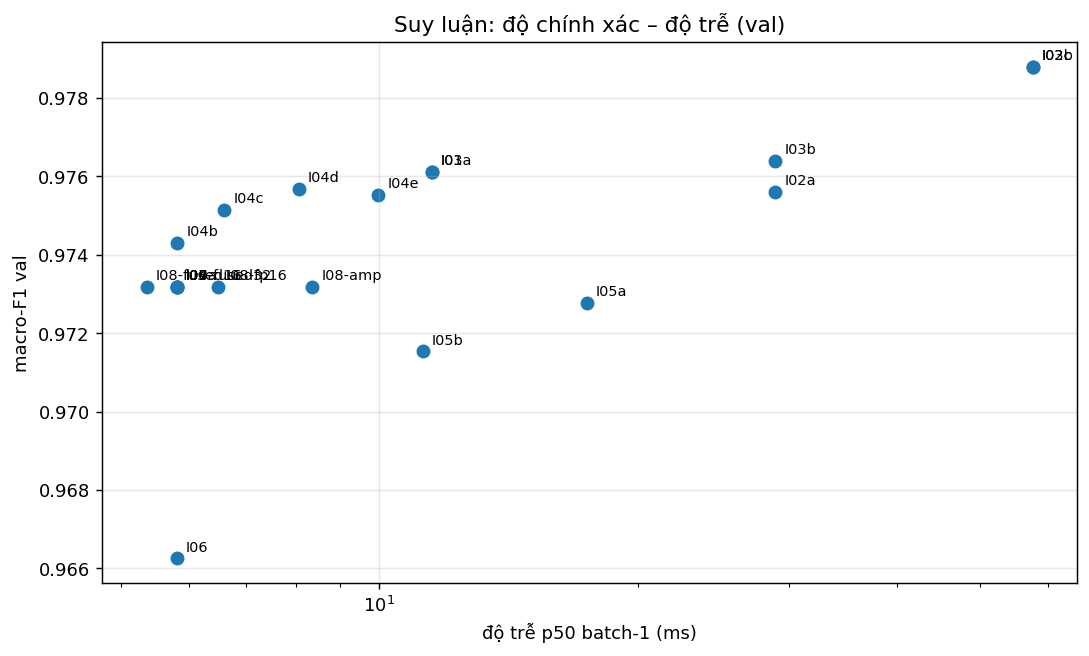

In [22]:
# ---- I08: AMP, FP16, gộp BN; đo F1 trên val và độ trễ
VARIANTS = ["fp32", "fused32"] + (["amp", "fp16", "fused16"] if device.type == "cuda" else [])
PREC_RES = {}
for prec in VARIANTS:
    m_, half, amp, cl = inf._prepare(model_b, prec)
    Lp = inf.predict_logits(m_, VAL.X, device, nz_b, inf.view_center(224), half=half, amp=amp, channels_last=cl)
    fused = prec.startswith("fused")
    n_f = getattr(m_, "n_fused", 0) if fused else 0
    dtype = {"fp32": "fp32", "amp": "amp", "fp16": "fp16", "fused32": "fp32", "fused16": "fp16"}[prec]
    lp = meas(m_, f"I08 {prec}", dtype=dtype, fused=fused)
    PREC_RES[prec] = (mrow(inf.softmax_np(Lp))["macro_f1"], lp)
    if prec != "fp32":
        add_inf(f"I08-{prec}", {"amp": "AMP (autocast FP16)", "fp16": "FP16 (model.half())", "fused32": "gộp BN vào conv, FP32", "fused16": "gộp BN + FP16"}[prec],
                CK, 1, inf.softmax_np(Lp), lp, note=(f"gộp {n_f} cặp Conv+BN" if fused and n_f else "không có BN để gộp (LayerNorm): không áp dụng" if fused else ""), ref=P50_00)
    del m_
INFR = pd.DataFrame(INF)
display(INFR.round(4))
rt.plot_tradeoff(INFR, "độ trễ p50 (ms)", "macro-F1 val", "exp_id", FIG / "inference_tradeoff.png", "độ trễ p50 batch-1 (ms)", "macro-F1 val",
                 "Suy luận: độ chính xác – độ trễ (val)", logx=True)
display(IPImage(str(FIG / "inference_tradeoff.png")))

In [23]:
# ---- chốt cấu hình suy luận cuối (CHỈ bằng val) và cấu hình thời gian thực
SPECS = {}
def f1_of(Ls_, space):
    return mrow(inf.aggregate_views(Ls_, space))["macro_f1"]
SPECS[("identity", "prob")] = (1, mrow(P0)["macro_f1"])
for kind, K in (("hflip", 2), ("fivecrop", 5), ("tencrop", 10)):
    for space in ("prob", "logit"):
        SPECS[(kind, space)] = (K, f1_of(TTA[kind], space))
base_f1 = SPECS[("identity", "prob")][1]
best_key = max(SPECS, key=lambda k: (round(SPECS[k][1], 4), -SPECS[k][0]))       # F1 cao nhất; hòa (4 chữ số) -> K nhỏ hơn
if SPECS[best_key][1] - base_f1 < 0.001:                                         # cải thiện < 0.1 điểm: không đáng K lần chi phí
    best_key = ("identity", "prob")
FINAL_KIND, FINAL_SPACE = best_key
FINAL_K = SPECS[best_key][0]
print("macro-F1 val theo cách suy luận:", {f"{k[0]}/{k[1]}": round(v[1], 4) for k, v in SPECS.items()})
print(f"SUY LUẬN CUỐI (chọn bằng val): {FINAL_KIND}, gộp {FINAL_SPACE}, K = {FINAL_K}; kèm temperature scaling (T khớp trên val của từng seed)")

# cấu hình thời gian thực: số học nhanh nhất giữ macro-F1 val trong 0.002 so với FP32, 1 view, TS
f32 = PREC_RES["fp32"][0]
ok_prec = {p: v for p, v in PREC_RES.items() if v[0] >= f32 - 0.002}
RTC_PREC = min(ok_prec, key=lambda p: ok_prec[p][1]["p95"])
RTC_P95 = PREC_RES[RTC_PREC][1]["p95"]; RTC_P50 = PREC_RES[RTC_PREC][1]["p50"]
print(f"CẤU HÌNH THỜI GIAN THỰC: {MAIN}, 1 view, số học {RTC_PREC}, temperature scaling -> p50 {RTC_P50:.2f} ms, p95 {RTC_P95:.2f} ms (ngân sách 100 ms): "
      + ("ĐẠT" if RTC_P95 <= 100 else "KHÔNG ĐẠT"))
del res_model

macro-F1 val theo cách suy luận: {'identity/prob': 0.9732, 'hflip/prob': 0.9761, 'hflip/logit': 0.9761, 'fivecrop/prob': 0.9756, 'fivecrop/logit': 0.9764, 'tencrop/prob': 0.9788, 'tencrop/logit': 0.9788}
SUY LUẬN CUỐI (chọn bằng val): tencrop, gộp prob, K = 10; kèm temperature scaling (T khớp trên val của từng seed)
CẤU HÌNH THỜI GIAN THỰC: convnext_tiny, 1 view, số học fused16, temperature scaling -> p50 5.36 ms, p95 5.79 ms (ngân sách 100 ms): ĐẠT


**Đối chiếu Bước 3 — nhận xét** (trên val, mô hình `T04` seed 0, ConvNeXt-T, GPU T4; mốc I00 macro-F1 0,9732, 5,8 ms p50). **TTA:** lật ngang (K=2) 0,9761 (+0,0029, 2,0× độ trễ), 5-crop (K=5) 0,9756/0,9764 (+0,0024/+0,0032; 5,0×), 10-crop (K=10) 0,9788 (+0,0056; 9,9×). F1 tăng nhẹ theo K nhưng mỗi mức đều nhỏ hơn hoặc gần bằng nhiễu (σ ≈ 0,0035); NLL cải thiện rõ hơn (0,0813 → 0,0697, −14%). Trên test (post-hoc, chỉ để phân tích, không dùng chọn cấu hình), 10-crop đổi nhãn so với crop giữa ở 75 lượt dự đoán (3 seed): 46 từ sai thành đúng, 20 từ đúng thành sai, nên TTA có sửa nhiều hơn làm hỏng nhưng cũng làm hỏng ca đã đúng (đúng như cảnh báo ở GUIDE mục 8). **Gộp xác suất vs logit (I03):** F1 chênh ≤ 0,0008 và ECE chênh ≤ 0,0012, tức không phân biệt được. **Độ phân giải test (I04):** crop 224 0,9732 → resize 224 0,9743 → ảnh nguyên 256 0,9751 → 288 0,9757 → 320 0,9755; cao nhất ở 288 (+0,0025, 1,4× độ trễ, NLL 0,0813 → 0,0686). Xu hướng phù hợp FixRes (RandomResizedCrop làm vật thể to hơn lúc train nên test ở độ phân giải cao hơn bù lại), nhưng mức tăng nhỏ hơn nhiễu nên chưa khẳng định. **Ensemble (I05):** 3 seed `T00` 0,9728 so với trung bình thành viên 0,9688 (+0,0040) và so với thành viên tốt nhất 0,9726 (+0,0002) với 3× độ trễ; ensemble ConvNeXt-T + DeiT-S 0,9715 so với 0,9658 của ConvNeXt-T (+0,0057) với 1,9× độ trễ: lợi ích nhỏ, hợp ngoại tuyến. **EMA (I06):** miễn phí lúc suy luận; so với trọng số thô cùng run, EMA vượt rõ ở giữa quá trình (epoch 5: 0,966 so với 0,940) nhưng ở cuối bằng nhau, nên với 12 epoch + cosine EMA không đem lại lợi ích thêm. **Temperature scaling (I07):** T = 1,377 > 1 (mô hình hơi quá tự tin); ECE val 0,0090 → 0,0049, NLL 0,0813 → 0,0737, F1/accuracy không đổi (khớp và đo cùng trên val nên là trong mẫu). Trên test, ECE F01: 0,0068 ± 0,0008 → 0,0056 ± 0,0004: lợi ích tuyệt đối nhỏ vì ECE gốc đã dưới 1%. **FP16/AMP/gộp BN (I08):** F1, top-1 và ECE không đổi (0,9732/0,9791/0,0090). Gộp BN không áp dụng được với ConvNeXt-T (dùng LayerNorm). Ở batch 1, AMP *chậm hơn* FP32 (8,4 so với 5,8 ms, +44%, do chi phí chuyển kiểu) và FP16 thuần 6,5 ms; hai dòng `FP16` (6,5 ms) và `gộp BN + FP16` (5,4 ms) thực chất là cùng một phép tính (không có BN để gộp) nhưng lệch 1,1 ms, tức sai khác dưới ~1 ms (≈ 20% ở thang 5–6 ms) là nhiễu đo, không nên diễn giải. Ở batch 32 FP16 cho 729 ảnh/s so với 210 ảnh/s của FP32 (3,5×), tức tensor core chỉ có lợi khi batch lớn. **Ngoại tuyến vs thời gian thực:** TTA và ensemble tốn K× độ trễ, hợp xử lý ngoại tuyến; EMA, temperature scaling và FP16 (khi batch lớn) không tốn thêm. Dù 10-crop (57,6 ms p50, 58,6 ms p95) vẫn dưới ngân sách 100 ms trên T4, đây không phải phần cứng robot (bài báo đo 53–180 ms cho ResNet-50 trên Jetson TX2), nên với robot nên dùng một view + temperature scaling (R01).

## Bước 4 — Chung kết: ≥ 3 seed, test **một lần mỗi checkpoint**
Cấu hình chốt hoàn toàn trên val: **F01** = backbone + công thức huấn luyện tốt nhất (Bước 2) + suy luận cuối (Bước 3: TTA/gộp + temperature scaling), huấn luyện lại từ đầu với seed 0, 1, 2.
**Mốc** = `T00` + `I00` (công thức nền, 1 view), cùng 3 seed. **R01** = cấu hình thời gian thực (1 view, số học nhanh, temperature scaling). Dự đoán test được tạo MỘT lần cho mỗi checkpoint
(`inference.test_views_once`: file cờ `TEST_USED.json` chặn lần quét thứ hai), rồi mọi dự đoán dẫn xuất (đã/ chưa hiệu chuẩn, R01) tính từ cùng logit đó. File dự đoán ghi bằng `eval.save_predictions`.

**Dự đoán trước:** F01 cao hơn mốc ≥ 0,5 điểm macro-F1 test; std giữa seed ~0,2–0,5 điểm; lớp khó nhất vẫn là Chinee apple và Snake weed (nhầm lẫn nhau như bài báo); temperature scaling giảm ECE test; macro-F1 val và test lệch dưới 0,02.

In [24]:
F_SEEDS = (0, 1, 2)
F_CFG = {s: mk("F01", seed=s, backbone=MAIN, mota=f"final_{MAIN}", **BEST_KW) for s in F_SEEDS}
T_CFG = {s: mk("T00", seed=s, backbone=MAIN, mota=f"baseline_{MAIN}") for s in F_SEEDS}
F_RUNS = {s: tr.run(F_CFG[s]) for s in F_SEEDS}
fv = np.array([F_RUNS[s]["val_f1"] for s in F_SEEDS]); tv = np.array([r["val_f1"] for r in T00_RUNS])
print(f"macro-F1 val  F01: {fv.round(4).tolist()} -> {rt.fmt_pm(fv.mean(), fv.std(ddof=1))}")
print(f"macro-F1 val  T00: {tv.round(4).tolist()} -> {rt.fmt_pm(tv.mean(), tv.std(ddof=1))}")
print(f"Δ val (F01 - T00) = {fv.mean() - tv.mean():+.4f}")

/kaggle/working/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602559_nguyen_thanh_hoa/code/train.py:211: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[F01 s0] ep  1/12 train 0.7986 val 0.4371 F1 0.7975 top1 0.8492 (51s)
[F01 s0] ep  2/12 train 0.3521 val 0.1919 F1 0.9188 top1 0.9394 (51s)
[F01 s0] ep  3/12 train 0.2613 val 0.1484 F1 0.9400 top1 0.9543 (51s)
[F01 s0] ep  4/12 train 0.1959 val 0.1491 F1 0.9371 top1 0.9506 (50s)
[F01 s0] ep  5/12 train 0.1651 val 0.1331 F1 0.9562 top1 0.9649 (50s)
[F01 s0] ep  6/12 train 0.1353 val 0.1305 F1 0.9485 top1 0.9614 (50s)
[F01 s0] ep  7/12 train 0.1031 val 0.1030 F1 0.9646 top1 0.9717 (50s)
[F01 s0] ep  8/12 train 0.0731 val 0.0977 F1 0.9647 top1 0.9723 (50s)
[F01 s0] ep  9/12 train 0.0600 val 0.1158 F1 0.9587 top1 0.9663 (50s)
[F01 s0] ep 10/12 train 0.0491 val 0.0872 F1 0.9679 top1 0.9751 (50s)
[F01 s0] ep 11/12 train 0.0390 val 0.0827 F1 0.9718 top1 0.9783 (50s)
[F01 s0] ep 12/12 train 0.0350 val 0.0814 F1 0.9732 top1 0.9791 (50s)
[F01 s0] xong: best epoch 12, val macro-F1 0.9732, top-1 0.9791, 50s/epoch


/kaggle/working/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602559_nguyen_thanh_hoa/code/train.py:211: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[F01 s1] ep  1/12 train 0.8464 val 0.3287 F1 0.8465 top1 0.8883 (52s)
[F01 s1] ep  2/12 train 0.3536 val 0.2157 F1 0.9103 top1 0.9300 (51s)
[F01 s1] ep  3/12 train 0.2443 val 0.1720 F1 0.9309 top1 0.9452 (50s)
[F01 s1] ep  4/12 train 0.1855 val 0.1404 F1 0.9468 top1 0.9574 (51s)
[F01 s1] ep  5/12 train 0.1666 val 0.1765 F1 0.9210 top1 0.9437 (50s)
[F01 s1] ep  6/12 train 0.1391 val 0.0976 F1 0.9584 top1 0.9669 (50s)
[F01 s1] ep  7/12 train 0.0927 val 0.0953 F1 0.9628 top1 0.9714 (50s)
[F01 s1] ep  8/12 train 0.0764 val 0.1014 F1 0.9616 top1 0.9697 (50s)
[F01 s1] ep  9/12 train 0.0638 val 0.0944 F1 0.9642 top1 0.9720 (50s)
[F01 s1] ep 10/12 train 0.0501 val 0.0829 F1 0.9711 top1 0.9771 (50s)
[F01 s1] ep 11/12 train 0.0369 val 0.0901 F1 0.9655 top1 0.9737 (50s)
[F01 s1] ep 12/12 train 0.0356 val 0.0882 F1 0.9661 top1 0.9743 (50s)
[F01 s1] xong: best epoch 10, val macro-F1 0.9711, top-1 0.9771, 50s/epoch


/kaggle/working/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602559_nguyen_thanh_hoa/code/train.py:211: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[F01 s2] ep  1/12 train 0.8468 val 0.2978 F1 0.8711 top1 0.9046 (51s)
[F01 s2] ep  2/12 train 0.3530 val 0.1882 F1 0.9265 top1 0.9403 (51s)
[F01 s2] ep  3/12 train 0.2362 val 0.1521 F1 0.9382 top1 0.9506 (50s)
[F01 s2] ep  4/12 train 0.1882 val 0.1548 F1 0.9286 top1 0.9472 (50s)
[F01 s2] ep  5/12 train 0.1656 val 0.1252 F1 0.9477 top1 0.9589 (50s)
[F01 s2] ep  6/12 train 0.1410 val 0.0904 F1 0.9605 top1 0.9717 (50s)
[F01 s2] ep  7/12 train 0.0899 val 0.1188 F1 0.9586 top1 0.9663 (50s)
[F01 s2] ep  8/12 train 0.0810 val 0.0925 F1 0.9692 top1 0.9760 (50s)
[F01 s2] ep  9/12 train 0.0606 val 0.0894 F1 0.9695 top1 0.9769 (50s)
[F01 s2] ep 10/12 train 0.0439 val 0.0778 F1 0.9715 top1 0.9791 (50s)
[F01 s2] ep 11/12 train 0.0395 val 0.0756 F1 0.9739 top1 0.9797 (50s)
[F01 s2] ep 12/12 train 0.0361 val 0.0767 F1 0.9724 top1 0.9789 (50s)
[F01 s2] xong: best epoch 11, val macro-F1 0.9739, top-1 0.9797, 50s/epoch
macro-F1 val  F01: [0.9732, 0.9711, 0.9739] -> 0.9727 ± 0.0015
macro-F1 val  T00: [0.

In [25]:
# ---- dự đoán test: MỘT lần cho mỗi checkpoint; tạo file predictions đúng định dạng eval.py
TEST = ds.get_evalset("test", test_df, store, device, MAXEV)
PRED = OUT / "predictions"
fviews = inf.make_views(FINAL_KIND, 224)
TS = {}                                             # nhiệt độ T của từng seed (khớp trên val của chính seed đó)
for s in F_SEEDS:
    cfg = F_CFG[s]
    m, nz = inf.load_run_model(cfg, device)
    Lval = [inf.predict_logits(m, VAL.X, device, nz, v) for _, v in fviews]
    Tt = inf.fit_temperature_views(Lval, VAL.y, FINAL_SPACE); TS[s] = Tt
    Lc = inf.predict_logits(m, VAL.X, device, nz, inf.view_center(224))
    T_rt = inf.fit_temperature(Lc, VAL.y)
    specs = {name: (v, "fp32") for name, v in fviews}
    specs["rt"] = (inf.view_center(224), RTC_PREC)
    out = inf.test_views_once(cfg, m, TEST.X, device, nz, specs)               # <- lần quét test duy nhất của checkpoint này
    Lt = [out[name] for name, _ in fviews]
    save_predictions(PRED / f"F01_seed{s}_val.csv", VAL.names, VAL.y, inf.aggregate_views(Lval, FINAL_SPACE, Tt))
    save_predictions(PRED / f"F01_seed{s}_test.csv", TEST.names, TEST.y, inf.aggregate_views(Lt, FINAL_SPACE, Tt))
    save_predictions(PRED / f"F01_uncal_seed{s}_test.csv", TEST.names, TEST.y, inf.aggregate_views(Lt, FINAL_SPACE, 1.0))
    save_predictions(PRED / f"R01_seed{s}_test.csv", TEST.names, TEST.y, inf.softmax_np(out["rt"], T_rt))
    del m
    # mốc T00 + I00 (1 view, không hiệu chuẩn)
    mT, nzT = inf.load_run_model(T_CFG[s], device)
    outT = inf.test_views_once(T_CFG[s], mT, TEST.X, device, nzT, {"center": (inf.view_center(224), "fp32")})
    save_predictions(PRED / f"T00_seed{s}_test.csv", TEST.names, TEST.y, inf.softmax_np(outT["center"]))
    save_predictions(PRED / f"T00_seed{s}_val.csv", VAL.names, VAL.y, inf.softmax_np(np.load(tr.run_dir(T_CFG[s]) / "val_logits.npy")))
    del mT
print("T theo seed:", {s: round(v, 3) for s, v in TS.items()}, "| file dự đoán:", sorted(p.name for p in PRED.glob("*.csv")))

T theo seed: {0: 1.278, 1: 1.236, 2: 1.293} | file dự đoán: ['F01_seed0_test.csv', 'F01_seed0_val.csv', 'F01_seed1_test.csv', 'F01_seed1_val.csv', 'F01_seed2_test.csv', 'F01_seed2_val.csv', 'F01_uncal_seed0_test.csv', 'F01_uncal_seed1_test.csv', 'F01_uncal_seed2_test.csv', 'R01_seed0_test.csv', 'R01_seed1_test.csv', 'R01_seed2_test.csv', 'T00_seed0_test.csv', 'T00_seed0_val.csv', 'T00_seed1_test.csv', 'T00_seed1_val.csv', 'T00_seed2_test.csv', 'T00_seed2_val.csv']


In [26]:
# ---- tính số liệu bằng ĐÚNG eval.py của giảng viên (score + grade)
TEST_CSV = None if QUICK else str(Path(LABELS_DIR) / "test_subset0.csv")
VAL_CSV = None if QUICK else str(Path(LABELS_DIR) / "val_subset0.csv")
LABELS_CSV = str(Path(LABELS_DIR) / "labels.csv")
EVAL_OUT = OUT / "eval_out"
def eval_cli(*args):
    p = subprocess.run([sys.executable, str(REPO_ROOT / "eval.py"), *args], capture_output=True, text=True, encoding="utf-8",
                       env={**os.environ, "PYTHONIOENCODING": "utf-8", "PYTHONUTF8": "1"})
    print(p.stdout + (p.stderr if p.returncode else ""))
    assert p.returncode == 0, "eval.py báo lỗi định dạng: sửa code ghi file dự đoán, không sửa eval.py"
for tag in ("F01", "T00", "R01"):
    eval_cli("score", "--pred", str(PRED / f"{tag}_seed*_test.csv"), "--labels", LABELS_CSV, "--tag", tag, "--out", str(EVAL_OUT),
             *(["--test-csv", TEST_CSV] if TEST_CSV else []))
gargs = ["grade", "--final", str(PRED / "F01_seed*_test.csv"), "--baseline", str(PRED / "T00_seed*_test.csv"), "--uncal", str(PRED / "F01_uncal_seed*_test.csv"),
         "--final-val", str(PRED / "F01_seed*_val.csv"), "--latency-p95-ms", f"{RTC_P95:.3f}", "--latency-method", "proper", "--labels", LABELS_CSV,
         "--out", str(EVAL_OUT)]
if TEST_CSV:
    gargs += ["--test-csv", TEST_CSV, "--val-csv", VAL_CSV]
eval_cli(*gargs)

### F01 (3 seed: [0, 1, 2]; 3507 ảnh)

| Chỉ số | mean ± std |
|---|---|
| top-1 accuracy | 0.9815 ± 0.0010 |
| macro-F1 | 0.9765 ± 0.0009 |
| balanced accuracy | 0.9767 ± 0.0028 |
| ECE (15 bin) | 0.0056 ± 0.0004 |
| NLL | 0.0614 ± 0.0026 |

| Lớp | Precision | Recall | F1 | Số ảnh |
|---|---|---|---|---|
| Chinee apple | 0.971 ± 0.005 | 0.944 ± 0.014 | 0.957 ± 0.005 | 226 |
| Lantana | 0.980 ± 0.015 | 0.977 ± 0.005 | 0.978 ± 0.010 | 213 |
| Parkinsonia | 0.982 ± 0.007 | 0.989 ± 0.003 | 0.986 ± 0.005 | 207 |
| Parthenium | 0.992 ± 0.008 | 0.976 ± 0.005 | 0.984 ± 0.004 | 205 |
| Prickly acacia | 0.950 ± 0.007 | 0.983 ± 0.003 | 0.966 ± 0.002 | 213 |
| Rubber vine | 0.980 ± 0.013 | 0.987 ± 0.006 | 0.984 ± 0.006 | 202 |
| Siam weed | 0.982 ± 0.008 | 0.989 ± 0.003 | 0.985 ± 0.003 | 215 |
| Snake weed | 0.964 ± 0.012 | 0.959 ± 0.003 | 0.962 ± 0.006 | 204 |
| Negative | 0.988 ± 0.003 | 0.987 ± 0.004 | 0.987 ± 0.001 | 1822 |

Đã lưu kết quả vào /kaggle/working/K4-Track4-Day2-Deeplearning-Adva

In [27]:
# ---- bảng Final / PerClass từ chính các file dự đoán (cùng định nghĩa với eval.py)
GF = ev.load_group(str(PRED / "F01_seed*_test.csv"), TEST_CSV)
GU = ev.load_group(str(PRED / "F01_uncal_seed*_test.csv"), TEST_CSV)
GT = ev.load_group(str(PRED / "T00_seed*_test.csv"), TEST_CSV)
GR = ev.load_group(str(PRED / "R01_seed*_test.csv"), TEST_CSV)
VF = ev.load_group(str(PRED / "F01_seed*_val.csv"), VAL_CSV, ref_what="val")
VT = ev.load_group(str(PRED / "T00_seed*_val.csv"), VAL_CSV, ref_what="val")
CFG_DESC = {"F01": f"{MAIN} + {BEST_DESC} + suy luận {FINAL_KIND}/{FINAL_SPACE} K={FINAL_K} + temperature scaling",
            "T00": f"{MAIN} + công thức nền + 1 view (mốc T00+I00)",
            "R01": f"{MAIN} + {BEST_DESC} + 1 view + {RTC_PREC} + temperature scaling (thời gian thực)"}
def final_rows(tag, G, V):
    rows = []
    for k, (p, m) in enumerate(zip(G.preds, G.metrics)):
        vm = V.metrics[k] if V is not None else None
        rows.append({"exp_id": tag, "cấu hình": CFG_DESC[tag], "seed": p.seed, "macro-F1 val": vm["macro_f1"] if vm else np.nan,
                     "macro-F1 test": m["macro_f1"], "top-1 test": m["top1"], "ECE test": m["ece"], "mean ± std qua seed": ""})
    d = pd.DataFrame(rows)
    agg = {"exp_id": tag, "cấu hình": CFG_DESC[tag] + " (tổng hợp)", "seed": f"mean ± std (n={len(rows)})",
           "macro-F1 val": d["macro-F1 val"].mean(), "macro-F1 test": d["macro-F1 test"].mean(), "top-1 test": d["top-1 test"].mean(), "ECE test": d["ECE test"].mean(),
           "mean ± std qua seed": f"F1 test {rt.fmt_pm(*G.summary['macro_f1'])}; top-1 {rt.fmt_pm(*G.summary['top1'])}; ECE {rt.fmt_pm(*G.summary['ece'])}"}
    return rows + [agg]
FINAL_DF = pd.DataFrame(final_rows("F01", GF, VF) + final_rows("T00", GT, VT) + final_rows("R01", GR, None))
display(FINAL_DF.round(4))
print(f"ECE test của F01: sau temperature scaling {rt.fmt_pm(*GF.summary['ece'])} | trước {rt.fmt_pm(*GU.summary['ece'])}")
dm = GF.summary["macro_f1"][0] - GT.summary["macro_f1"][0]
sd = max(GF.summary["macro_f1"][1], GT.summary["macro_f1"][1])
print(f"Δ macro-F1 test (F01 - mốc T00) = {dm:+.4f} | std lớn hơn trong hai nhóm = {sd:.4f} -> " + ("VƯỢT nhiễu" if dm > sd else "KHÔNG vượt nhiễu (không phân biệt được)"))
print(f"|macro-F1 val - test| của F01: {abs(VF.summary['macro_f1'][0] - GF.summary['macro_f1'][0]):.4f} (ngưỡng 0.02)")

PC = pd.DataFrame({"lớp": names_csv, "số ảnh test": GF.metrics[0]["support"].astype(int)})
for tag, G in (("F01", GF), ("T00", GT)):
    for key in (("precision", "recall", "f1") if tag == "F01" else ("recall", "f1")):
        PC[f"{key} {tag}"] = G.summary[key][0]
best_seed_idx = int(np.argmax([m["macro_f1"] for m in GF.metrics]))
PC["F1 F01 (seed tốt nhất)"] = GF.metrics[best_seed_idx]["f1"]
display(PC.round(4))

,exp_id,cấu hình,seed,macro-F1 val,macro-F1 test,top-1 test,ECE test,mean ± std qua seed
0,F01,convnext_tiny + T04: aug=trivial + suy luận te...,0,0.9791,0.9775,0.9826,0.0051,
1,F01,convnext_tiny + T04: aug=trivial + suy luận te...,1,0.9738,0.9760,0.9806,0.0057,
2,F01,convnext_tiny + T04: aug=trivial + suy luận te...,2,0.9760,0.9760,0.9812,0.0059,
3,F01,convnext_tiny + T04: aug=trivial + suy luận te...,mean ± std (n=3),0.9763,0.9765,0.9815,0.0056,F1 test 0.9765 ± 0.0009; top-1 0.9815 ± 0.0010...
4,T00,convnext_tiny + công thức nền + 1 view (mốc T0...,0,0.9658,0.9726,0.9778,0.0088,
5,T00,convnext_tiny + công thức nền + 1 view (mốc T0...,1,0.9681,0.9660,0.9746,0.0129,
6,T00,convnext_tiny + công thức nền + 1 view (mốc T0...,2,0.9726,0.9729,0.9795,0.0099,
7,T00,convnext_tiny + công thức nền + 1 view (mốc T0...,mean ± std (n=3),0.9688,0.9705,0.9773,0.0105,F1 test 0.9705 ± 0.0039; top-1 0.9773 ± 0.0025...
8,R01,convnext_tiny + T04: aug=trivial + 1 view + fu...,0,NaN,0.9733,0.9783,0.0053,
9,R01,convnext_tiny + T04: aug=trivial + 1 view + fu...,1,NaN,0.9720,0.9780,0.0045,


ECE test của F01: sau temperature scaling 0.0056 ± 0.0004 | trước 0.0068 ± 0.0008
Δ macro-F1 test (F01 - mốc T00) = +0.0060 | std lớn hơn trong hai nhóm = 0.0039 -> VƯỢT nhiễu
|macro-F1 val - test| của F01: 0.0002 (ngưỡng 0.02)


,lớp,số ảnh test,precision F01,recall F01,f1 F01,recall T00,f1 T00,F1 F01 (seed tốt nhất)
0,Chinee apple,226,0.9712,0.9440,0.9573,0.9351,0.9541,0.9575
1,Lantana,213,0.9797,0.9765,0.9781,0.9703,0.9779,0.9858
2,Parkinsonia,207,0.9824,0.9887,0.9856,0.9758,0.9790,0.9808
3,Parthenium,205,0.9918,0.9756,0.9836,0.9756,0.9788,0.9829
4,Prickly acacia,213,0.9501,0.9828,0.9662,0.9718,0.9532,0.9676
5,Rubber vine,202,0.9805,0.9868,0.9836,0.9736,0.9801,0.9901
6,Siam weed,215,0.9816,0.9891,0.9853,0.9876,0.9726,0.9884
7,Snake weed,204,0.9640,0.9592,0.9615,0.9526,0.9534,0.9561
8,Negative,1822,0.9876,0.9874,0.9875,0.9863,0.9855,0.9887


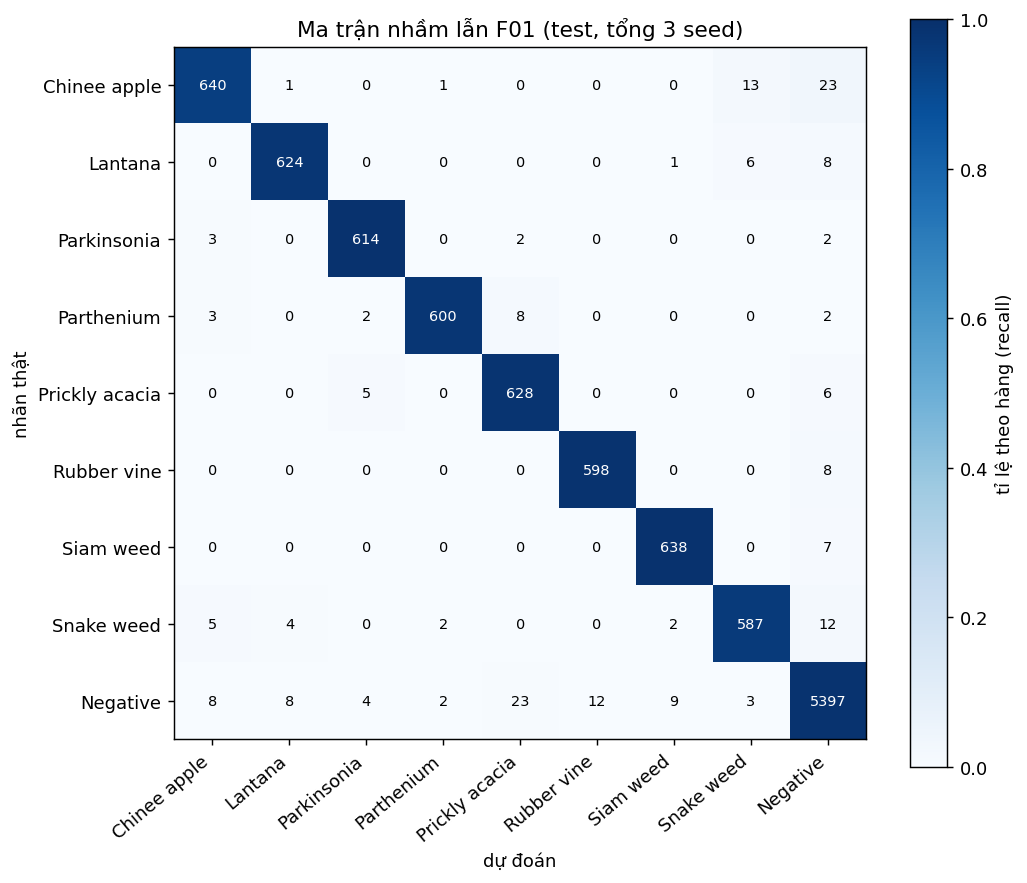

8 cặp nhầm nhiều nhất (thật -> dự đoán, số ảnh, % của lớp thật):
     Chinee apple -> Negative          23  (3.4%)
         Negative -> Prickly acacia    23  (0.4%)
     Chinee apple -> Snake weed        13  (1.9%)
       Snake weed -> Negative          12  (2.0%)
         Negative -> Rubber vine       12  (0.2%)
         Negative -> Siam weed          9  (0.2%)
          Lantana -> Negative           8  (1.3%)
       Parthenium -> Prickly acacia     8  (1.3%)
Chinee apple -> Snake weed: 1.9% (bài báo 3,4%) | Snake weed -> Chinee apple: 0.8% (bài báo 4,1%)


In [28]:
# ---- phân tích lỗi: ma trận nhầm lẫn (tổng 3 seed), cặp Chinee apple <-> Snake weed, xem ảnh bị đoán sai
cm = sum(m["confusion"] for m in GF.metrics)
rt.plot_confusion(cm, names_csv, FIG / "confusion_F01_test.png", "Ma trận nhầm lẫn F01 (test, tổng 3 seed)")
display(IPImage(str(FIG / "confusion_F01_test.png")))
off = [(names_csv[i], names_csv[j], int(cm[i, j]), cm[i, j] / cm[i].sum()) for i in range(9) for j in range(9) if i != j]
off = sorted(off, key=lambda t: -t[2])[:8]
print("8 cặp nhầm nhiều nhất (thật -> dự đoán, số ảnh, % của lớp thật):")
for a, b, n, fr in off:
    print(f"  {a:>15} -> {b:<15} {n:>4}  ({fr:.1%})")
ci, si = names_csv.index(next(n for n in names_csv if n.lower().startswith("chinee"))), names_csv.index(next(n for n in names_csv if n.lower().startswith("snake")))
print(f"Chinee apple -> Snake weed: {cm[ci, si] / cm[ci].sum():.1%} (bài báo 3,4%) | Snake weed -> Chinee apple: {cm[si, ci] / cm[si].sum():.1%} (bài báo 4,1%)")

p0 = GF.preds[0]
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for r_, (t_, p_) in enumerate(((ci, si), (si, ci))):
    wrong = np.where((p0.y_true == t_) & (p0.y_pred == p_))[0][:6]
    rows_ = store.rows(p0.filenames[wrong])
    for j in range(6):
        axes[r_, j].axis("off")
        if j < len(wrong):
            axes[r_, j].imshow(store.arr[rows_[j]])
            axes[r_, j].set_title(f"thật {names_csv[t_][:7]} → {names_csv[p_][:7]}\np={p0.probs[wrong[j], p_]:.2f}", fontsize=8)
fig.suptitle("Ảnh test bị đoán sai (seed 0): hàng 1 Chinee apple→Snake weed, hàng 2 Snake weed→Chinee apple", fontsize=10)
fig.tight_layout(); fig.savefig(FIG / "errors_chinee_snake.png", dpi=90); plt.show()

**Phân tích lỗi:** F1 thấp nhất theo lớp: Chinee apple 0,957 (recall 94,4%), Snake weed 0,962 (recall 95,9%) và Prickly acacia 0,966 (precision chỉ 0,950). So với bài báo (ResNet-50, 88,5% và 88,8% recall) cao hơn rất nhiều, nhưng *không phải so sánh cùng điều kiện* (bài báo: 100 epoch, 5 fold, độ chính xác trung bình có trọng số; ở đây ConvNeXt-T tiền huấn luyện ImageNet-12k; ResNet-50 của chính tôi dưới công thức nền chỉ đạt top-1 val 85,6%). Cặp nhầm kinh điển Chinee apple ↔ Snake weed giảm còn 1,9% và 0,8% (bài báo 3,4% và 4,1%) và không còn là lỗi chính: trong 195 lỗi (tổng 3 seed), 137 (70,3%) liên quan `Negative` (68 loài bị đoán là `Negative`, 69 ảnh `Negative` bị đoán là một loài), chỉ 58 (29,7%) là nhầm giữa hai loài. Các cặp lớn nhất: Chinee apple → `Negative` 23 (3,4% lớp), `Negative` → Prickly acacia 23, Chinee apple → Snake weed 13, Snake weed → `Negative` 12, `Negative` → Rubber vine 12, Parthenium → Prickly acacia 8. Qua ảnh sai (`figures/errors_chinee_snake.png`) giả thuyết (chưa kiểm chứng): ảnh Chinee/Snake bị nhầm là tán lá rộng tối dưới bóng đổ mạnh nên hình dạng lá khó phân biệt, và một số ảnh gần như chỉ có đất/thảm mục với cây nhỏ hoặc thưa nên nhãn loài chỉ dựa trên vài chi tiết nhỏ (có thể bị crop 224 cắt bớt); `Negative` bị nhầm thành Prickly acacia/Rubber vine/Siam weed có thể do ảnh đất–cỏ chứa cây non của loài đó (nhãn nhiễu theo định nghĩa `Negative` = thực vật không phải loài mục tiêu). Chia ngẫu nhiên không theo địa điểm nên ảnh test có thể rất giống ảnh train cùng điểm chụp, làm các số trên lạc quan.

## Bước 5 — Sản phẩm: `results.xlsx`, `curves/`, `report.md`, đóng gói

In [29]:
# ---- results.xlsx (7 sheet theo GUIDE mục 6.1)
LAT_DF = pd.DataFrame([{"cấu hình": r["label"], "GPU": r["gpu"], "dtype": r["dtype"], "batch": r["batch"], "độ phân giải": r["img_size"],
                        "gộp BN": "có" if r.get("bn_fused") else "không", "p50 (ms)": r["p50"], "p95 (ms)": r["p95"], "p99 (ms)": r["p99"],
                        "ảnh/s": r["images_per_s"], "K view": r.get("k_views", 1), "torch": r["torch"], "số lần đo": r["n"]} for r in LAT])
# Summary: top 10 cấu hình theo macro-F1 val (backbone, huấn luyện, suy luận) + hai dòng test
pool = []
for _, r in BB.iterrows():
    pool.append({"exp_id": r["exp_id"], "nhóm": "backbone", "mô tả": r["backbone"], "macro-F1 val": r["macro-F1 val"], "top-1 val": r["top-1 val"],
                 "độ trễ p50 batch-1 (ms)": r["độ trễ batch-1 p50 (ms)"], "chi phí huấn luyện (s/epoch)": r["thời gian train/epoch (s)"]})
for r in TR_ROWS:
    pool.append({"exp_id": f"{r['exp_id']} (seed {r['seed']})", "nhóm": "công thức huấn luyện", "mô tả": f"{r['backbone']}: {r['khác T00 ở điểm nào']}",
                 "macro-F1 val": r["macro-F1 val"], "top-1 val": r["top-1 val"], "độ trễ p50 batch-1 (ms)": lat00["p50"], "chi phí huấn luyện (s/epoch)": np.nan})
for _, r in INFR.iterrows():
    pool.append({"exp_id": r["exp_id"], "nhóm": "suy luận", "mô tả": r["phương pháp"], "macro-F1 val": r["macro-F1 val"], "top-1 val": r["top-1 val"],
                 "độ trễ p50 batch-1 (ms)": r["độ trễ p50 (ms)"], "chi phí huấn luyện (s/epoch)": np.nan})
SUMMARY = pd.DataFrame(pool).sort_values("macro-F1 val", ascending=False).head(10).reset_index(drop=True)
SUMMARY["xếp hạng"] = range(1, len(SUMMARY) + 1)
extra = pd.DataFrame([
    {"exp_id": "F01 (test, 3 seed)", "nhóm": "chung kết", "mô tả": CFG_DESC["F01"], "macro-F1 val": VF.summary["macro_f1"][0], "top-1 val": VF.summary["top1"][0],
     "độ trễ p50 batch-1 (ms)": np.nan, "chi phí huấn luyện (s/epoch)": np.nan, "xếp hạng": f"test macro-F1 {rt.fmt_pm(*GF.summary['macro_f1'])}"},
    {"exp_id": "T00+I00 (test, 3 seed)", "nhóm": "mốc", "mô tả": CFG_DESC["T00"], "macro-F1 val": VT.summary["macro_f1"][0], "top-1 val": VT.summary["top1"][0],
     "độ trễ p50 batch-1 (ms)": lat00["p50"], "chi phí huấn luyện (s/epoch)": np.nan, "xếp hạng": f"test macro-F1 {rt.fmt_pm(*GT.summary['macro_f1'])}"}])
SUMMARY = pd.concat([SUMMARY, extra], ignore_index=True)
sheets = {"Backbones": BB, "Training": TRN, "Inference": INFR, "Final": FINAL_DF, "PerClass": PC, "Latency": LAT_DF, "Summary": SUMMARY}
rt.write_results_xlsx(OUT / "results.xlsx", sheets, best={"Backbones": ("macro-F1 val", "max"), "Training": ("macro-F1 val", "max"), "Inference": ("macro-F1 val", "max")})
print("đã ghi", OUT / "results.xlsx", {k: v.shape for k, v in sheets.items()})

# ---- log từng run (truy ngược exp_id -> log) và kiểm tra ảnh curves/
res_dir = OUT / "results" / "runs"
for sj in (OUT / "runs").glob("*/seed*/summary.json"):
    dst = res_dir / sj.parent.parent.name / sj.parent.name
    dst.mkdir(parents=True, exist_ok=True)
    for f in ("summary.json", "history.csv", "config.json"):
        if (sj.parent / f).exists():
            shutil.copy(sj.parent / f, dst / f)
for name, df in sheets.items():
    df.to_csv(OUT / "results" / f"{name}.csv", index=False)
exps = [(eid, name) for eid, name in BACKBONES] + [("T00", MAIN)] + [(e, MAIN) for e in T] + [("F01", MAIN)]
for e, _ in exps:                         # nếu curves/ bị mất (run nạp lại từ Drive) thì vẽ lại từ history.csv
    if not list((OUT / "curves").glob(f"{e}_*.png")):
        rd_ = OUT / "runs" / e / "seed0"
        c_ = json.loads((rd_ / "config.json").read_text())
        tr.plot_curves(pd.read_csv(rd_ / "history.csv").to_dict("records"), OUT / "curves" / f"{e}_{c_['mota'] or c_['backbone']}.png",
                       f"{e} | {c_['backbone']} | seed 0", np.load(rd_ / "lr_steps.npy"))
missing = [e for e, _ in exps if not list((OUT / "curves").glob(f"{e}_*.png"))]
print("exp_id có ảnh curves:", len(exps) - len(missing), "/", len(exps), "| thiếu:", missing or "không")
assert not missing

đã ghi /kaggle/working/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602559_nguyen_thanh_hoa/results.xlsx {'Backbones': (7, 14), 'Training': (21, 13), 'Inference': (20, 14), 'Final': (12, 8), 'PerClass': (9, 8), 'Latency': (35, 13), 'Summary': (12, 8)}
exp_id có ảnh curves: 27 / 27 | thiếu: không


In [30]:
# ---- bản nháp report.md: số liệu tự điền từ kết quả thật; các mục TODO là phần bạn phải tự viết
def one(df, **kw):
    return "\n" + rt.md_table(df, 4)          # dòng trống phía trước để markdown nhận ra bảng
L = []
L.append(f"# Báo cáo Lab Day 2 — Nguyễn Thanh Hòa — {MSSV}\n")
L.append("> BẢN NHÁP TỰ SINH: bảng/số liệu/ảnh tự điền từ lần chạy; các mục `TODO (tự viết)` phải được viết bằng nhận định của bạn (cơ chế, so sánh với nhiễu, hạn chế) trước khi nộp. Chạy ở chế độ " + ("QUICK (không dùng để nộp)" if QUICK else "đầy đủ") + ("; LITE (đã rút gọn)" if LITE else "") + ".\n")
L.append("## 1. Tóm tắt\n")
L.append(f"- Bài toán: phân loại 9 lớp DeepWeeds (fold 0, 10.501/3.501/3.507 ảnh train/val/test). {len(BACKBONES)} backbone, {len([k for k in T if k != 'T20'])} thí nghiệm công thức huấn luyện{' + T20 (kết hợp)' if 'T20' in T else ''}, {len(INFR)} cấu hình suy luận.")
L.append(f"- Cấu hình tốt nhất (chốt bằng val): {CFG_DESC['F01']}.")
L.append(f"- **Test (3 seed, mean ± std): macro-F1 {rt.fmt_pm(*GF.summary['macro_f1'])}, top-1 {rt.fmt_pm(*GF.summary['top1'])}, ECE {rt.fmt_pm(*GF.summary['ece'])}**; mốc T00+I00: macro-F1 {rt.fmt_pm(*GT.summary['macro_f1'])}, top-1 {rt.fmt_pm(*GT.summary['top1'])}; Δ macro-F1 = {dm:+.4f} ({'vượt' if dm > sd else 'không vượt'} std lớn hơn {sd:.4f}).")
L.append(f"- Cấu hình thời gian thực R01: {CFG_DESC['R01']}: p95 {RTC_P95:.1f} ms (batch 1), macro-F1 test {rt.fmt_pm(*GR.summary['macro_f1'])}.")
L.append("- TODO (tự viết): 2–3 câu kết luận chính (yếu tố đóng góp nhiều nhất, điều bất ngờ).\n")
L.append("## 2. Dữ liệu và thiết lập\n")
L.append("- Dataset DeepWeeds, fold 0 chia sẵn (`train/val/test_subset0.csv`), không sửa; kiểm tra: giao các cặp tập rỗng, hợp đủ 17.509 ảnh, mọi file tồn tại.")
L.append(one(per_class.reset_index().rename(columns={"index": "lớp"})) + "\n")
L.append("![](figures/eda_class_distribution.png)\n")
L.append("Đối chiếu với Table 1 của bài báo:\n")
L.append(one(cmp) + "\n")
L.append("- Chỉ số: macro-F1 (chính), top-1, balanced accuracy, F1/recall từng lớp, ECE 15 bin; mean ± std (ddof = 1) qua 3 seed. Chọn mọi thứ trên val; test một lần mỗi checkpoint.")
L.append(f"- Công thức nền: AdamW (LR backbone 1e-4, head 1e-3, wd 0,05 không áp dụng cho norm/bias), warmup 1 epoch + cosine, CE, batch 64, {EPOCHS} epoch, AMP, RandomResizedCrop(224, scale 0,25–1) + lật ngang; val/test center-crop 224.")
L.append(f"- Môi trường: {ENV['gpu']}, PyTorch {ENV['torch']}, timm {ENV['timm']}, Python {ENV['python']}. Seed 0/1/2. Tái lập: cudnn.benchmark bật nên không tái lập từng bit trên GPU.")
L.append("- TODO (tự viết): nhận xét EDA (mất cân bằng, ảnh mẫu, lớp dễ nhầm).\n")
L.append("## 3. So sánh backbone\n")
L.append(one(BB) + "\n")
L.append("![](figures/backbone_f1_vs_latency.png)\n")
L.append(f"- Chọn đi tiếp: {MAIN_REASON}.")
L.append("- TODO (tự viết): nhận xét (thứ hạng, transformer vs CNN, FLOPs vs độ trễ, hội tụ/quá khớp từ `curves/`), đối chiếu với dự đoán.\n")
L.append("## 4. Công thức huấn luyện\n")
L.append(f"`T00` ({MAIN}) 3 seed: {rt.fmt_pm(f1s.mean(), SIGMA)}; ngưỡng nhiễu = max(2σ, 0,003) = {THR:.4f}. Các thí nghiệm khác 1 seed (seed 0), tham lam theo trục.\n")
L.append(one(TRN) + "\n")
L.append("![](figures/ablation_delta_f1.png)\n")
L.append(f"- Công thức tốt nhất: {BEST_DESC}.")
L.append("- TODO (tự viết): với từng trục, yếu tố nào giúp/hại và vì sao (liên hệ slide); `T20` cộng dồn hay triệt tiêu; lớp hiếm và `Negatives`; chênh lệch nào nhỏ hơn nhiễu thì ghi 'không phân biệt được'.\n")
L.append("## 5. Suy luận\n")
L.append(one(INFR) + "\n")
L.append("![](figures/inference_tradeoff.png)\n")
L.append(f"- Suy luận cuối: {FINAL_KIND}, gộp {FINAL_SPACE}, K = {FINAL_K}, + temperature scaling; thời gian thực: {RTC_PREC} ({RTC_P50:.1f} ms p50 / {RTC_P95:.1f} ms p95).")
L.append("- Độ trễ đo đúng cách: warmup, `cuda.synchronize`, " + str(ITERS) + " lần đo, p50/p95/p99, không tính tiền xử lý (xem sheet `Latency`).")
L.append("- TODO (tự viết): TTA/độ phân giải/ensemble/EMA/T/FP16/gộp BN đáng giá hay không; hợp ngoại tuyến hay thời gian thực; ECE trước/sau.\n")
L.append("## 6. Cấu hình tốt nhất và chung kết\n")
L.append(one(FINAL_DF) + "\n")
L.append(one(PC) + "\n")
L.append("![](figures/confusion_F01_test.png)\n")
L.append("![](figures/errors_chinee_snake.png)\n")
L.append("- So với số tham khảo của bài báo (trích dẫn, điều kiện khác: 100 epoch, augmentation mạnh): ResNet-50 95,7%, Inception-v3 95,1%; Chinee apple 88,5%, Snake weed 88,8%.")
L.append("- TODO (tự viết): mô tả đầy đủ để tái lập; phân tích lỗi (cặp nhầm, giả thuyết từ ảnh sai); Δ so với mốc có vượt std không.\n")
L.append("## 7. Kết luận và khuyến nghị\n")
L.append("- TODO (tự viết): cấu hình tốt nhất và Δ so với mốc; yếu tố đóng góp nhiều nhất (backbone / huấn luyện / suy luận); nếu triển khai robot 30–100 ms/khung thì chọn gì (R01) và vì sao.\n")
L.append("## 8. Hạn chế và việc tiếp theo\n")
L.append("- Một fold (fold 0), chia ngẫu nhiên (không theo địa điểm/mùa) nên điểm test có thể lạc quan khi gặp địa điểm mới; chỉ 3 seed ở vòng cuối, 1 seed ở vòng sàng (σ ước lượng thô từ 3 seed `T00`).")
L.append(f"- Ablation chỉ trên 1 backbone, {EPOCHS} epoch (ngắn hơn bài báo ~100 epoch), tham lam theo trục (thứ tự trục có thể ảnh hưởng); trục G (độ phân giải 256) chỉ khảo sát, không đưa vào công thức cuối.")
L.append("- Độ trễ đo trên một GPU của phiên Colab/Kaggle (dùng chung nên có nhiễu), không gồm tiền xử lý; không phải Jetson như bài báo.")
if LITE:
    L.append("- Chế độ LITE: đã bỏ bớt thí nghiệm (xem bảng Training/Backbones) để vừa hạn mức GPU.")
if SKIPPED:
    L.append("- Bỏ qua: " + "; ".join(f"{k}: {v}" for k, v in SKIPPED.items()))
L.append("- TODO (tự viết): kết quả khác dự đoán và vì sao; nếu có thêm thời gian bạn sẽ chạy gì (nhiều fold, chưng cất, thích ứng lúc kiểm tra, DINOv2 linear probe).\n")
L.append("## 9. Phụ lục\n")
L.append("- `exp_id`: " + ", ".join(sorted({e for e, _ in exps})) + ". Log từng run: `results/runs/<exp_id>/seed<k>/`; bảng: `results.xlsx`; ảnh huấn luyện: `curves/`.")
L.append("- Link notebook Colab/Kaggle: TODO (dán link vào `README.md` và đây).")
(OUT / "report.md").write_text("\n".join(L) + "\n", encoding="utf-8")
print("đã ghi", OUT / "report.md", "| còn", sum(s.count("TODO") for s in L), "mục TODO (tự viết) cần hoàn thành")

đã ghi /kaggle/working/K4-Track4-Day2-Deeplearning-Advance/submissions/2A202602559_nguyen_thanh_hoa/report.md | còn 10 mục TODO (tự viết) cần hoàn thành


In [31]:
# ---- đóng gói (không kèm runs/ chứa checkpoint, cache, __pycache__) và tải về
for root_, dirs_, _ in os.walk(SUB_DIR):
    for d_ in list(dirs_):
        if d_ in ("__pycache__", ".ipynb_checkpoints") or (d_ == "_quick_out" and not QUICK):
            shutil.rmtree(os.path.join(root_, d_), ignore_errors=True); dirs_.remove(d_)
stage = Path(tempfile.gettempdir()) / "pack_lab2" / SUB_NAME
shutil.rmtree(stage.parent, ignore_errors=True)
def _skip(dirpath, names):
    ig = set(shutil.ignore_patterns("__pycache__", "*.pt", "_quick_out", ".ipynb_checkpoints")(dirpath, names))
    if Path(dirpath) == OUT:                           # chỉ bỏ runs/ (checkpoint, logit) và eval_out ở thư mục gốc; results/runs/ (log nhỏ) được giữ
        ig |= {n for n in names if n in ("runs", "eval_out")}
    return ig
shutil.copytree(OUT, stage, ignore=_skip)
zip_path = shutil.make_archive(str(REPO_ROOT / (SUB_NAME + ("_quick" if QUICK else ""))), "zip", root_dir=stage.parent, base_dir=SUB_NAME)
print("đã nén:", zip_path, f"({os.path.getsize(zip_path) / 2**20:.1f} MB)")
for need in ("results.xlsx", "report.md", "curves", "predictions", "code"):
    print(("OK    " if (OUT / need).exists() else "THIẾU "), need)
if IN_COLAB and not QUICK:
    from google.colab import files
    files.download(zip_path)

đã nén: /kaggle/working/K4-Track4-Day2-Deeplearning-Advance/2A202602559_nguyen_thanh_hoa.zip (12.3 MB)
OK     results.xlsx
OK     report.md
OK     curves
OK     predictions
OK     code


**Việc còn lại trước khi nộp:** (1) điền các ô *Nhận xét / Đối chiếu / Phân tích lỗi* trong notebook và mọi `TODO (tự viết)` trong `report.md`; (2) dán link Colab/Kaggle vào `README.md`;
(3) tải `lab_day2.ipynb` **có output** về (Colab: *File → Download → Download .ipynb*) và đặt vào `code/`; (4) không commit `images.zip`, ảnh, checkpoint (`runs/` đã nằm trong `.gitignore`).